Assalamualaikum WR. WB>
Perkenalkan, saya **Adib Raihan Ashidiq**. Ini adalah final project saya dalam mengikuti data scientist ID/X Partner di Rakamin Academy



# 1. Data Understanding
pada bagian ini yang saya lakukan analisis dataset tentang struktur dataset, termasuk jumlah baris dan kolom, mengidentifikasi setiap atribut atau kolom data, melakukan eksplorasi awal terhadap distribusi variabel, statistik deskriptif, dan pola umum dalam data.

Import library yang diperlukan

In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Mengunggah file ke colab

In [42]:
# Membaca file CSV dengan delimiter(pemisah) koma(,) dan saya melewatkan jika ada kolom kosong
df = pd.read_csv('/content/loan_data_2007_2014.csv', delimiter=',', on_bad_lines='skip')

# Menampilkan beberapa baris pertama untuk pengecekan beberapa nama kolom
print(df.head())

   Unnamed: 0       id  member_id  loan_amnt  funded_amnt  funded_amnt_inv  \
0           0  1077501    1296599       5000         5000           4975.0   
1           1  1077430    1314167       2500         2500           2500.0   
2           2  1077175    1313524       2400         2400           2400.0   
3           3  1076863    1277178      10000        10000          10000.0   
4           4  1075358    1311748       3000         3000           3000.0   

         term  int_rate  installment grade  ... total_bal_il il_util  \
0   36 months     10.65       162.87     B  ...          NaN     NaN   
1   60 months     15.27        59.83     C  ...          NaN     NaN   
2   36 months     15.96        84.33     C  ...          NaN     NaN   
3   36 months     13.49       339.31     C  ...          NaN     NaN   
4   60 months     12.69        67.79     B  ...          NaN     NaN   

  open_rv_12m open_rv_24m  max_bal_bc all_util total_rev_hi_lim inq_fi  \
0         NaN         Na

Pada langkah ini, saya menganalisis struktur umum dataset dengan melihat jumlah baris dan kolom dan tipe data masing-masing kolom.

In [43]:
# Melihat informasi umum struktur dataset
print("RINGKASAN STRUKTUR DATASET:")
print(f"Jumlah baris: {df.shape[0]}")
print(f"Jumlah kolom: {df.shape[1]}")

# Melihat informasi detail dataset (tipe data, non-null values)
print("\nINFORMASI DETAIL DATASET:")
df.info()

# Melihat beberapa baris pertama dan terakhir dataset
print("\nSAMPEL AWAL DATASET:")
display(df.head())

RINGKASAN STRUKTUR DATASET:
Jumlah baris: 466285
Jumlah kolom: 75

INFORMASI DETAIL DATASET:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 466285 entries, 0 to 466284
Data columns (total 75 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   Unnamed: 0                   466285 non-null  int64  
 1   id                           466285 non-null  int64  
 2   member_id                    466285 non-null  int64  
 3   loan_amnt                    466285 non-null  int64  
 4   funded_amnt                  466285 non-null  int64  
 5   funded_amnt_inv              466285 non-null  float64
 6   term                         466285 non-null  object 
 7   int_rate                     466285 non-null  float64
 8   installment                  466285 non-null  float64
 9   grade                        466285 non-null  object 
 10  sub_grade                    466285 non-null  object 
 11  emp_title               

,Unnamed: 0,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,...,total_bal_il,il_util,open_rv_12m,open_rv_24m,max_bal_bc,all_util,total_rev_hi_lim,inq_fi,total_cu_tl,inq_last_12m
0,0,1077501,1296599,5000,5000,4975.0,36 months,10.65,162.87,B,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,1077430,1314167,2500,2500,2500.0,60 months,15.27,59.83,C,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2,1077175,1313524,2400,2400,2400.0,36 months,15.96,84.33,C,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,3,1076863,1277178,10000,10000,10000.0,36 months,13.49,339.31,C,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,4,1075358,1311748,3000,3000,3000.0,60 months,12.69,67.79,B,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


**Mengidentifikasi setiap atribut atau kolom data**

Pada langkah ini, saya mengidentifikasi karakteristik masing-masing kolom dengan detail seperti tipe data, jumlah nilai unik, nilai yang hilang, dan contoh nilai. Untuk kolom numerik, menambahkan statistik dasar, sedangkan untuk kolom kategorikal saya melihat frekuensi kategori.

In [44]:
# Daftar nama kolom
print("DAFTAR KOLOM DALAM DATASET:")
for i, kolom in enumerate(df.columns, 1):
    print(f"{i}. {kolom} - {df[kolom].dtype}")

# Membuat DataFrame rangkasan untuk setiap kolom
ringkasan_kolom = []

for kolom in df.columns:
    # Informasi dasar
    tipe_data = df[kolom].dtype
    jumlah_nilai_unik = df[kolom].nunique()
    jumlah_missing = df[kolom].isnull().sum()
    persen_missing = (jumlah_missing / len(df)) * 100

    # Contoh nilai (maksimal 5)
    unique_values_str = [str(x) for x in df[kolom].unique()]

    if jumlah_nilai_unik <= 5:
        # Sort string representation of unique values
        contoh_nilai = sorted(unique_values_str)
    else:
        # Get sample values, drop NaN, convert to string, then sort
        sample_values = df[kolom].dropna().sample(min(5, df[kolom].count())).tolist()
        contoh_nilai = sorted([str(x) for x in sample_values])


    # Statistik tambahan berdasarkan tipe data
    if pd.api.types.is_numeric_dtype(df[kolom]):
        min_val = df[kolom].min()
        max_val = df[kolom].max()
        mean_val = df[kolom].mean()
        median_val = df[kolom].median()

        statistik_tambahan = {
            'Min': min_val,
            'Max': max_val,
            'Mean': mean_val,
            'Median': median_val
        }
    else:
        # Handle cases where value_counts might contain NaNs if not dropped
        if jumlah_nilai_unik <= 10 and not df[kolom].isnull().all():
             # For categorical with few categories, display all (handling potential NaNs)
             statistik_tambahan = df[kolom].value_counts(dropna=False).to_dict()
        elif not df[kolom].isnull().all():
            # For categorical with many categories, display top 3 (handling potential NaNs)
            statistik_tambahan = df[kolom].value_counts(dropna=False).head(3).to_dict()
        else:
             # Handle columns that are all NaN
             statistik_tambahan = {"Info": "All Missing"}


    # Tambahkan ke list
    ringkasan_kolom.append({
        'Kolom': kolom,
        'Tipe Data': tipe_data,
        'Jumlah Nilai Unik': jumlah_nilai_unik,
        'Jumlah Missing': jumlah_missing,
        'Persen Missing (%)': persen_missing,
        'Contoh Nilai': contoh_nilai,
        'Statistik Tambahan': statistik_tambahan
    })

# Tampilkan hasil sebagai DataFrame
ringkasan_df = pd.DataFrame(ringkasan_kolom)
display(ringkasan_df)

DAFTAR KOLOM DALAM DATASET:
1. Unnamed: 0 - int64
2. id - int64
3. member_id - int64
4. loan_amnt - int64
5. funded_amnt - int64
6. funded_amnt_inv - float64
7. term - object
8. int_rate - float64
9. installment - float64
10. grade - object
11. sub_grade - object
12. emp_title - object
13. emp_length - object
14. home_ownership - object
15. annual_inc - float64
16. verification_status - object
17. issue_d - object
18. loan_status - object
19. pymnt_plan - object
20. url - object
21. desc - object
22. purpose - object
23. title - object
24. zip_code - object
25. addr_state - object
26. dti - float64
27. delinq_2yrs - float64
28. earliest_cr_line - object
29. inq_last_6mths - float64
30. mths_since_last_delinq - float64
31. mths_since_last_record - float64
32. open_acc - float64
33. pub_rec - float64
34. revol_bal - int64
35. revol_util - float64
36. total_acc - float64
37. initial_list_status - object
38. out_prncp - float64
39. out_prncp_inv - float64
40. total_pymnt - float64
41. tota

,Kolom,Tipe Data,Jumlah Nilai Unik,Jumlah Missing,Persen Missing (%),Contoh Nilai,Statistik Tambahan
0,Unnamed: 0,int64,466285,0,0.000000,"[117514, 189673, 380507, 401960, 459596]","{'Min': 0, 'Max': 466284, 'Mean': 233142.0, 'M..."
1,id,int64,466285,0,0.000000,"[10715593, 12247587, 1465159, 30475680, 423819]","{'Min': 54734, 'Max': 38098114, 'Mean': 130797..."
2,member_id,int64,466285,0,0.000000,"[11666791, 14588678, 2418497, 8320185, 9987154]","{'Min': 70473, 'Max': 40860827, 'Mean': 145976..."
3,loan_amnt,int64,1352,0,0.000000,"[15000, 20000, 25000, 25000, 7000]","{'Min': 500, 'Max': 35000, 'Mean': 14317.27757..."
4,funded_amnt,int64,1354,0,0.000000,"[10075, 16000, 17050, 35000, 6000]","{'Min': 500, 'Max': 35000, 'Mean': 14291.80104..."
...,...,...,...,...,...,...,...
70,all_util,float64,0,466285,100.000000,[nan],"{'Min': nan, 'Max': nan, 'Mean': nan, 'Median'..."
71,total_rev_hi_lim,float64,14612,70276,15.071469,"[10684.0, 14900.0, 16400.0, 26000.0, 65500.0]","{'Min': 0.0, 'Max': 9999999.0, 'Mean': 30379.0..."
72,inq_fi,float64,0,466285,100.000000,[nan],"{'Min': nan, 'Max': nan, 'Mean': nan, 'Median'..."
73,total_cu_tl,float64,0,466285,100.000000,[nan],"{'Min': nan, 'Max': nan, 'Mean': nan, 'Median'..."


Identifikasi Atribut Kunci

In [45]:
# Pengelompokan kolom berdasarkan kategori
identifikasi_kolom = ['id', 'member_id', 'url', 'Unnamed: 0']
pinjaman_dasar_kolom = ['loan_amnt', 'funded_amnt', 'funded_amnt_inv', 'term', 'int_rate', 'installment', 'grade', 'sub_grade', 'purpose', 'title', 'issue_d']
peminjam_kolom = ['emp_title', 'emp_length', 'home_ownership', 'annual_inc', 'verification_status', 'addr_state', 'zip_code', 'dti', 'annual_inc_joint', 'dti_joint', 'verification_status_joint']
kredit_kolom = ['delinq_2yrs', 'earliest_cr_line', 'inq_last_6mths', 'mths_since_last_delinq', 'mths_since_last_record', 'open_acc', 'pub_rec', 'revol_bal', 'revol_util', 'total_acc', 'collections_12_mths_ex_med', 'mths_since_last_major_derog', 'acc_now_delinq', 'tot_coll_amt', 'tot_cur_bal']
akun_tambahan_kolom = ['open_acc_6m', 'open_il_6m', 'open_il_12m', 'open_il_24m', 'mths_since_rcnt_il', 'total_bal_il', 'il_util', 'open_rv_12m', 'open_rv_24m', 'max_bal_bc', 'all_util', 'total_rev_hi_lim', 'inq_fi', 'total_cu_tl', 'inq_last_12m']
pembayaran_kolom = ['pymnt_plan', 'out_prncp', 'out_prncp_inv', 'total_pymnt', 'total_pymnt_inv', 'total_rec_prncp', 'total_rec_int', 'total_rec_late_fee', 'recoveries', 'collection_recovery_fee', 'last_pymnt_d', 'last_pymnt_amnt', 'next_pymnt_d']
target_candidate_kolom = ['loan_status']
lain_lain_kolom = ['desc', 'initial_list_status', 'policy_code', 'application_type', 'last_credit_pull_d']

# Fungsi untuk memeriksa apakah kolom ada dalam dataset
def cek_kolom_ada(df, list_kolom):
    return [col for col in list_kolom if col in df.columns]

# Memeriksa dan menampilkan jumlah kolom per kategori yang ada dalam dataset
print("KATEGORI KOLOM DALAM DATASET:")
print(f"Identifikasi: {len(cek_kolom_ada(df, identifikasi_kolom))} kolom")
print(f"Pinjaman Dasar: {len(cek_kolom_ada(df, pinjaman_dasar_kolom))} kolom")
print(f"Informasi Peminjam: {len(cek_kolom_ada(df, peminjam_kolom))} kolom")
print(f"Riwayat Kredit: {len(cek_kolom_ada(df, kredit_kolom))} kolom")
print(f"Akun Tambahan: {len(cek_kolom_ada(df, akun_tambahan_kolom))} kolom")
print(f"Informasi Pembayaran: {len(cek_kolom_ada(df, pembayaran_kolom))} kolom")
print(f"Kandidat Target: {len(cek_kolom_ada(df, target_candidate_kolom))} kolom")
print(f"Lain-lain: {len(cek_kolom_ada(df, lain_lain_kolom))} kolom")

KATEGORI KOLOM DALAM DATASET:
Identifikasi: 4 kolom
Pinjaman Dasar: 11 kolom
Informasi Peminjam: 11 kolom
Riwayat Kredit: 15 kolom
Akun Tambahan: 15 kolom
Informasi Pembayaran: 13 kolom
Kandidat Target: 1 kolom
Lain-lain: 5 kolom


Analisis Variabel Target

In [46]:
# Cek nilai unik dalam loan_status
if 'loan_status' in df.columns:
    uniques = df['loan_status'].unique()
    print("Nilai unik dalam loan_status:")
    print(uniques)

Nilai unik dalam loan_status:
['Fully Paid' 'Charged Off' 'Current' 'Default' 'Late (31-120 days)'
 'In Grace Period' 'Late (16-30 days)'
 'Does not meet the credit policy. Status:Fully Paid'
 'Does not meet the credit policy. Status:Charged Off']



DISTRIBUSI LOAN_STATUS_SIMPLE:


,Jumlah,Persentase (%)
loan_status_simple,,
Good,410953,88.133438
Bad,55332,11.866562


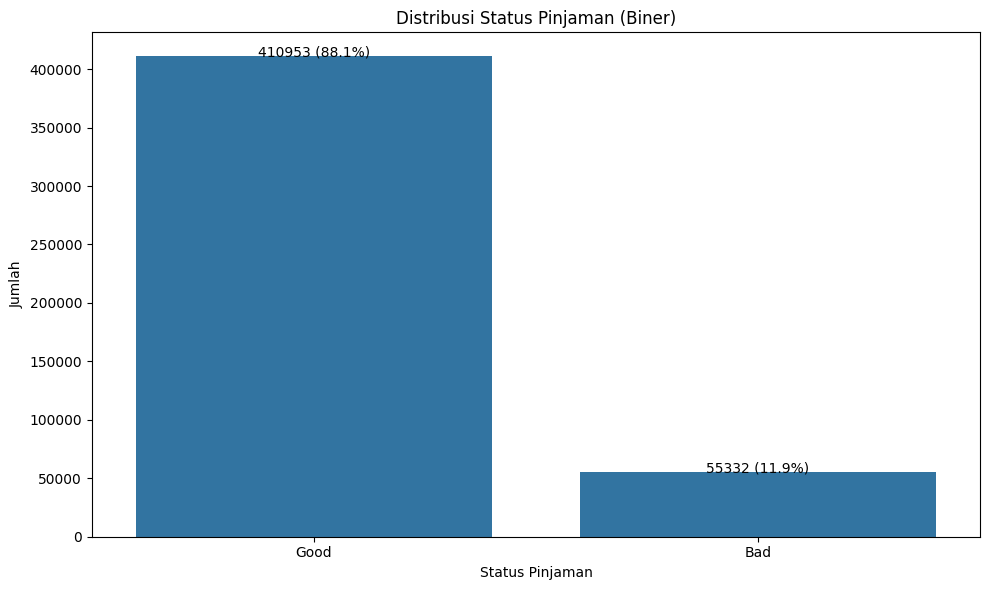


PENGELOMPOKAN STATUS PINJAMAN:


,Status Asli,Status Biner
0,Fully Paid,Good
1,Charged Off,Bad
2,Current,Good
3,Default,Bad
4,Late (31-120 days),Bad
5,In Grace Period,Bad
6,Late (16-30 days),Bad
7,Does not meet the credit policy. Status:Fully ...,Good
8,Does not meet the credit policy. Status:Charge...,Bad


In [47]:
# Buat kolom loan_status_simple berdasarkan nilai unik yang ditemukan
if 'loan_status' in df.columns:
    # Definisikan kategori status pinjaman berdasarkan nilai aktual
    good_status = [
        'Fully Paid',
        'Current',
        'Does not meet the credit policy. Status:Fully Paid'
    ]

    bad_status = [
        'Charged Off',
        'Default',
        'Late (31-120 days)',
        'Late (16-30 days)',
        'In Grace Period',
        'Does not meet the credit policy. Status:Charged Off'
    ]

    # Buat kolom baru untuk klasifikasi binary
    df['loan_status_simple'] = df['loan_status'].apply(
        lambda x: 'Good' if x in good_status else 'Bad'
    )

    # Tampilkan distribusi loan_status_simple
    simple_status_counts = df['loan_status_simple'].value_counts()
    simple_status_percent = (simple_status_counts / len(df)) * 100

    print("\nDISTRIBUSI LOAN_STATUS_SIMPLE:")
    status_simple_df = pd.DataFrame({
        'Jumlah': simple_status_counts,
        'Persentase (%)': simple_status_percent
    })
    display(status_simple_df)

    # Visualisasi
    plt.figure(figsize=(10, 6))
    sns.countplot(x='loan_status_simple', data=df)
    plt.title('Distribusi Status Pinjaman (Biner)')
    plt.xlabel('Status Pinjaman')
    plt.ylabel('Jumlah')

    # Tambahkan label jumlah dan persentase
    for i, (status, count) in enumerate(simple_status_counts.items()):
        plt.text(i, count + 5, f"{count} ({simple_status_percent.iloc[i]:.1f}%)", ha='center')

    plt.tight_layout()
    plt.show()

    # Tabel mapping dari status asli ke status biner
    print("\nPENGELOMPOKAN STATUS PINJAMAN:")
    status_mapping = {}
    for status in df['loan_status'].unique():
        if status in good_status:
            status_mapping[status] = "Good"
        else:
            status_mapping[status] = "Bad"

    mapping_df = pd.DataFrame({
        'Status Asli': list(status_mapping.keys()),
        'Status Biner': list(status_mapping.values())
    })
    display(mapping_df)

**Melakukan eksplorasi awal terhadap distribusi variabel dan
statistik deskriptif.**

Statistik Deskriptif untuk Variabel Numerik Utama

STATISTIK DESKRIPTIF UNTUK VARIABEL NUMERIK PENTING:


,count,mean,std,min,25%,50%,75%,max,skewness,kurtosis,missing (%)
loan_amnt,466285.0,14317.277577,8286.509164,500.00,8000.000000,12000.000000,20000.00000,3.500000e+04,0.730980,-0.134878,0.000000
funded_amnt,466285.0,14291.801044,8274.371300,500.00,8000.000000,12000.000000,20000.00000,3.500000e+04,0.734845,-0.124120,0.000000
int_rate,466285.0,13.829236,4.357587,5.42,10.990000,13.660000,16.49000,2.606000e+01,0.334938,-0.262517,0.000000
installment,466285.0,432.061201,243.485550,15.67,256.690000,379.890000,566.58000,1.409990e+03,0.949293,0.767986,0.000000
annual_inc,466281.0,73277.381470,54963.568654,1896.00,45000.000000,63000.000000,88960.00000,7.500000e+06,29.568905,3071.114370,0.000858
dti,466285.0,17.218758,7.851121,0.00,11.360000,16.870000,22.78000,3.999000e+01,0.188283,-0.540701,0.000000
delinq_2yrs,466256.0,0.284678,0.797365,0.00,0.000000,0.000000,0.00000,2.900000e+01,5.345748,53.143918,0.006219
inq_last_6mths,466256.0,0.804745,1.091598,0.00,0.000000,0.000000,1.00000,3.300000e+01,2.142143,13.863883,0.006219
open_acc,466256.0,11.187069,4.987526,0.00,8.000000,10.000000,14.00000,8.400000e+01,1.165698,2.817052,0.006219
revol_bal,466285.0,16230.203487,20676.245152,0.00,6413.000000,11764.000000,20333.00000,2.568995e+06,19.476291,1433.063059,0.000000


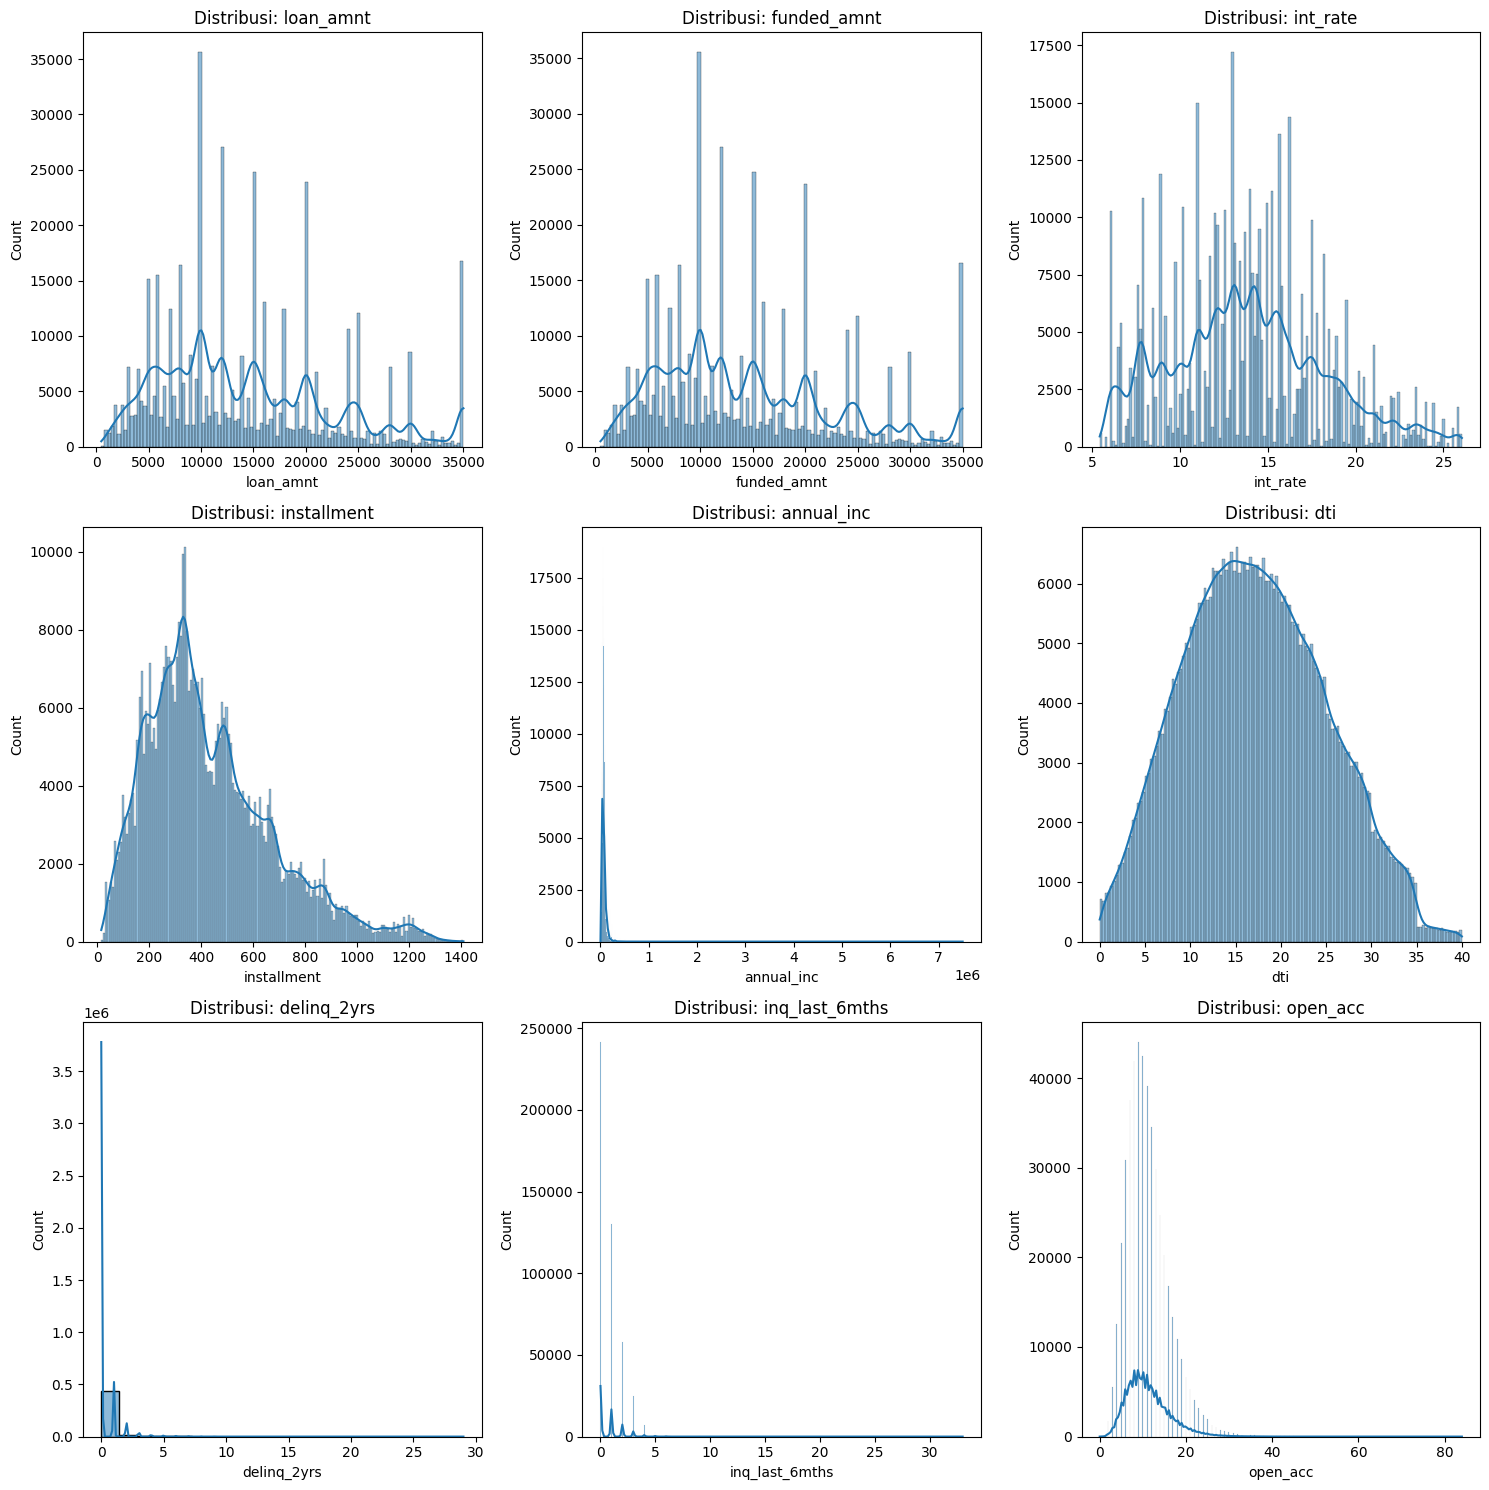

In [48]:
# Pilih variabel numerik penting untuk analisis
numerik_penting = ['loan_amnt', 'funded_amnt', 'int_rate', 'installment', 'annual_inc',
                   'dti', 'delinq_2yrs', 'inq_last_6mths', 'open_acc', 'revol_bal',
                   'revol_util', 'total_acc', 'total_pymnt', 'total_rec_int']

# Konversi kolom numerik jika perlu (misalnya int_rate, revol_util mungkin berformat string)
for col in ['int_rate', 'revol_util']:
    if col in df.columns and df[col].dtype == 'object':
        df[col] = df[col].str.replace('%', '').astype(float)

# Hanya pilih kolom yang ada dalam dataset
numerik_penting = [col for col in numerik_penting if col in df.columns]

# Statistik deskriptif
print("STATISTIK DESKRIPTIF UNTUK VARIABEL NUMERIK PENTING:")
stats_num = df[numerik_penting].describe().T
stats_num['skewness'] = df[numerik_penting].skew()
stats_num['kurtosis'] = df[numerik_penting].kurtosis()
stats_num['missing (%)'] = df[numerik_penting].isnull().mean() * 100
display(stats_num)

# Visualisasi histogram untuk variabel numerik penting
plt.figure(figsize=(15, 15))
for i, col in enumerate(numerik_penting[:9], 1):  # Tampilkan 9 pertama saja
    plt.subplot(3, 3, i)
    sns.histplot(df[col].dropna(), kde=True)
    plt.title(f'Distribusi: {col}')
plt.tight_layout()
plt.show()

Analisis Variabel Kategorikal Utama


ANALISIS UNTUK: grade


,Jumlah,Persentase (%)
grade,,
B,136929,29.365946
C,125293,26.870476
D,76888,16.489486
A,74867,16.056060
E,35757,7.668486
F,13229,2.837106
G,3322,0.712440


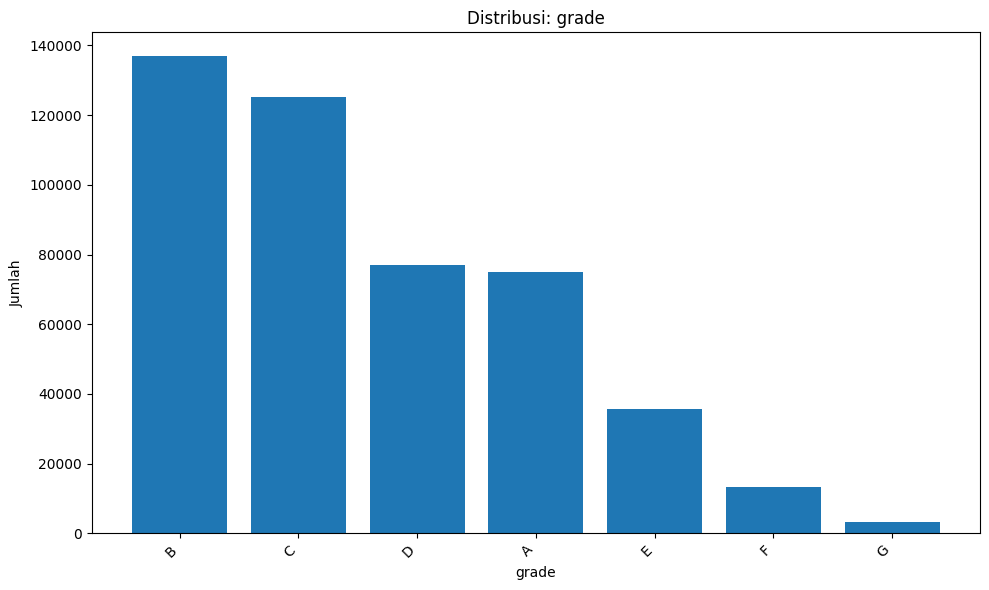

<Figure size 1000x600 with 0 Axes>

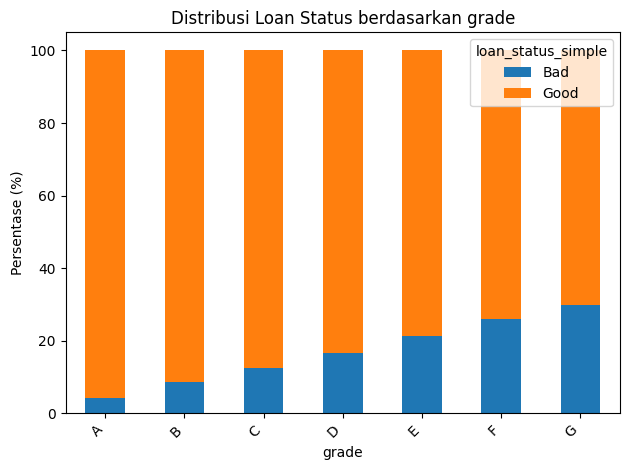


ANALISIS UNTUK: sub_grade


,Jumlah,Persentase (%)
sub_grade,,
B3,31686,6.795415
B4,30505,6.542136
C1,26953,5.780370
C2,26740,5.734690
B2,26610,5.706810
C3,25317,5.429512
B5,25252,5.415572
C4,24105,5.169585
B1,22876,4.906012


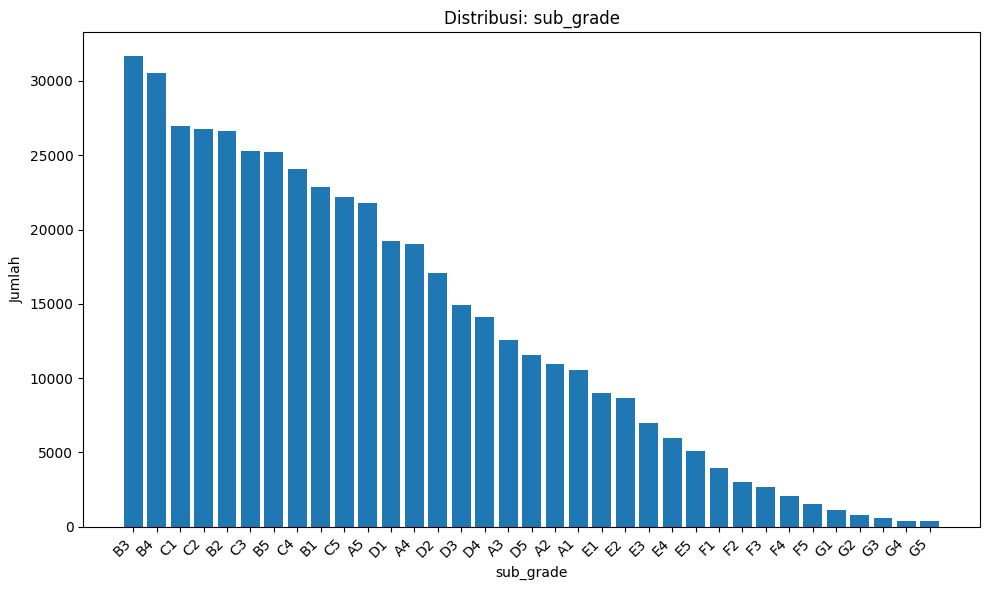

<Figure size 1000x600 with 0 Axes>

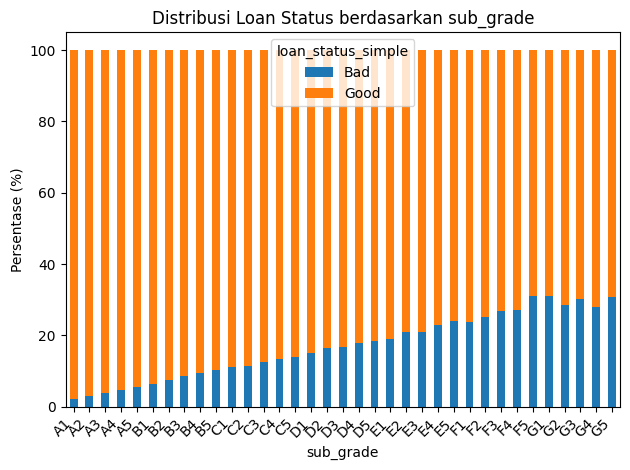


ANALISIS UNTUK: emp_length


,Jumlah,Persentase (%)
emp_length,,
10+ years,150049,32.179676
2 years,41373,8.872900
3 years,36596,7.848419
< 1 year,36265,7.777432
5 years,30774,6.599826
1 year,29622,6.352767
4 years,28023,6.009844
7 years,26180,5.614592
6 years,26112,5.600009


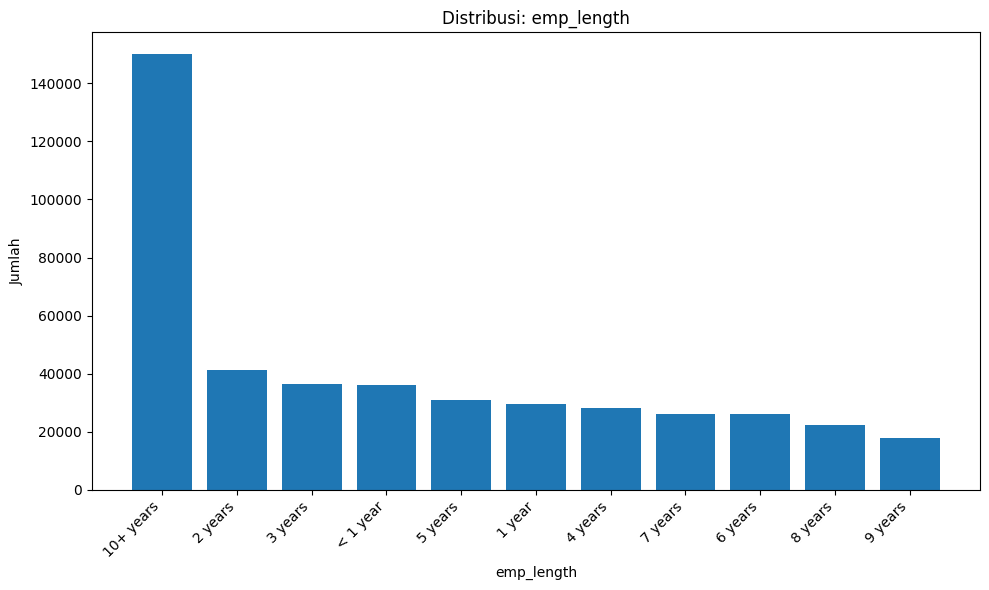

<Figure size 1000x600 with 0 Axes>

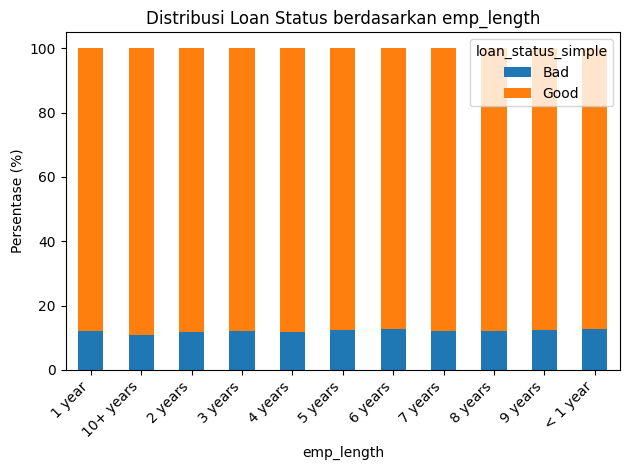


ANALISIS UNTUK: home_ownership


,Jumlah,Persentase (%)
home_ownership,,
MORTGAGE,235875,50.586015
RENT,188473,40.420129
OWN,41704,8.943886
OTHER,182,0.039032
NONE,50,0.010723
ANY,1,0.000214


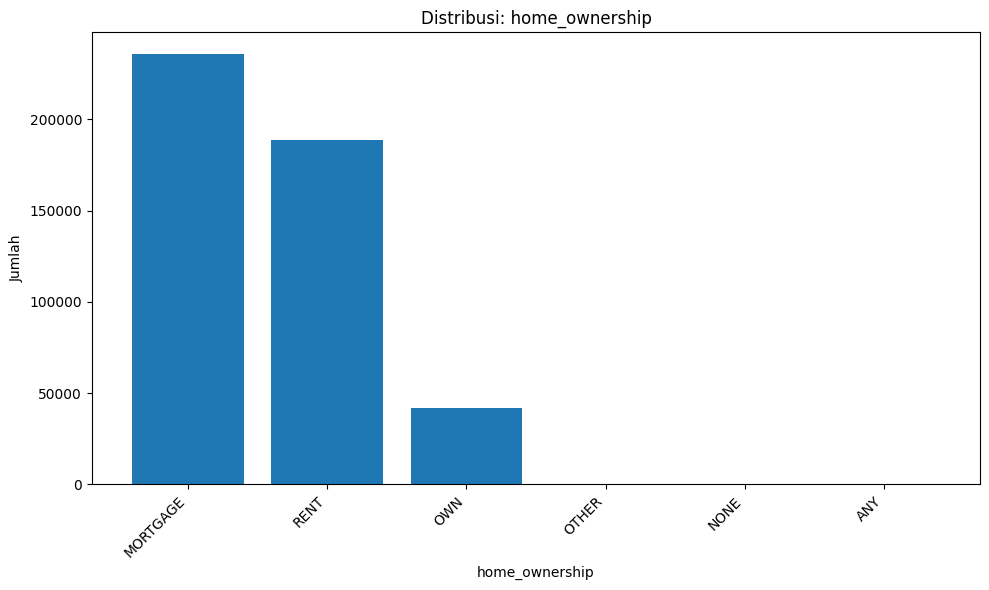

<Figure size 1000x600 with 0 Axes>

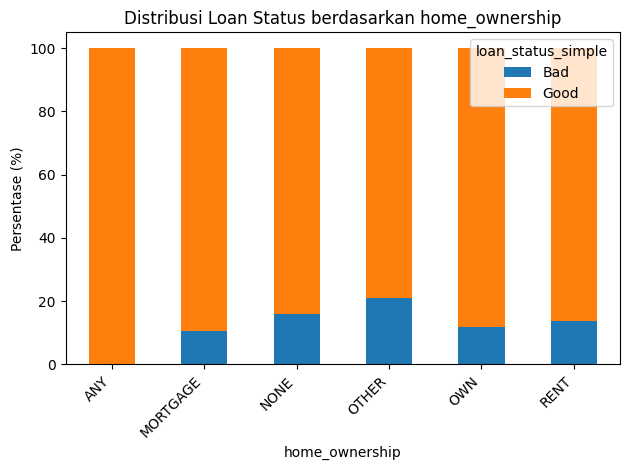


ANALISIS UNTUK: verification_status


,Jumlah,Persentase (%)
verification_status,,
Verified,168055,36.041262
Source Verified,149993,32.167666
Not Verified,148237,31.791072


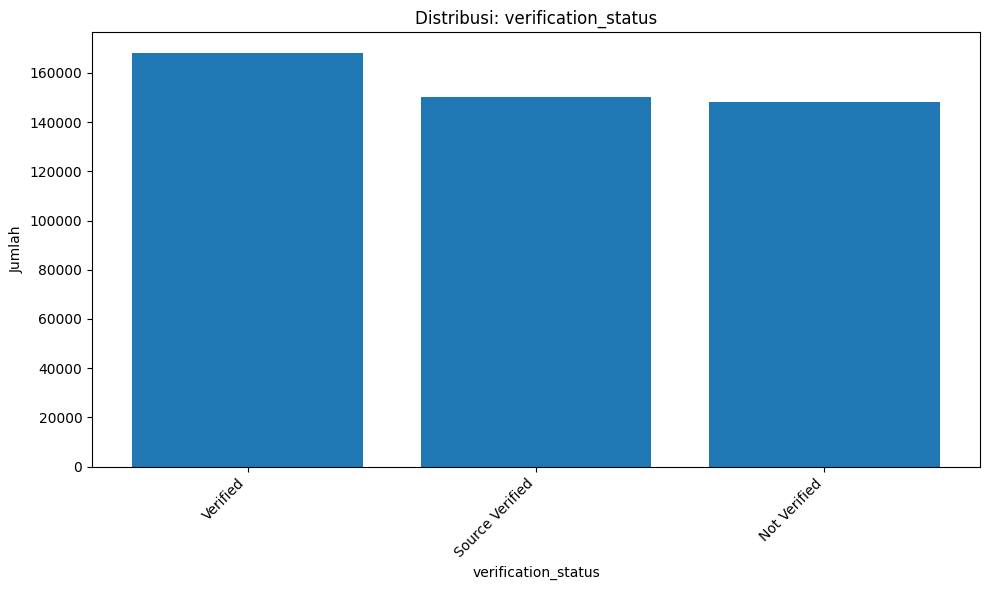

<Figure size 1000x600 with 0 Axes>

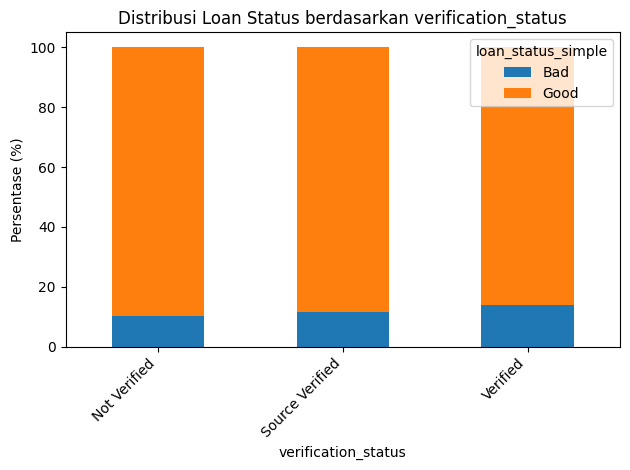


ANALISIS UNTUK: purpose


,Jumlah,Persentase (%)
purpose,,
debt_consolidation,274195,58.804165
credit_card,104157,22.337626
home_improvement,26537,5.691155
other,23690,5.080584
major_purchase,9828,2.107724
small_business,7013,1.504016
car,5397,1.157447
medical,4602,0.986950
moving,2994,0.642097


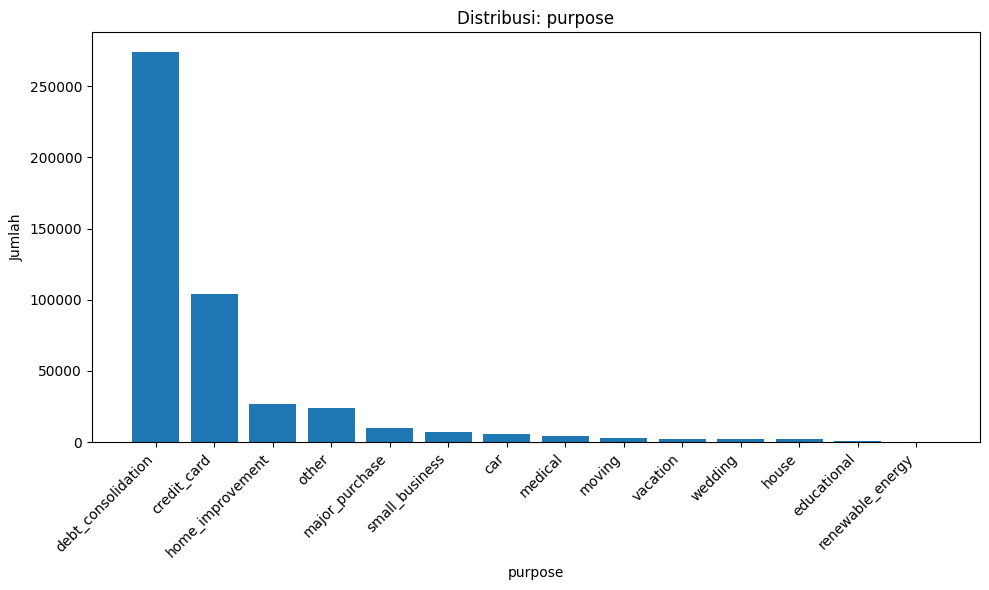

<Figure size 1000x600 with 0 Axes>

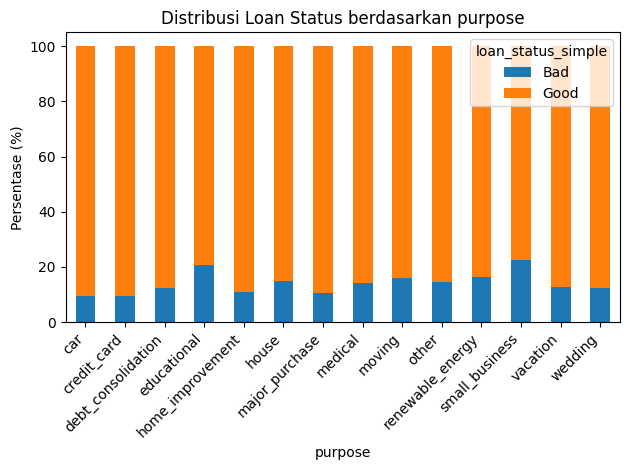


ANALISIS UNTUK: term


,Jumlah,Persentase (%)
term,,
36 months,337953,72.477776
60 months,128332,27.522224


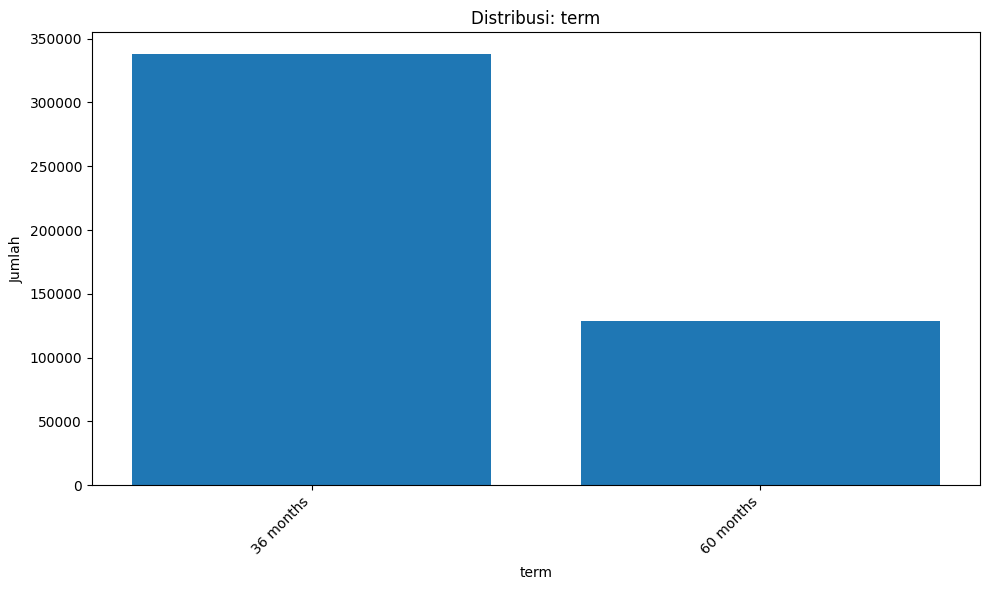

<Figure size 1000x600 with 0 Axes>

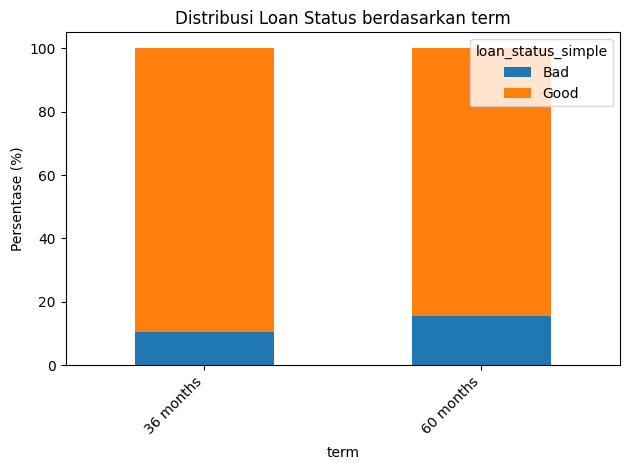

In [49]:
# Pilih variabel kategorikal penting
kategorikal_penting = ['grade', 'sub_grade', 'emp_length', 'home_ownership',
                       'verification_status', 'purpose', 'term']

# Hanya pilih kolom yang ada dalam dataset
kategorikal_penting = [col for col in kategorikal_penting if col in df.columns]

# Analisis untuk setiap variabel kategorikal
for col in kategorikal_penting:
    print(f"\nANALISIS UNTUK: {col}")

    # Hitung frekuensi dan persentase
    value_counts = df[col].value_counts()
    value_percent = (value_counts / len(df)) * 100

    # Tampilkan dalam DataFrame
    cat_stats = pd.DataFrame({
        'Jumlah': value_counts,
        'Persentase (%)': value_percent
    })

    display(cat_stats)

    # Visualisasi
    plt.figure(figsize=(10, 6))
    plt.bar(value_counts.index, value_counts.values)
    plt.title(f'Distribusi: {col}')
    plt.xlabel(col)
    plt.ylabel('Jumlah')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

    # Jika ada loan_status, tampilkan distribusi loan_status per kategori
    if 'loan_status' in df.columns and df['loan_status'].nunique() <= 10:
        # Kelompokkan loan_status menjadi Good dan Bad untuk visualisasi yang lebih jelas
        # Ini perlu disesuaikan dengan nilai unik di dataset Anda
        df_temp = df.copy()
        df_temp['loan_status_simple'] = df['loan_status'].apply(lambda x: 'Good' if x in good_status else 'Bad')

        cross_tab = pd.crosstab(df_temp[col], df_temp['loan_status_simple'], normalize='index') * 100
        plt.figure(figsize=(10, 6))
        cross_tab.plot(kind='bar', stacked=True)
        plt.title(f'Distribusi Loan Status berdasarkan {col}')
        plt.xlabel(col)
        plt.ylabel('Persentase (%)')
        plt.xticks(rotation=45, ha='right')
        plt.tight_layout()
        plt.show()

**Pola Umum dalam data**

Hubungan antara variabel

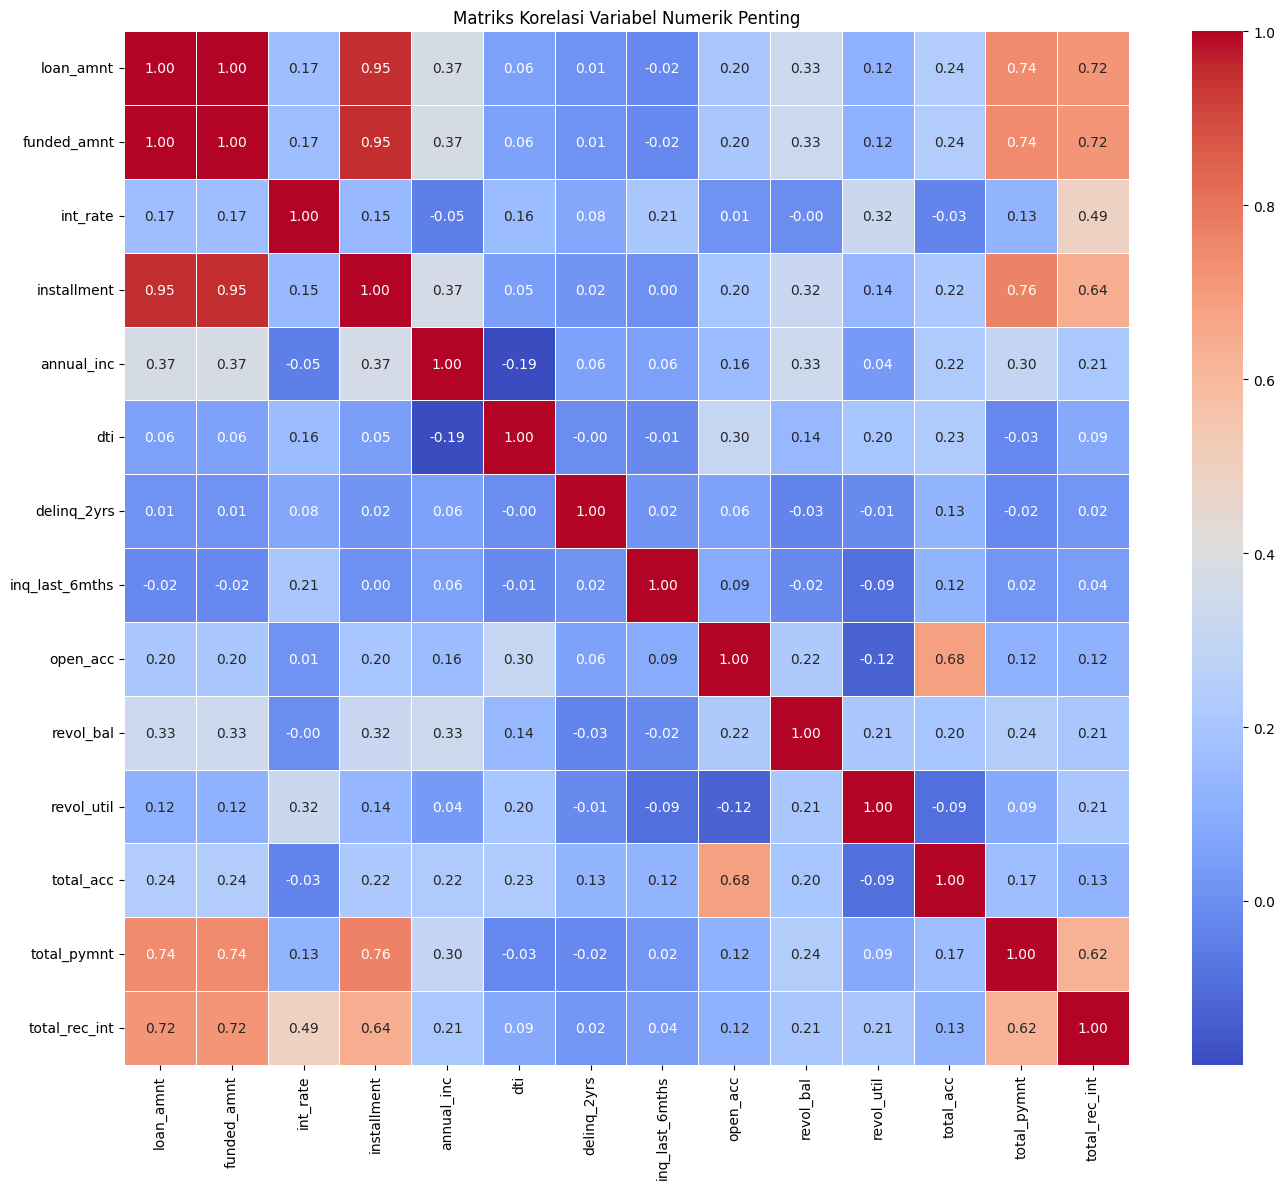

In [50]:
# Analisis korelasi antara variabel numerik penting
correlation_matrix = df[numerik_penting].corr()

# Visualisasi dengan heatmap
plt.figure(figsize=(14, 12))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Matriks Korelasi Variabel Numerik Penting')
plt.tight_layout()
plt.show()

Hubungan anatar grade pinjaman dan interest rate

Text(0.5, 1.0, 'Rata-rata Interest Rate berdasarkan Grade')

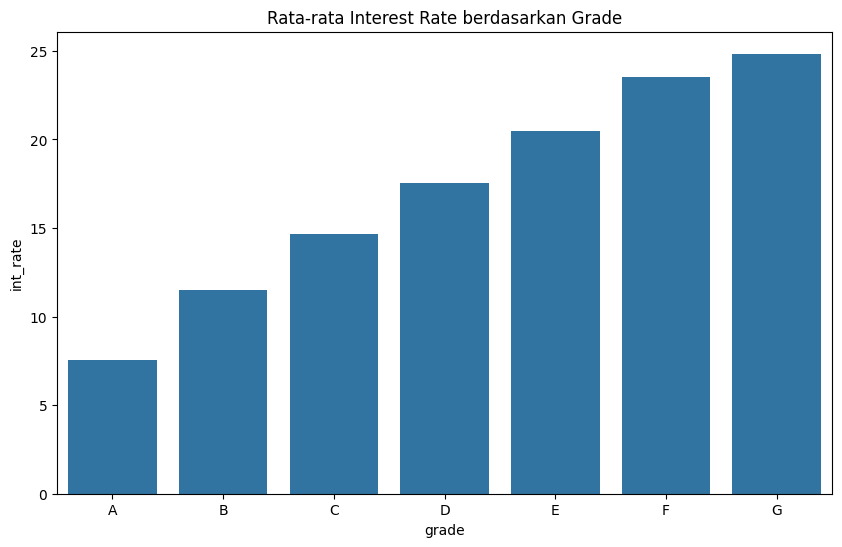

In [51]:
# Rata-rata interest rate per grade
grade_int_rate = df.groupby('grade')['int_rate'].mean().reset_index()

plt.figure(figsize=(10, 6))
sns.barplot(x='grade', y='int_rate', data=grade_int_rate)
plt.title('Rata-rata Interest Rate berdasarkan Grade')

Hubungan antara grade dan loan_status

Text(0.5, 1.0, 'Persentase Good/Bad Loans berdasarkan Grade')

<Figure size 1000x600 with 0 Axes>

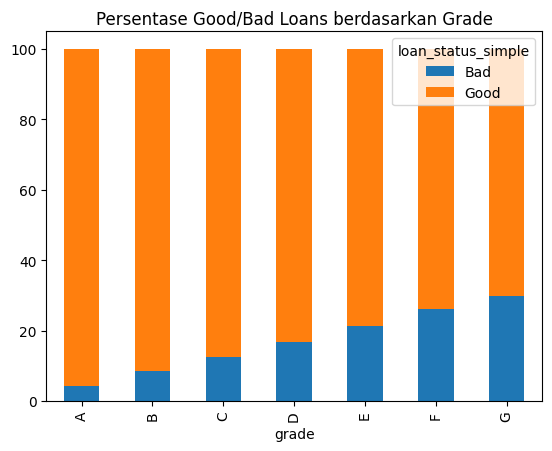

In [52]:
# Distribution of good/bad loans by grade
grade_status = pd.crosstab(df_temp['grade'], df_temp['loan_status_simple'], normalize='index') * 100

plt.figure(figsize=(10, 6))
grade_status.plot(kind='bar', stacked=True)
plt.title('Persentase Good/Bad Loans berdasarkan Grade')

Distribusi variabel utama

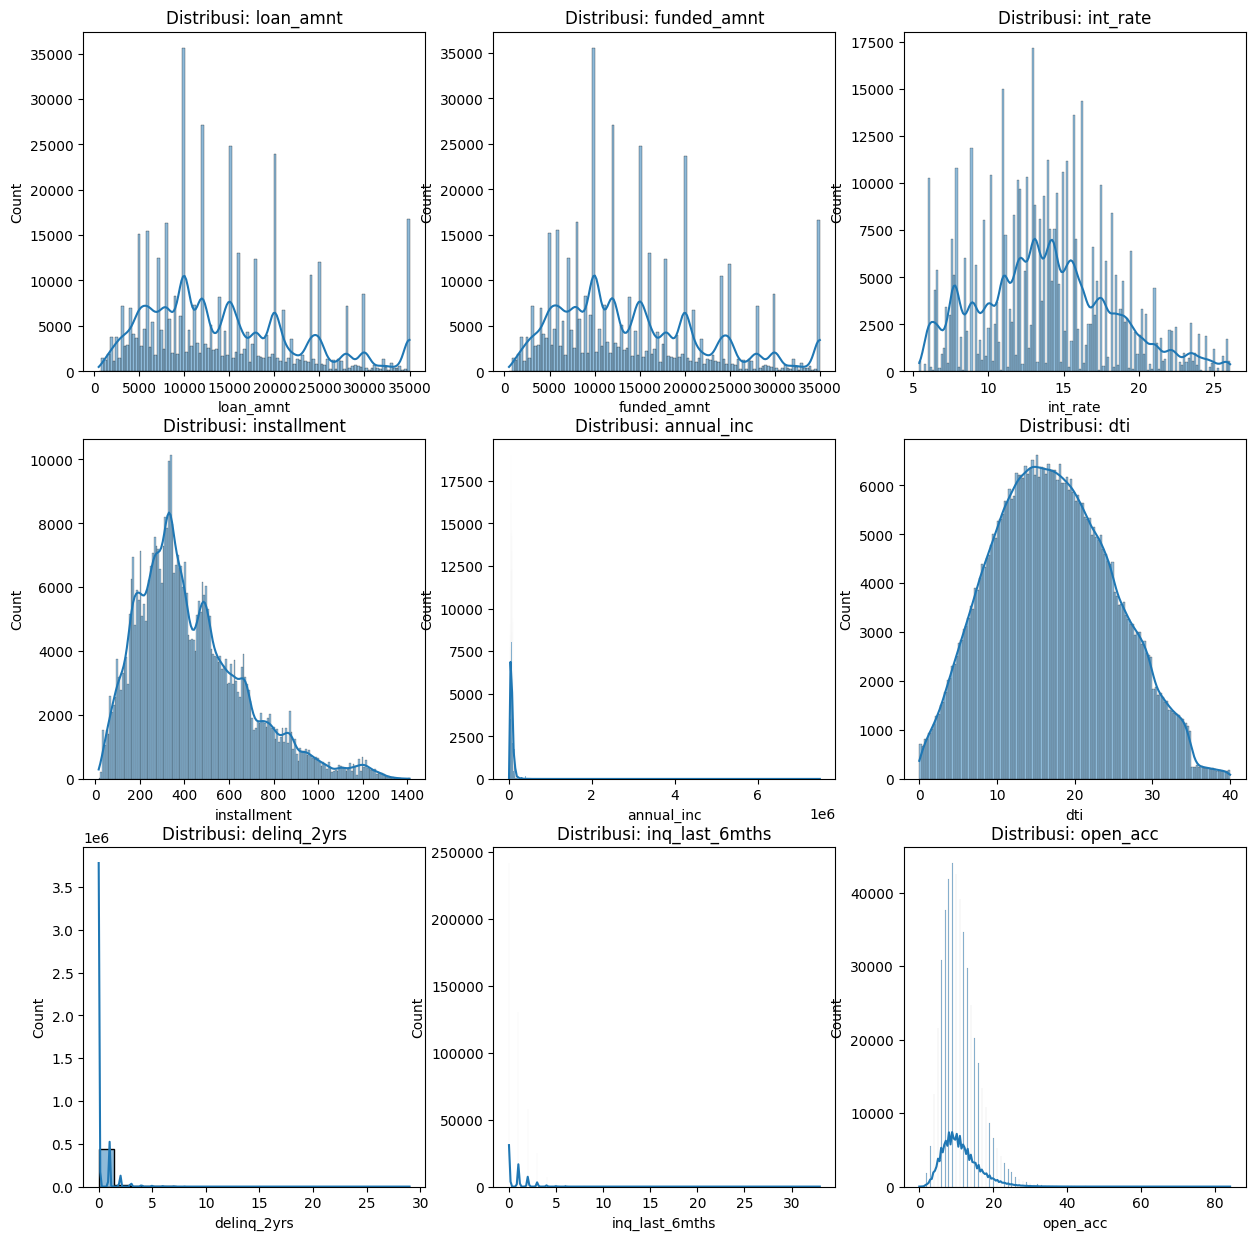

In [53]:
# Visualisasi histogram untuk variabel numerik penting
plt.figure(figsize=(15, 15))
for i, col in enumerate(numerik_penting[:9], 1):
    plt.subplot(3, 3, i)
    sns.histplot(df[col].dropna(), kde=True)
    plt.title(f'Distribusi: {col}')

Pola keterlambatan pembayaran

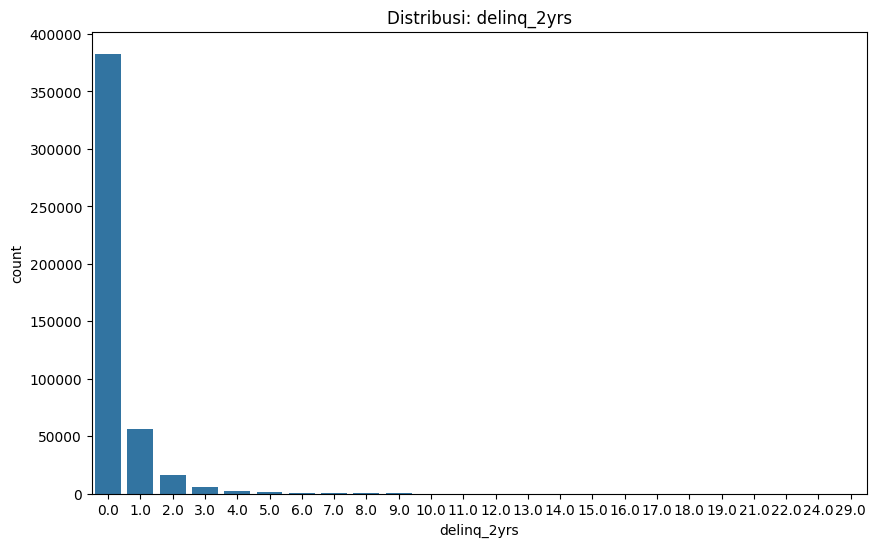

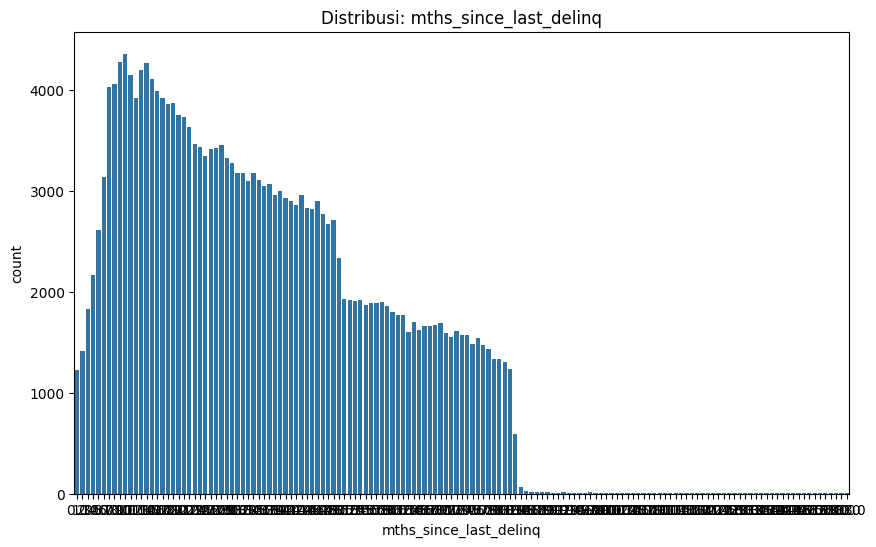

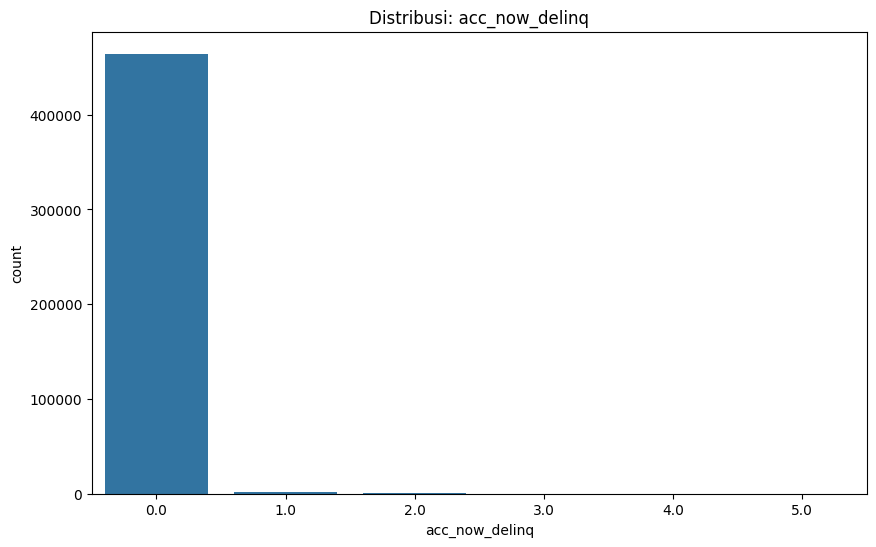

In [54]:
# Analisis variabel keterlambatan pembayaran
delinq_vars = ['delinq_2yrs', 'mths_since_last_delinq', 'acc_now_delinq']
delinq_vars = [col for col in delinq_vars if col in df.columns]

for col in delinq_vars:
    plt.figure(figsize=(10, 6))
    sns.countplot(x=df[col])
    plt.title(f'Distribusi: {col}')
    plt.show()

analisis missing value


ANALISIS NILAI YANG HILANG:


,Jumlah Nilai Hilang,Persentase (%)
inq_fi,466285,100.0
all_util,466285,100.0
max_bal_bc,466285,100.0
open_rv_24m,466285,100.0
open_rv_12m,466285,100.0
il_util,466285,100.0
total_bal_il,466285,100.0
mths_since_rcnt_il,466285,100.0
open_il_24m,466285,100.0
open_il_12m,466285,100.0


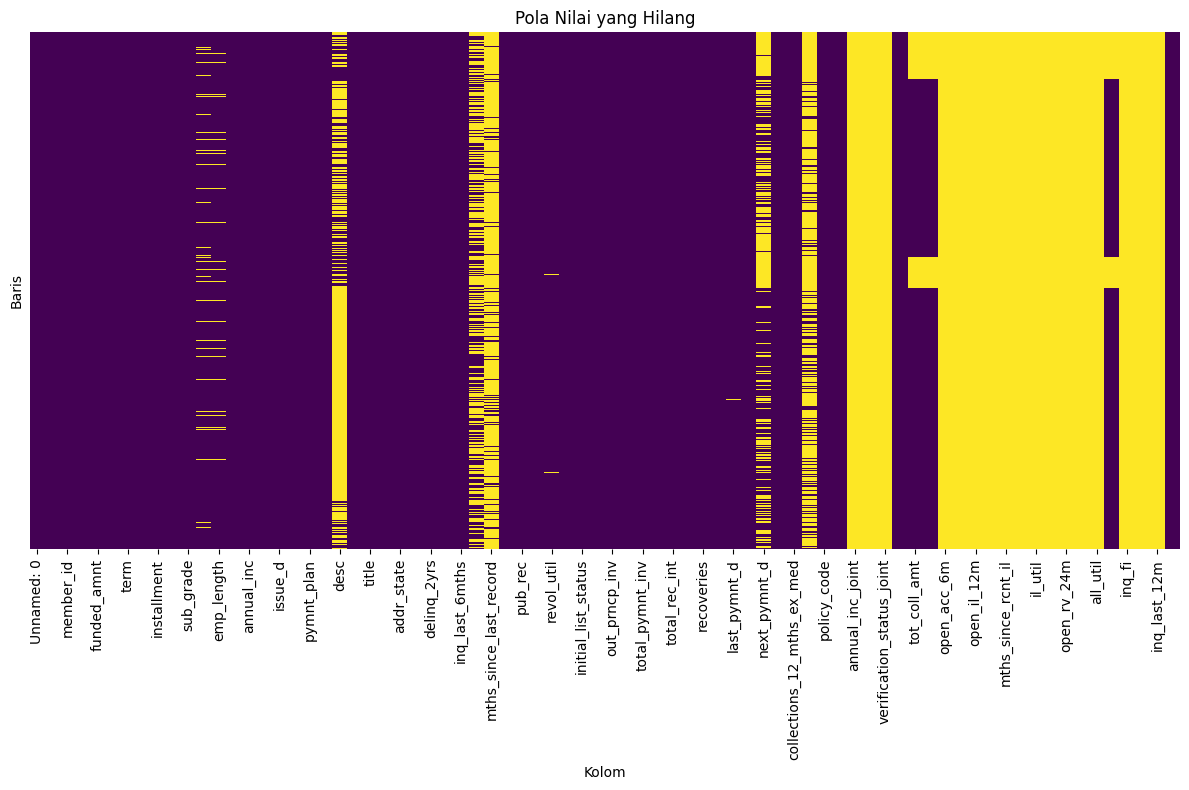


DETEKSI OUTLIER UNTUK VARIABEL NUMERIK PENTING:

loan_amnt:
  Jumlah outlier: 0 (0.00%)
  Batas normal: -10000.00 hingga 38000.00
  Range aktual: 500.00 hingga 35000.00


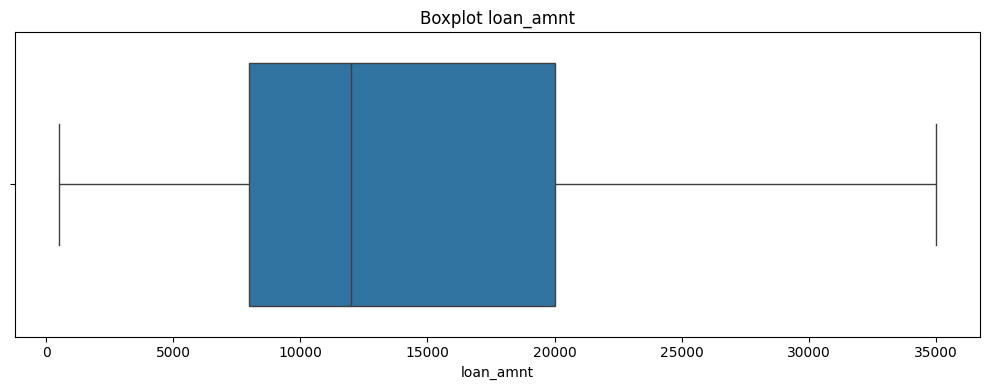


funded_amnt:
  Jumlah outlier: 0 (0.00%)
  Batas normal: -10000.00 hingga 38000.00
  Range aktual: 500.00 hingga 35000.00


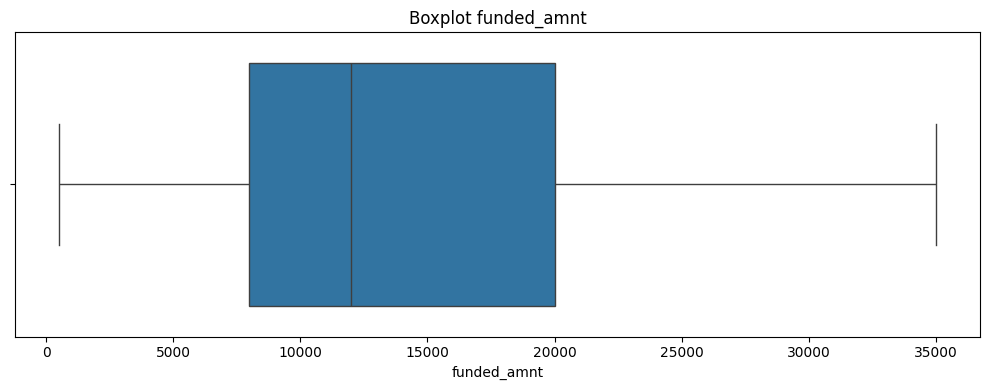


int_rate:
  Jumlah outlier: 4904 (1.05%)
  Batas normal: 2.74 hingga 24.74
  Range aktual: 5.42 hingga 26.06


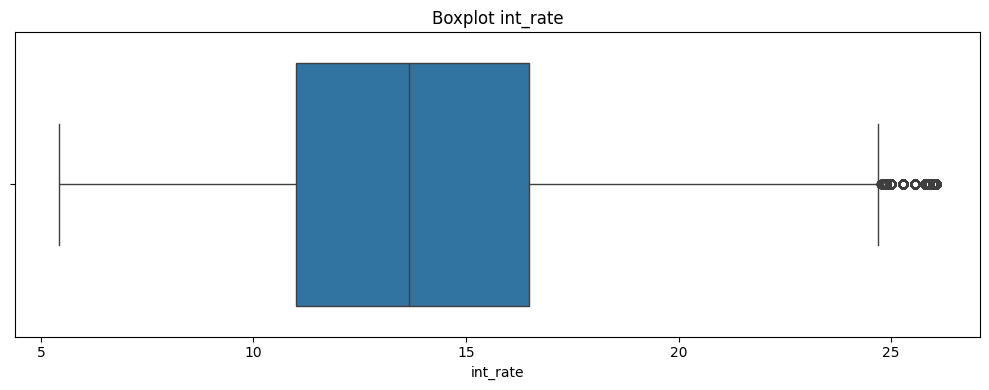


installment:
  Jumlah outlier: 11711 (2.51%)
  Batas normal: -208.15 hingga 1031.41
  Range aktual: 15.67 hingga 1409.99


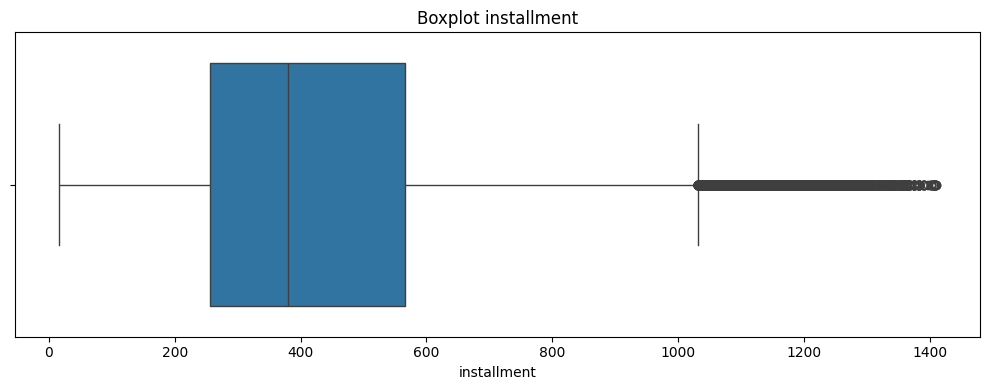


annual_inc:
  Jumlah outlier: 19899 (4.27%)
  Batas normal: -20940.00 hingga 154900.00
  Range aktual: 1896.00 hingga 7500000.00


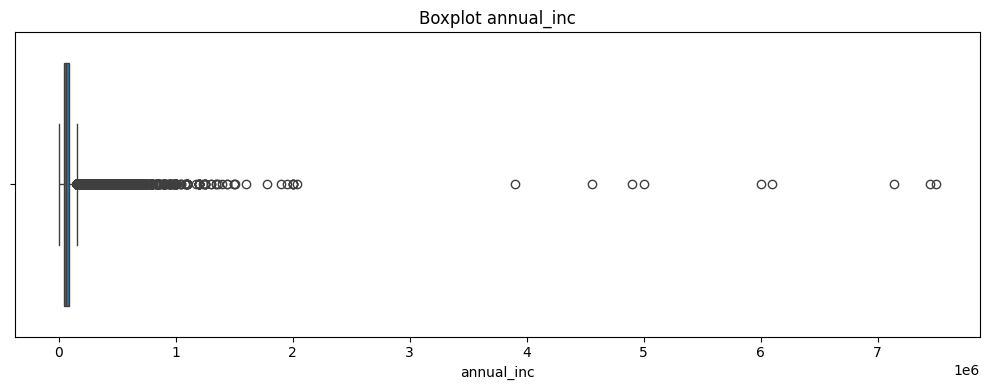

In [55]:
# Analisis nilai yang hilang
nilai_hilang = df.isnull().sum()
persen_hilang = (nilai_hilang / len(df)) * 100

# Buat DataFrame untuk tampilan yang lebih baik
missing_df = pd.DataFrame({
    'Jumlah Nilai Hilang': nilai_hilang,
    'Persentase (%)': persen_hilang
})

# Urutkan dari yang terbanyak
missing_df = missing_df.sort_values('Jumlah Nilai Hilang', ascending=False)

# Filter hanya yang memiliki nilai hilang
missing_df_filtered = missing_df[missing_df['Jumlah Nilai Hilang'] > 0]

print("\nANALISIS NILAI YANG HILANG:")
if missing_df_filtered.empty:
    print("Tidak ada nilai yang hilang dalam dataset.")
else:
    # Tampilkan 15 kolom dengan nilai hilang terbanyak
    display(missing_df_filtered.head(15))

    # Visualisasi heatmap untuk melihat pola nilai hilang
    plt.figure(figsize=(12, 8))
    sns.heatmap(df.isnull(), cbar=False, yticklabels=False,
                cmap='viridis')
    plt.title('Pola Nilai yang Hilang')
    plt.xlabel('Kolom')
    plt.ylabel('Baris')
    plt.tight_layout()
    plt.show()

# Deteksi outlier untuk variabel numerik penting
print("\nDETEKSI OUTLIER UNTUK VARIABEL NUMERIK PENTING:")
for col in numerik_penting[:5]:  # Pilih 5 kolom penting saja
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)][col]
    outlier_percent = (len(outliers) / df[col].count()) * 100

    print(f"\n{col}:")
    print(f"  Jumlah outlier: {len(outliers)} ({outlier_percent:.2f}%)")
    print(f"  Batas normal: {lower_bound:.2f} hingga {upper_bound:.2f}")
    print(f"  Range aktual: {df[col].min():.2f} hingga {df[col].max():.2f}")

    # Boxplot untuk visualisasi outlier
    plt.figure(figsize=(10, 4))
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot {col}')
    plt.tight_layout()
    plt.show()

Pola tujuan


ANALISIS BERDASARKAN PURPOSE (TUJUAN PINJAMAN):


,Jumlah,Persentase (%)
purpose,,
debt_consolidation,274195,58.804165
credit_card,104157,22.337626
home_improvement,26537,5.691155
other,23690,5.080584
major_purchase,9828,2.107724
small_business,7013,1.504016
car,5397,1.157447
medical,4602,0.986950
moving,2994,0.642097


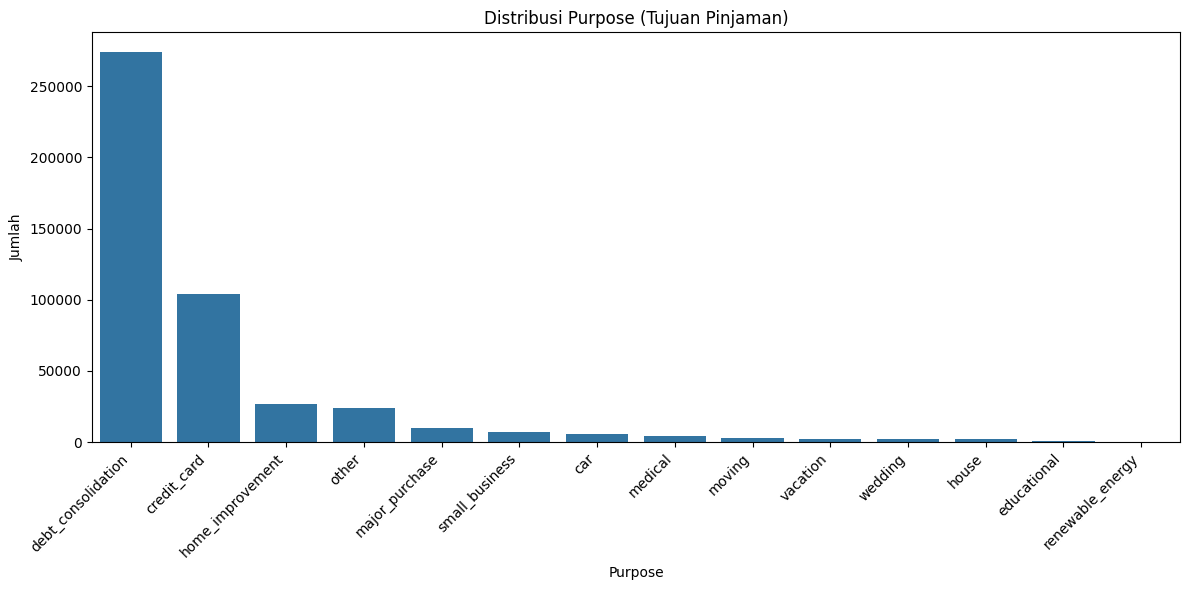

<Figure size 1400x700 with 0 Axes>

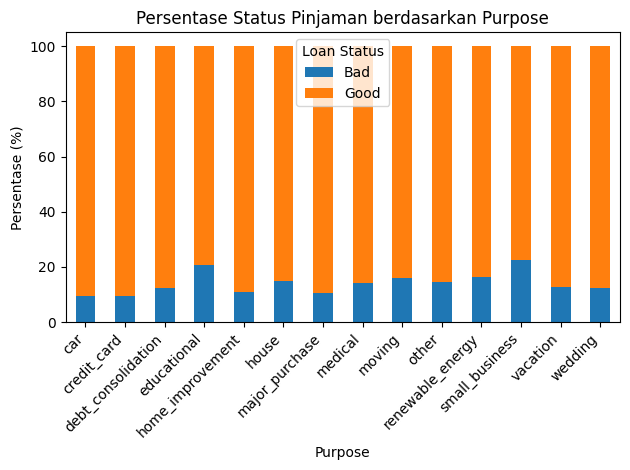

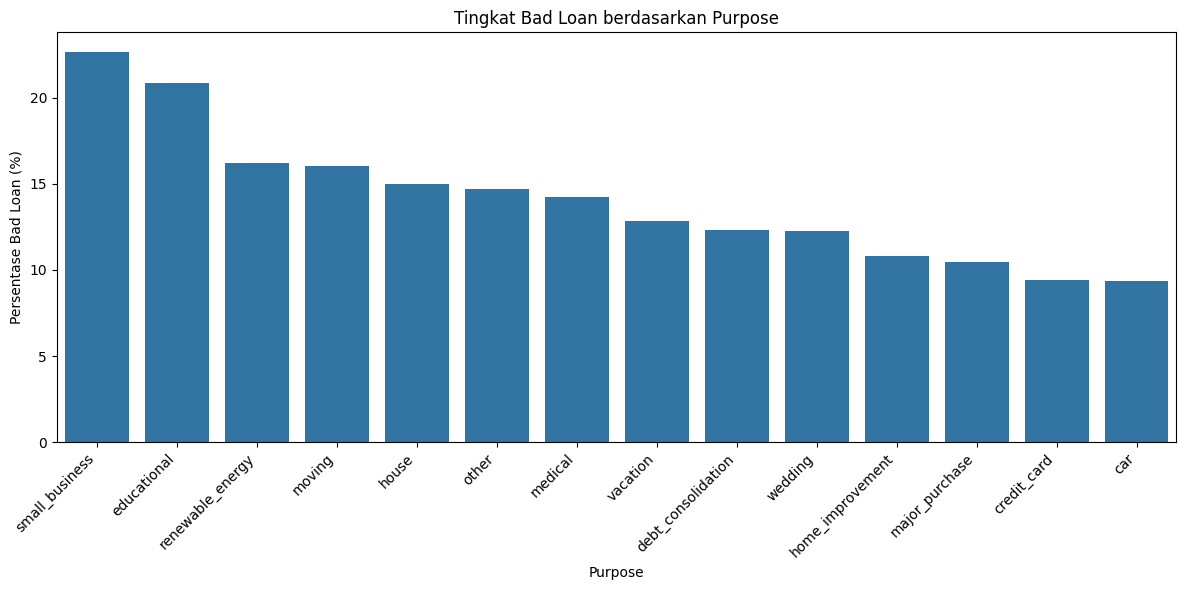


TINGKAT BAD LOAN BERDASARKAN PURPOSE:


,Persentase Bad Loan (%)
purpose,
small_business,22.672180
educational,20.853081
renewable_energy,16.239316
moving,16.032064
house,14.984575
other,14.693964
medical,14.254672
vacation,12.866908
debt_consolidation,12.331370


In [56]:
# Analisis pola berdasarkan purpose (tujuan pinjaman)
if all(col in df.columns for col in ['purpose', 'loan_status_simple']):
    print("\nANALISIS BERDASARKAN PURPOSE (TUJUAN PINJAMAN):")

    # Distribusi purpose
    purpose_counts = df['purpose'].value_counts()
    purpose_percent = (purpose_counts / len(df)) * 100

    # Buat DataFrame untuk tampilan yang lebih baik
    purpose_df = pd.DataFrame({
        'Jumlah': purpose_counts,
        'Persentase (%)': purpose_percent
    })

    display(purpose_df)

    # Visualisasi distribusi purpose
    plt.figure(figsize=(12, 6))
    sns.barplot(x=purpose_counts.index, y=purpose_counts.values)
    plt.title('Distribusi Purpose (Tujuan Pinjaman)')
    plt.xlabel('Purpose')
    plt.ylabel('Jumlah')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

    # Analisis status berdasarkan purpose
    purpose_status = pd.crosstab(df['purpose'], df['loan_status_simple'], normalize='index') * 100

    # Visualisasi
    plt.figure(figsize=(14, 7))
    purpose_status.plot(kind='bar', stacked=True)
    plt.title('Persentase Status Pinjaman berdasarkan Purpose')
    plt.xlabel('Purpose')
    plt.ylabel('Persentase (%)')
    plt.legend(title='Loan Status')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

    # Urutkan purpose berdasarkan tingkat Bad loan
    if 'Bad' in purpose_status.columns:
        bad_rate_by_purpose = purpose_status['Bad'].sort_values(ascending=False)

        plt.figure(figsize=(12, 6))
        sns.barplot(x=bad_rate_by_purpose.index, y=bad_rate_by_purpose.values)
        plt.title('Tingkat Bad Loan berdasarkan Purpose')
        plt.xlabel('Purpose')
        plt.ylabel('Persentase Bad Loan (%)')
        plt.xticks(rotation=45, ha='right')
        plt.tight_layout()
        plt.show()

        print("\nTINGKAT BAD LOAN BERDASARKAN PURPOSE:")
        bad_rate_df = pd.DataFrame({'Persentase Bad Loan (%)': bad_rate_by_purpose})
        display(bad_rate_df)

Pola durasi Peminjaman

<Figure size 1000x600 with 0 Axes>

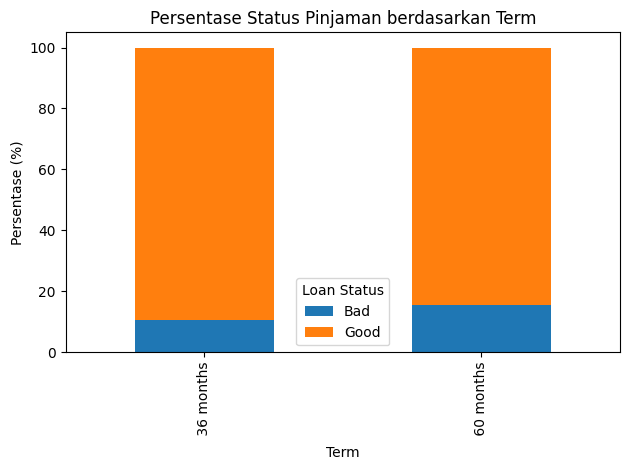

In [57]:
# Analisis pola berdasarkan term
if all(col in df.columns for col in ['term', 'loan_status_simple']):
    term_status = pd.crosstab(df['term'], df['loan_status_simple'], normalize='index') * 100

    plt.figure(figsize=(10, 6))
    term_status.plot(kind='bar', stacked=True)
    plt.title('Persentase Status Pinjaman berdasarkan Term')
    plt.xlabel('Term')
    plt.ylabel('Persentase (%)')
    plt.legend(title='Loan Status')
    plt.tight_layout()
    plt.show()

# 2. Exploratory Data Analysis (EDA)

Import library yang dibutuhkan

In [58]:
import warnings
warnings.filterwarnings('ignore')

Melakukan visualisasi data menggunakan grafik dan plot
untuk memahami hubungan antar variabel. **bold text**


TOP 10 FITUR BERDASARKAN KORELASI DENGAN TARGET:


,Fitur,Korelasi dengan Bad Loan
50,target_numeric,1.000000
23,recoveries,0.421185
24,collection_recovery_fee,0.285672
20,total_rec_prncp,-0.254151
19,total_pymnt_inv,-0.191999
18,total_pymnt,-0.191512
3,int_rate,0.179823
25,last_pymnt_amnt,-0.175568
22,total_rec_late_fee,0.160601
16,out_prncp,-0.130341


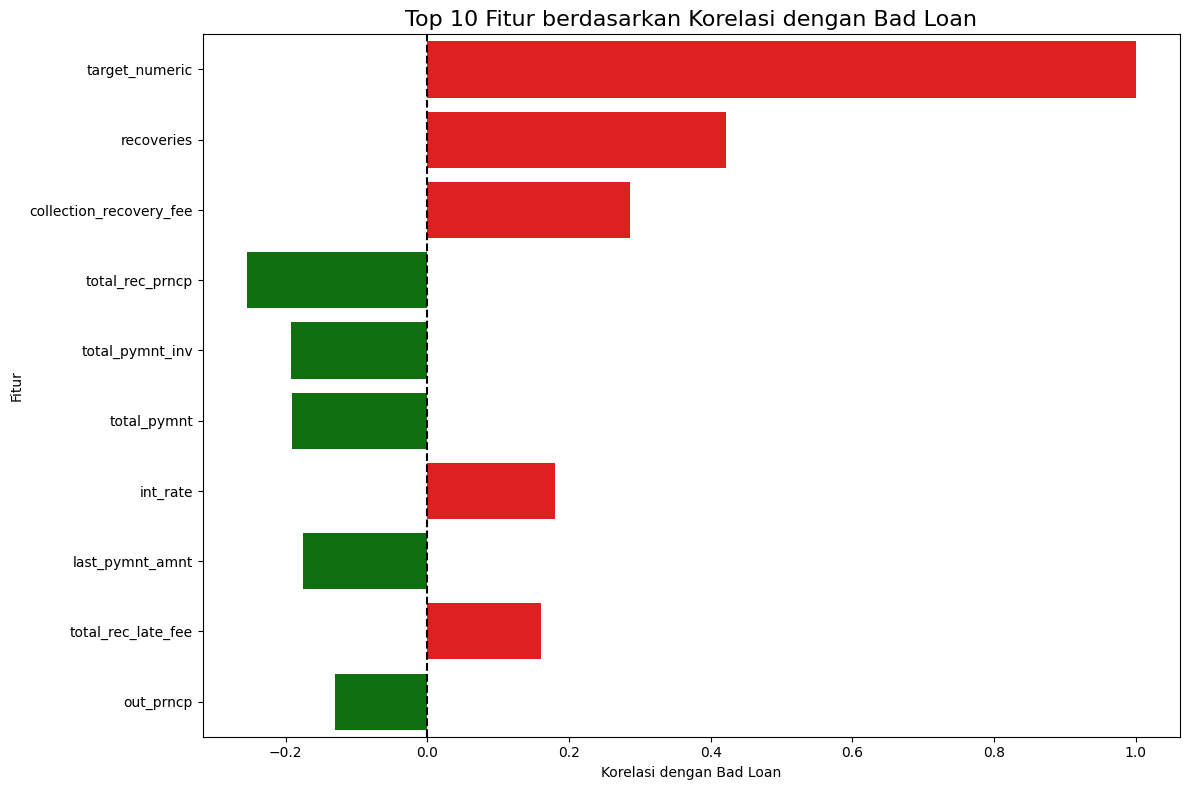

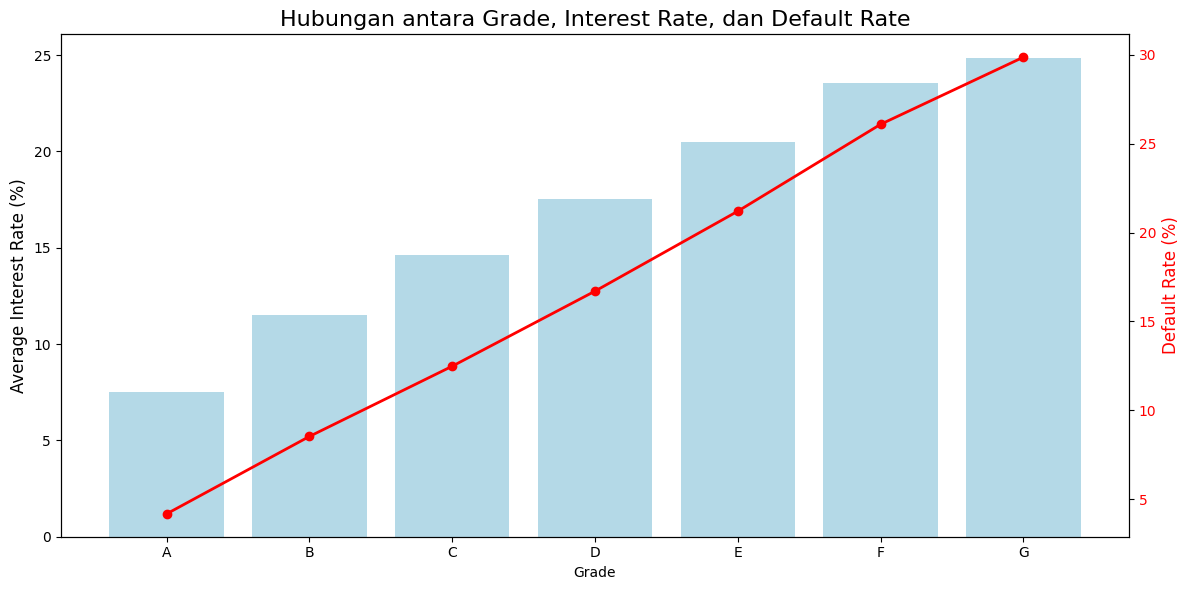

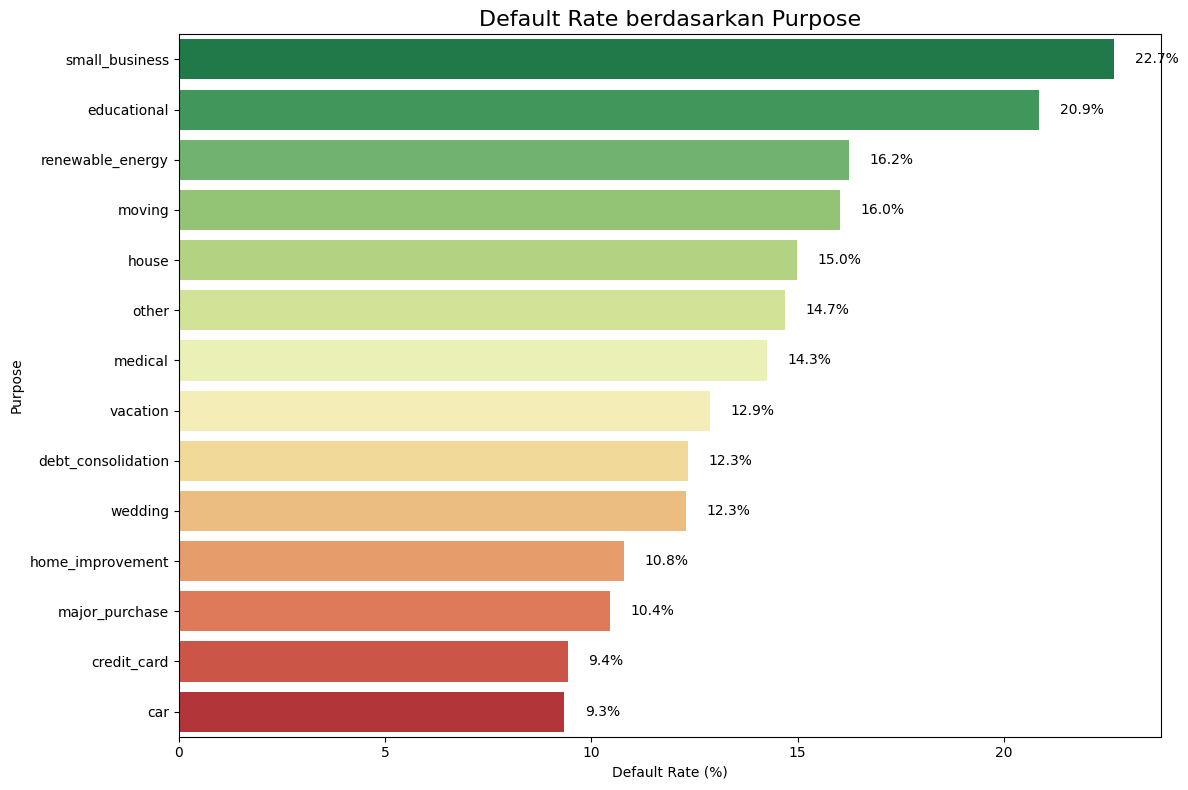

In [62]:
# Definisikan terlebih dahulu target biner loan_status_simple
if 'loan_status_simple' not in df.columns:
    # Definisikan kategori status
    good_status = ['Fully Paid', 'Current', 'Does not meet the credit policy. Status:Fully Paid']
    bad_status = ['Charged Off', 'Default', 'Late (31-120 days)', 'Late (16-30 days)',
                 'In Grace Period', 'Does not meet the credit policy. Status:Charged Off']

    # Buat kolom target biner
    df['loan_status_simple'] = df['loan_status'].apply(
        lambda x: 'Good' if x in good_status else 'Bad'
    )

# Konversi target ke numeric untuk analysis korelasi
df['target_numeric'] = df['loan_status_simple'].map({'Good': 0, 'Bad': 1})

# Pilih fitur numerik untuk analisis korelasi (kecuali kolom ID)
numerik_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
numerik_cols = [col for col in numerik_cols if not col.startswith(('id', 'member_id', 'Unnamed'))]

# Hitung korelasi fitur-fitur dengan target
target_corr = []
for col in numerik_cols:
    # Ensure the column exists in the dataframe and is numeric
    if col in df.columns and pd.api.types.is_numeric_dtype(df[col]):
        correlation = df[col].corr(df['target_numeric'])
        target_corr.append((col, correlation))
    else:
        print(f"Warning: Column '{col}' not found or not numeric. Skipping correlation calculation.")


# Urutkan dan buat DataFrame
target_corr_df = pd.DataFrame(target_corr, columns=['Fitur', 'Korelasi dengan Bad Loan'])
target_corr_df = target_corr_df.sort_values('Korelasi dengan Bad Loan', key=abs, ascending=False)

# Tampilkan 10 fitur dengan korelasi tertinggi
print("\nTOP 10 FITUR BERDASARKAN KORELASI DENGAN TARGET:")
display(target_corr_df.head(10))

# Visualisasi korelasi dengan target (top 10)
plt.figure(figsize=(12, 8))
top_corr = target_corr_df.head(10)
colors = ['red' if x > 0 else 'green' for x in top_corr['Korelasi dengan Bad Loan']]

sns.barplot(x='Korelasi dengan Bad Loan', y='Fitur', data=top_corr, palette=colors)
plt.title('Top 10 Fitur berdasarkan Korelasi dengan Bad Loan', fontsize=16)
plt.axvline(x=0, color='k', linestyle='--')
plt.tight_layout()
plt.show()

# Analisis hubungan antara grade, int_rate dan default rate
if all(col in df.columns for col in ['grade', 'int_rate']):
    # Hitung statistik per grade
    grade_stats = df.groupby('grade').agg({
        'int_rate': 'mean',
        'target_numeric': 'mean'  # target_numeric: 0=Good, 1=Bad
    }).reset_index()

    # Rename kolom dan konversi ke persentase
    grade_stats.columns = ['Grade', 'Avg Interest Rate', 'Default Rate']
    grade_stats['Default Rate'] = grade_stats['Default Rate'] * 100

    # Sort berdasarkan grade
    grade_stats = grade_stats.sort_values('Grade')

    # Buat dual-axis plot
    fig, ax1 = plt.subplots(figsize=(12, 6))

    # Plot interest rate (bar)
    sns.barplot(x='Grade', y='Avg Interest Rate', data=grade_stats,
                color='skyblue', alpha=0.7, ax=ax1)
    ax1.set_ylabel('Average Interest Rate (%)', fontsize=12)

    # Tambahkan sumbu y kedua untuk default rate
    ax2 = ax1.twinx()
    ax2.plot(grade_stats.index, grade_stats['Default Rate'], 'ro-', linewidth=2)
    ax2.set_ylabel('Default Rate (%)', color='red', fontsize=12)
    ax2.tick_params(axis='y', labelcolor='red')

    plt.title('Hubungan antara Grade, Interest Rate, dan Default Rate', fontsize=16)
    plt.tight_layout()
    plt.show()

# Visualisasi hubungan purpose dengan default rate
if 'purpose' in df.columns:
    # Hitung default rate per purpose
    purpose_default = df.groupby('purpose')['target_numeric'].mean() * 100
    purpose_default = purpose_default.sort_values(ascending=False)

    plt.figure(figsize=(12, 8))
    sns.barplot(x=purpose_default.values, y=purpose_default.index, palette='RdYlGn_r')
    plt.title('Default Rate berdasarkan Purpose', fontsize=16)
    plt.xlabel('Default Rate (%)')
    plt.ylabel('Purpose')

    # Tambahkan label nilai
    for i, v in enumerate(purpose_default):
        plt.text(v + 0.5, i, f"{v:.1f}%", va='center')

    plt.tight_layout()
    plt.show()

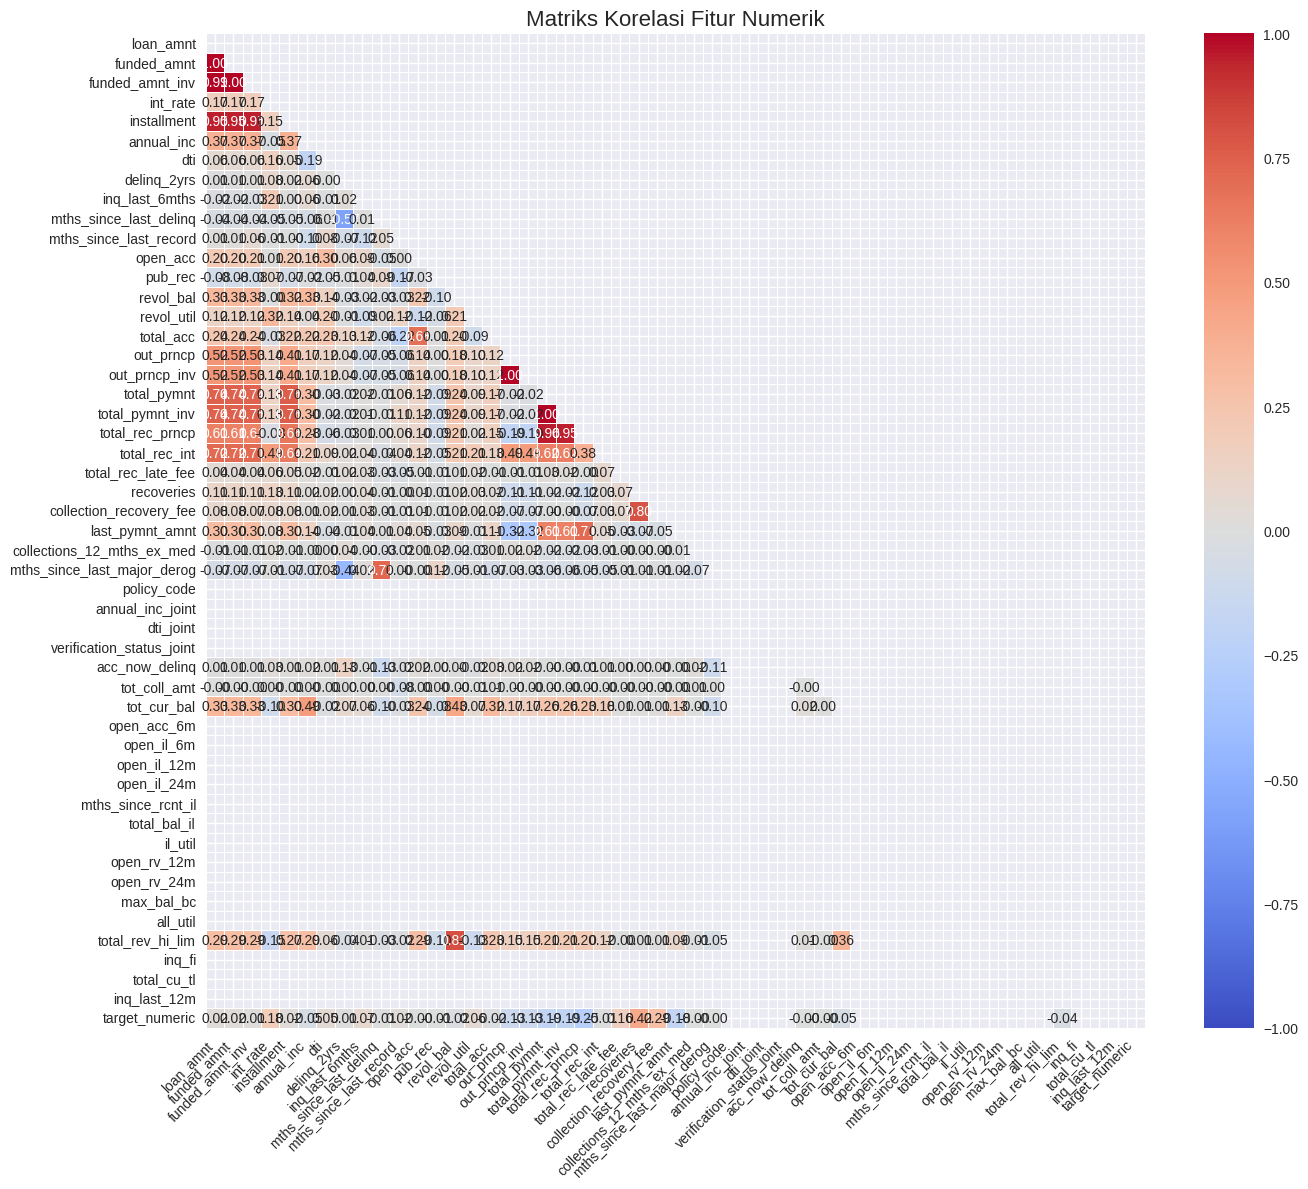


PASANGAN FITUR DENGAN KORELASI TINGGI (|r| > 0.7):


,Fitur 1,Fitur 2,Korelasi
6,out_prncp_inv,out_prncp,0.999998
0,funded_amnt,loan_amnt,0.998548
2,funded_amnt_inv,funded_amnt,0.996125
15,total_pymnt_inv,total_pymnt,0.995862
1,funded_amnt_inv,loan_amnt,0.994347
16,total_rec_prncp,total_pymnt,0.956658
17,total_rec_prncp,total_pymnt_inv,0.952158
4,installment,funded_amnt,0.951787
3,installment,loan_amnt,0.949666
5,installment,funded_amnt_inv,0.947387


In [63]:
# Konfigurasi tampilan dasar
plt.style.use('seaborn-v0_8')
plt.rcParams['figure.figsize'] = (12, 8)

# Pilih fitur numerik untuk analisis korelasi (kecuali kolom ID)
numerik_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
numerik_cols = [col for col in numerik_cols if not col.startswith(('id', 'member_id', 'Unnamed'))]

# Konversi kolom persentase jika diperlukan (seperti int_rate, revol_util)
for col in ['int_rate', 'revol_util']:
    if col in df.columns and df[col].dtype == 'object':
        df[col] = df[col].str.replace('%', '').astype(float)

# Hitung matriks korelasi
corr_matrix = df[numerik_cols].corr()

# Buat mask untuk segitiga atas (menghindari redundansi)
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

# Plot matriks korelasi dengan heatmap
plt.figure(figsize=(14, 12))
sns.heatmap(corr_matrix, mask=mask, annot=True, cmap='coolwarm',
            fmt='.2f', linewidths=0.5, vmin=-1, vmax=1)
plt.title('Matriks Korelasi Fitur Numerik', fontsize=16)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Filter korelasi tinggi (|r| > 0.7) untuk analisis lebih lanjut
high_corr = []
for i in range(len(corr_matrix.columns)):
    for j in range(i):
        if abs(corr_matrix.iloc[i, j]) > 0.7:
            high_corr.append((corr_matrix.columns[i], corr_matrix.columns[j], corr_matrix.iloc[i, j]))

# Tampilkan korelasi tinggi
if high_corr:
    print("\nPASANGAN FITUR DENGAN KORELASI TINGGI (|r| > 0.7):")
    high_corr_df = pd.DataFrame(high_corr, columns=['Fitur 1', 'Fitur 2', 'Korelasi'])
    high_corr_df = high_corr_df.sort_values('Korelasi', key=abs, ascending=False)
    display(high_corr_df)

**Melakukan analisis univariat dan bivariat untuk mendapatkan wawasan yang lebih dalam tentang data**

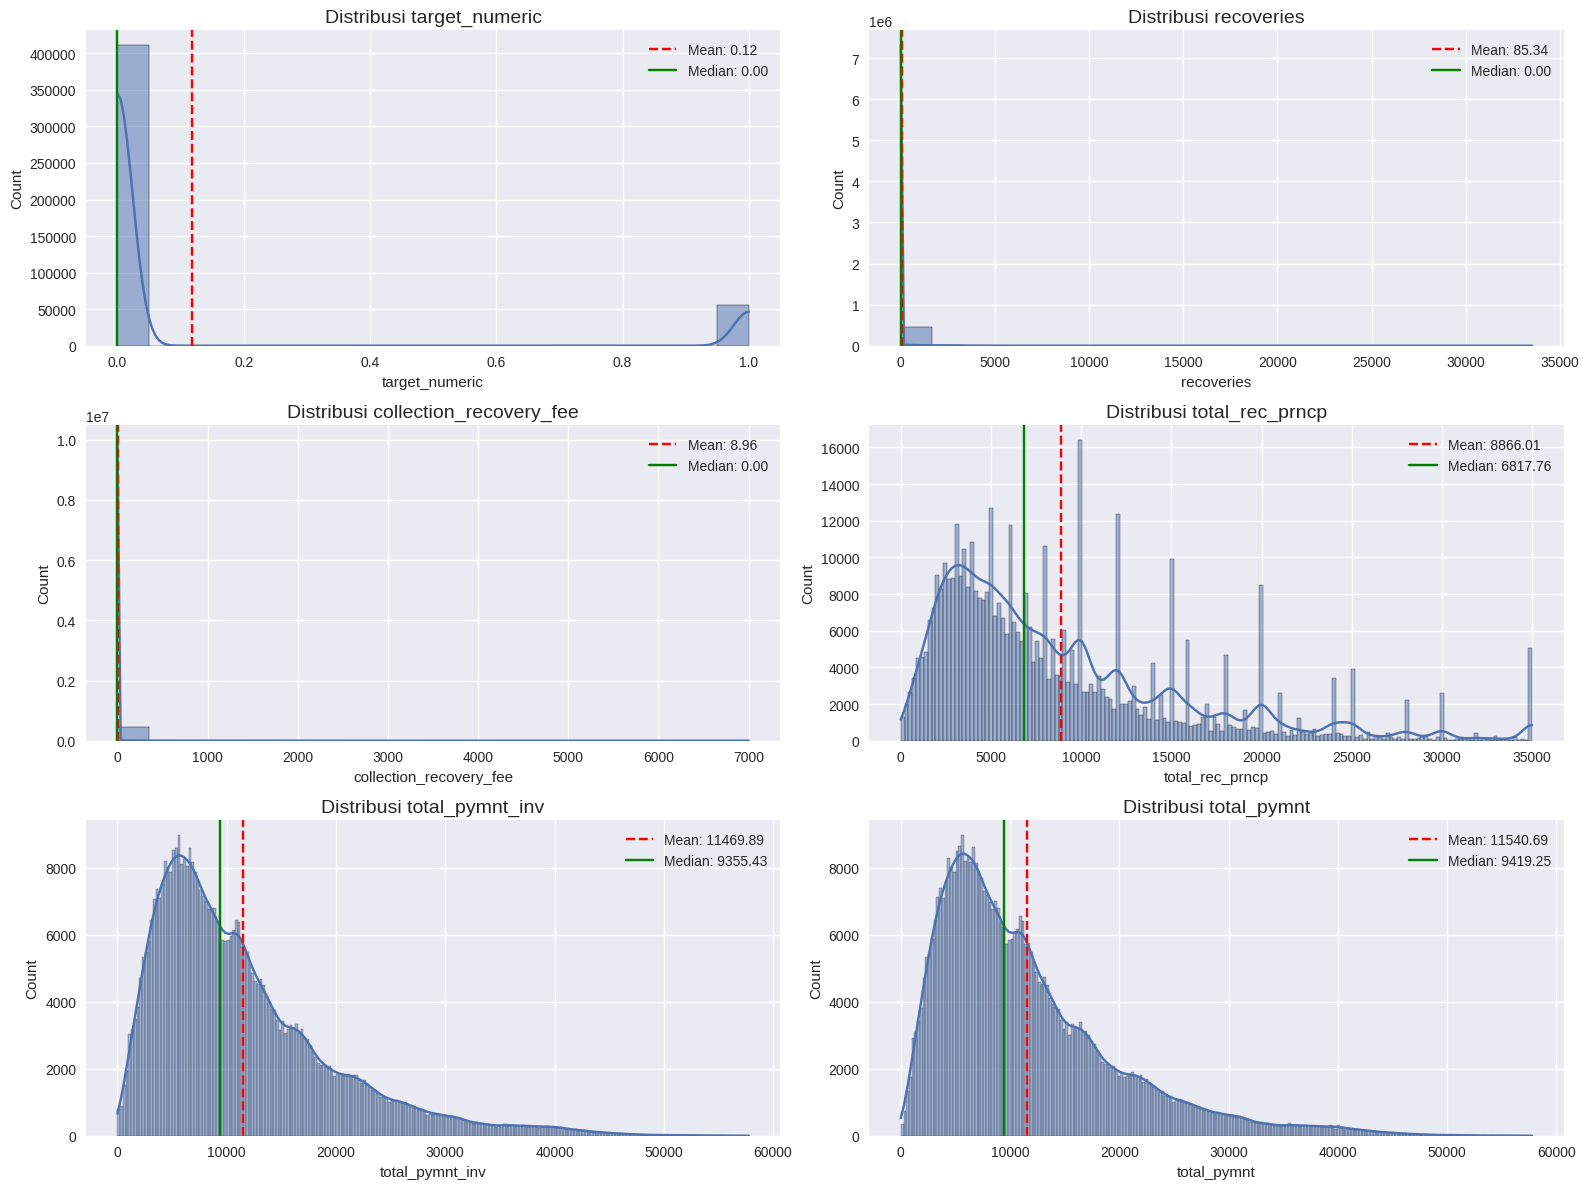

In [64]:
# Analisis Univariat untuk Variabel Numerik Utama
# Pilih 6 fitur numerik teratas berdasarkan korelasi dengan target
top_numeric_features = target_corr_df['Fitur'].head(6).tolist()

# Buat grid 3x2 untuk distribusi 6 fitur teratas
plt.figure(figsize=(16, 12))
for i, feature in enumerate(top_numeric_features):
    plt.subplot(3, 2, i+1)

    # Histogram dengan KDE
    sns.histplot(data=df, x=feature, kde=True)

    # Tambahkan statistik dasar
    plt.axvline(df[feature].mean(), color='red', linestyle='--', label=f'Mean: {df[feature].mean():.2f}')
    plt.axvline(df[feature].median(), color='green', linestyle='-', label=f'Median: {df[feature].median():.2f}')

    plt.title(f'Distribusi {feature}', fontsize=14)
    plt.legend()

plt.tight_layout()
plt.show()

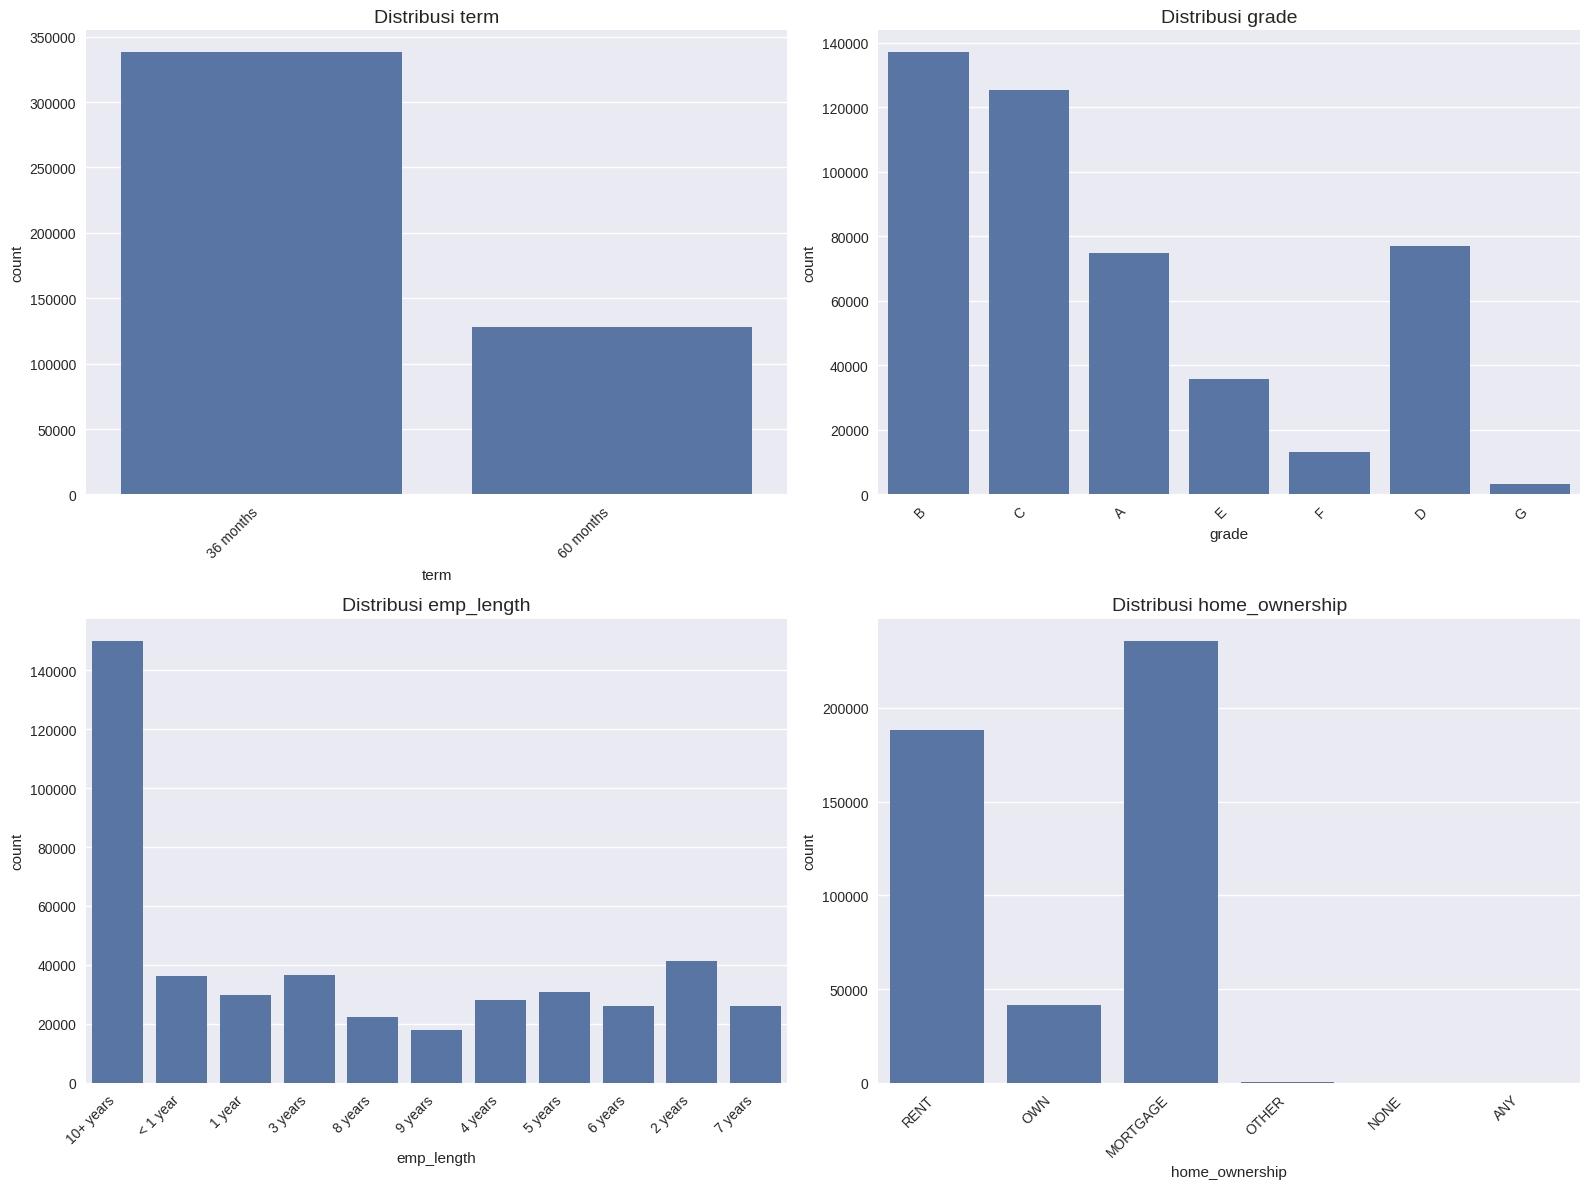

In [65]:
# Analisis Univariat untuk Variabel Kategorikal Utama
# Pilih variabel kategorikal penting
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
categorical_cols = [col for col in categorical_cols if col not in ['loan_status', 'loan_status_simple', 'id', 'member_id', 'url', 'desc', 'title']]

# Pilih maksimal 4 kolom kategorikal dengan jumlah kategori < 15
important_cat_cols = []
for col in categorical_cols:
    if df[col].nunique() < 15:
        important_cat_cols.append(col)
        if len(important_cat_cols) == 4:
            break

# Buat grid untuk distribusi variabel kategorikal
plt.figure(figsize=(16, 12))
for i, feature in enumerate(important_cat_cols):
    if i < 4:  # Maksimal 4 plot
        plt.subplot(2, 2, i+1)

        # Count plot
        sns.countplot(x=feature, data=df)

        plt.title(f'Distribusi {feature}', fontsize=14)
        plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

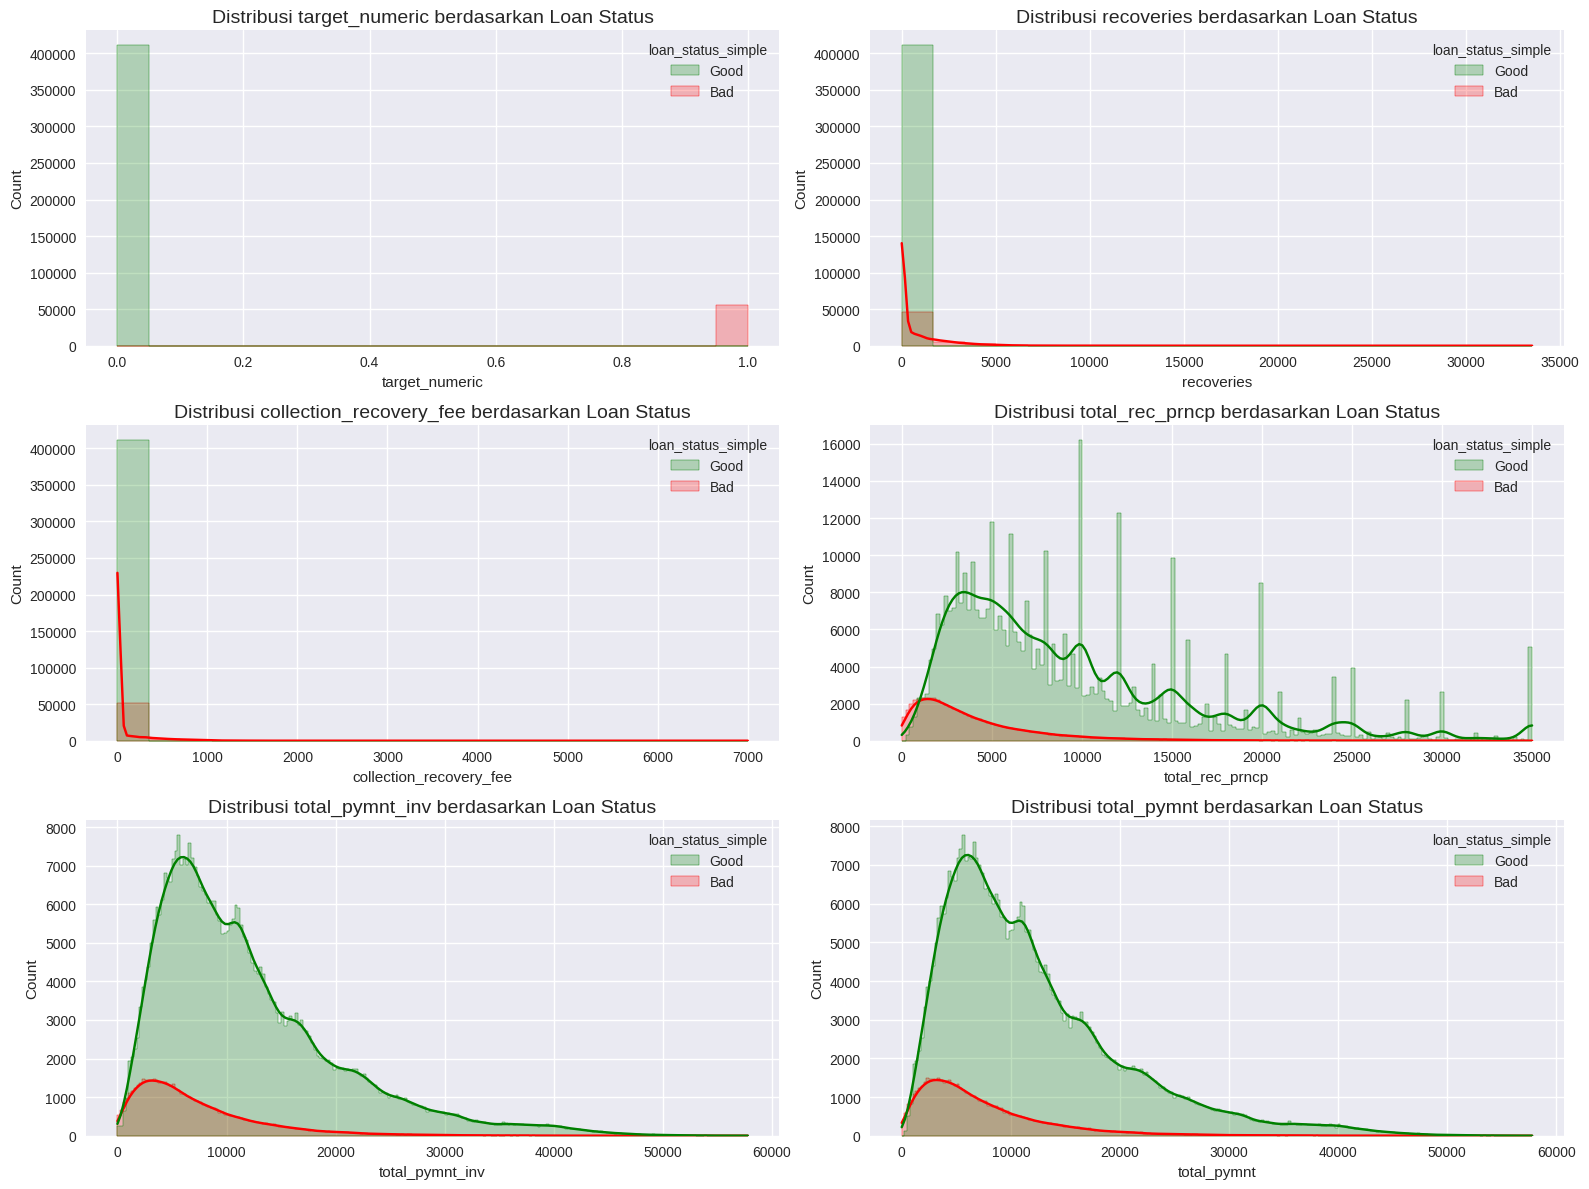

In [66]:
# 3Analisis Bivariat: Histogram Numerik berdasarkan Target
plt.figure(figsize=(16, 12))
for i, feature in enumerate(top_numeric_features):
    plt.subplot(3, 2, i+1)

    # Histogram berdasarkan target
    sns.histplot(data=df, x=feature, hue='loan_status_simple', kde=True,
                element='step', palette=['green', 'red'])

    plt.title(f'Distribusi {feature} berdasarkan Loan Status', fontsize=14)

plt.tight_layout()
plt.show()

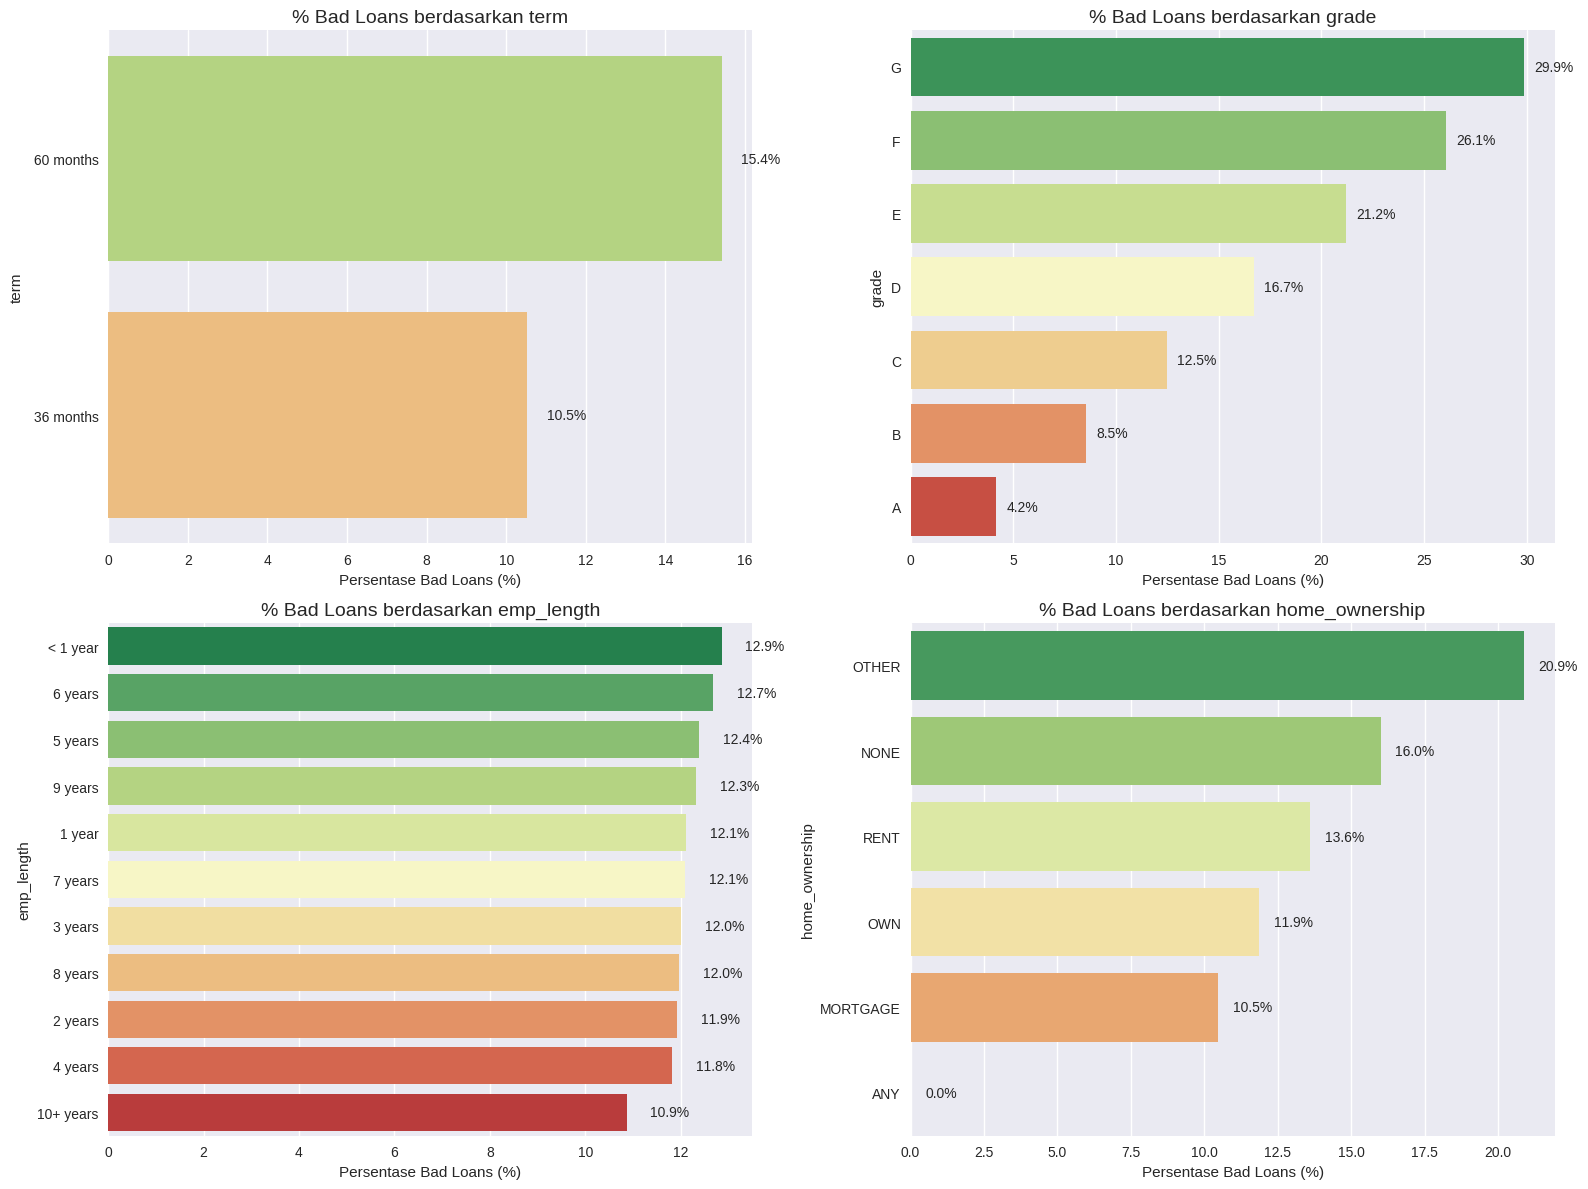

In [67]:
# Analisis Bivariat: Kategorikal vs Target
if len(important_cat_cols) > 0:
    plt.figure(figsize=(16, 12))
    for i, feature in enumerate(important_cat_cols):
        if i < 4:  # Maksimal 4 plot
            plt.subplot(2, 2, i+1)

            # Persentase bad loans per kategori
            crosstab = pd.crosstab(df[feature], df['loan_status_simple'], normalize='index') * 100

            if 'Bad' in crosstab.columns:
                # Urutkan berdasarkan persentase bad loans
                crosstab = crosstab.sort_values('Bad', ascending=False)

                # Plot
                sns.barplot(x=crosstab['Bad'], y=crosstab.index, palette='RdYlGn_r')
                plt.title(f'% Bad Loans berdasarkan {feature}', fontsize=14)
                plt.xlabel('Persentase Bad Loans (%)')

                # Tambahkan label nilai
                for j, v in enumerate(crosstab['Bad']):
                    plt.text(v + 0.5, j, f"{v:.1f}%", va='center')

    plt.tight_layout()
    plt.show()

Analisis Clustering untuk Segmentasi Peminjam

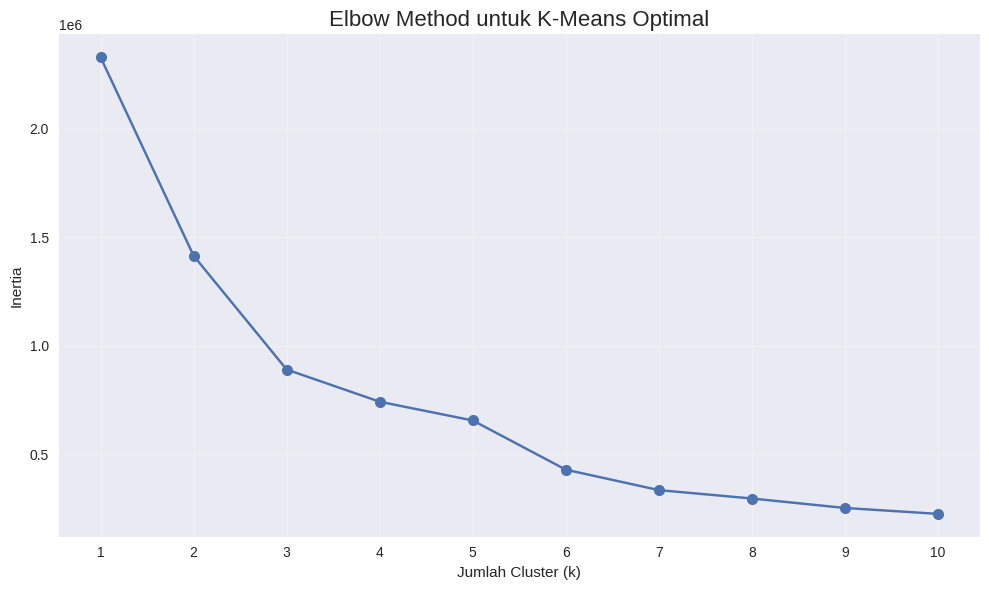

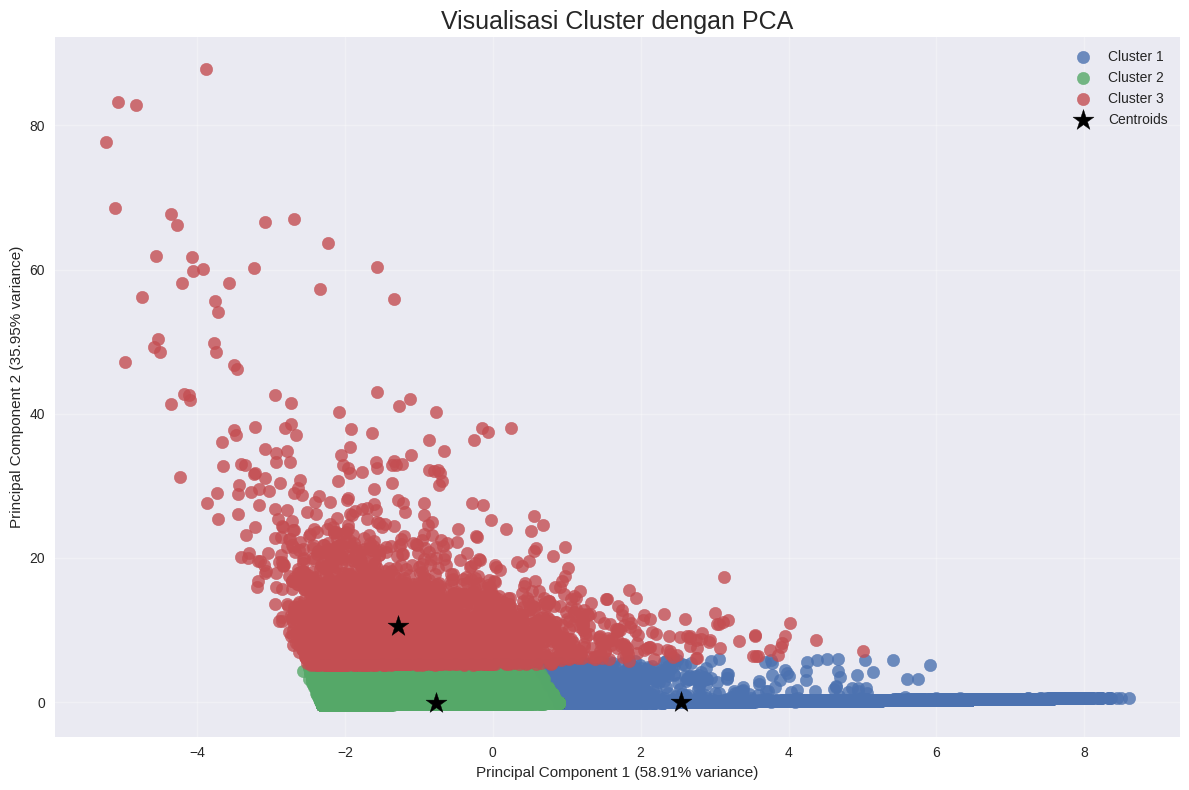


PROFIL CLUSTER:


,cluster,recoveries,collection_recovery_fee,total_rec_prncp,total_pymnt_inv,total_pymnt,Default Rate
0,0,8.985253,0.506661,19215.729665,23548.153427,23661.762582,2.652481
1,1,55.016166,2.931861,5759.937607,7767.054107,7823.874416,13.519625
2,2,4130.352994,657.979191,3922.689915,11573.532894,11708.471175,100.000000


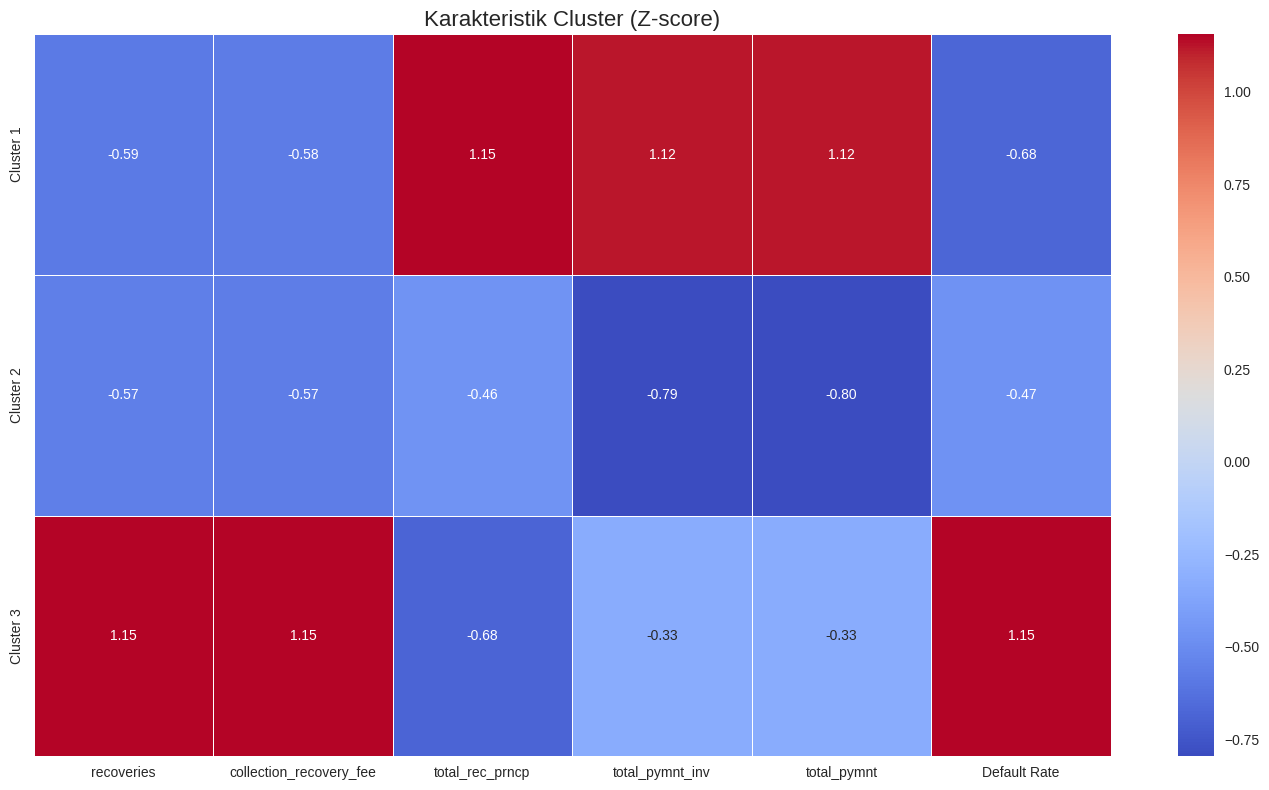

<Figure size 1200x600 with 0 Axes>

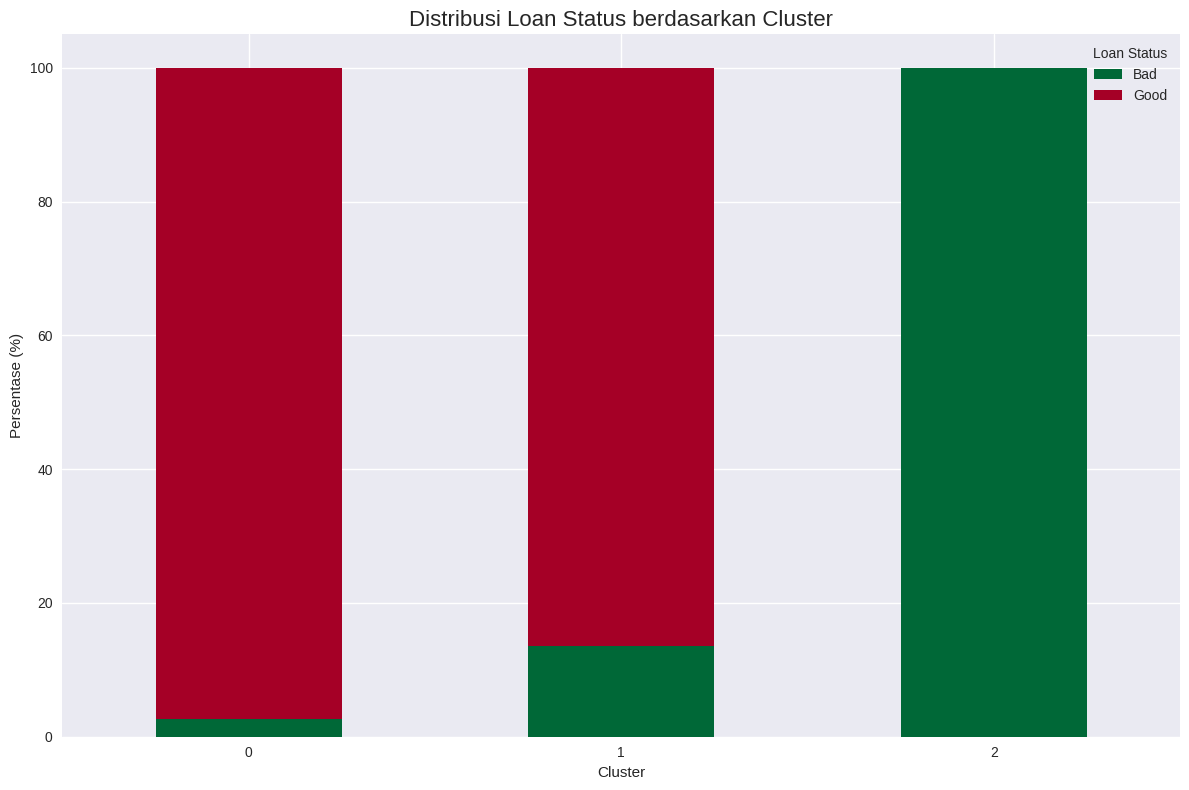

In [71]:
# Import library untuk clustering
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# 1. Analisis K-Means Clustering
# Pilih subset fitur numerik untuk clustering (tidak termasuk target)
# Asumsi 'target_numeric' adalah kolom target
cluster_features_for_kmeans = [col for col in top_numeric_features[:6] if col != 'target_numeric'] # Pilih 6 fitur teratas KECUALI target itu sendiri

# Pastikan ada fitur yang tersisa untuk clustering
if not cluster_features_for_kmeans:
    print("Error: No numeric features selected for clustering after excluding target.")
else:
    # Preprocessing
    # Tangani missing values jika ada
    # Imputasi sebelum scaling
    cluster_df = df[cluster_features_for_kmeans].copy()
    # Imputasi sederhana (misal: mean) jika ada missing values
    for col in cluster_features_for_kmeans:
         if cluster_df[col].isnull().any():
             cluster_df[col].fillna(cluster_df[col].mean(), inplace=True)


    # Standardisasi data
    scaler = StandardScaler()
    scaled_data = scaler.fit_transform(cluster_df)

    # Tentukan jumlah optimal cluster dengan Elbow Method
    inertia = []
    # Batasi range k jika dataset besar untuk performa
    max_k = min(11, scaled_data.shape[0])
    for k in range(1, max_k):
        # n_init='auto' is recommended in recent scikit-learn versions
        kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto')
        kmeans.fit(scaled_data)
        inertia.append(kmeans.inertia_)

    # Plot Elbow Method
    plt.figure(figsize=(10, 6))
    plt.plot(range(1, max_k), inertia, 'o-', markersize=8)
    plt.title('Elbow Method untuk K-Means Optimal', fontsize=16)
    plt.xlabel('Jumlah Cluster (k)')
    plt.ylabel('Inertia')
    plt.xticks(range(1, max_k))
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    # Tentukan jumlah cluster optimal (misalnya k=3 berdasarkan Elbow Method atau analisis bisnis)
    # Sesuaikan optimal_k setelah melihat plot Elbow Method
    optimal_k = 3

    # Latih model K-Means dengan jumlah cluster optimal
    # n_init='auto' is recommended
    kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init='auto')
    cluster_labels = kmeans.fit_predict(scaled_data)

    # Tambahkan hasil cluster ke dataframe
    df['cluster'] = cluster_labels

    # Visualisasi hasil clustering dengan PCA
    pca = PCA(n_components=2)
    pca_result = pca.fit_transform(scaled_data)

    # Buat plot
    plt.figure(figsize=(12, 8))
    for cluster_num in range(optimal_k):
        plt.scatter(
            pca_result[cluster_labels == cluster_num, 0],
            pca_result[cluster_labels == cluster_num, 1],
            s=80, alpha=0.8,
            label=f'Cluster {cluster_num+1}'
        )

    # Tambahkan centroid
    centroid_pca = pca.transform(kmeans.cluster_centers_)
    plt.scatter(
        centroid_pca[:, 0],
        centroid_pca[:, 1],
        s=250, marker='*', c='black',
        label='Centroids'
    )

    plt.title('Visualisasi Cluster dengan PCA', fontsize=18)
    plt.xlabel(f'Principal Component 1 ({pca.explained_variance_ratio_[0]:.2%} variance)')
    plt.ylabel(f'Principal Component 2 ({pca.explained_variance_ratio_[1]:.2%} variance)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    # 2. Analisis karakteristik cluster
    # Analisis profil cluster
    # Hitung mean dari fitur clustering DAN mean dari target_numeric
    agg_dict = {feature: 'mean' for feature in cluster_features_for_kmeans}
    agg_dict['target_numeric'] = 'mean'

    cluster_stats = df.groupby('cluster').agg(agg_dict).reset_index()

    # Rename kolom target untuk kejelasan
    cluster_stats = cluster_stats.rename(columns={'target_numeric': 'Default Rate'})
    cluster_stats['Default Rate'] = cluster_stats['Default Rate'] * 100

    print("\nPROFIL CLUSTER:")
    display(cluster_stats)

    # Visualisasi profil cluster
    plt.figure(figsize=(14, 8))
    # List fitur untuk visualisasi heatmap: fitur clustering + 'Default Rate'
    # Pastikan fitur clustering yang digunakan di sini sama dengan yang digunakan untuk agregasi
    profil_features_list = cluster_features_for_kmeans + ['Default Rate']


    # Pilih hanya kolom yang ada di cluster_stats
    # Ini adalah perbaikan utama: Pastikan kolom yang diambil memang ada setelah agregasi
    profil_features = cluster_stats[profil_features_list]


    # Standardisasi untuk visualisasi
    # Gunakan metode z-score standar jika kolom memiliki std > 0
    profil_scaled = profil_features.copy()
    for col in profil_features.columns:
        if profil_features[col].std() > 0:
            profil_scaled[col] = (profil_features[col] - profil_features[col].mean()) / profil_features[col].std()
        else:
             # Handle cases where standard deviation is 0 (all values are the same)
             profil_scaled[col] = 0 # Or keep the original value if scaling isn't meaningful


    # Plot heatmap
    sns.heatmap(profil_scaled, annot=True, cmap='coolwarm', fmt='.2f',
                linewidths=0.5, yticklabels=[f'Cluster {i+1}' for i in range(optimal_k)])
    plt.title('Karakteristik Cluster (Z-score)', fontsize=16)
    plt.tight_layout()
    plt.show()

    # Visualisasi distribusi loan status per cluster
    plt.figure(figsize=(12, 6))
    loan_status_per_cluster = pd.crosstab(df['cluster'], df['loan_status_simple'], normalize='index') * 100

    loan_status_per_cluster.plot(kind='bar', stacked=True,
                                colormap='RdYlGn_r')
    plt.title('Distribusi Loan Status berdasarkan Cluster', fontsize=16)
    plt.xlabel('Cluster')
    plt.ylabel('Persentase (%)')
    plt.xticks(rotation=0)
    plt.legend(title='Loan Status')
    plt.tight_layout()
    plt.show()

# Data Preparation

Import Library yang dibutuhkan

In [72]:
# Import library yang diperlukan
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder, LabelEncoder
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

Menangani nilai yang hilang  baik dengan menghapusnya atau mengisi dengan teknik imputasi yang sesuai.


In [74]:
# Analisis nilai yang hilang
print("ANALISIS NILAI YANG HILANG:")
missing_values = df.isnull().sum()
missing_percent = (missing_values / len(df)) * 100
missing_df = pd.DataFrame({
    'Jumlah Missing': missing_values,
    'Persentase (%)': missing_percent
}).sort_values('Persentase (%)', ascending=False)

# Tampilkan kolom dengan nilai yang hilang
missing_with_values = missing_df[missing_df['Jumlah Missing'] > 0]
if not missing_with_values.empty:
    print("Kolom dengan nilai yang hilang:")
    display(missing_with_values.head(20))  # Tampilkan 20 teratas
else:
    print("Tidak ada nilai yang hilang dalam dataset.")

# Visualisasi missing values untuk kolom dengan missing value > 1%
high_missing_cols = missing_df[missing_df['Persentase (%)'] > 1].index.tolist()
if high_missing_cols:
    plt.figure(figsize=(12, 6))
    sns.barplot(x=missing_df.loc[high_missing_cols, 'Persentase (%)'],
                y=high_missing_cols)
    plt.title('Persentase Missing Value (> 1%)')
    plt.xlabel('Persentase Missing (%)')
    plt.tight_layout()
    plt.show()

# Strategi penanganan missing values
# 1. Hapus kolom dengan missing value yang sangat tinggi (>70%)
print("\nSTRATEGI PENANGANAN MISSING VALUES:")
very_high_missing = missing_df[missing_df['Persentase (%)'] > 70].index.tolist()
if very_high_missing:
    print(f"Menghapus kolom dengan missing value >70%: {very_high_missing}")
    df = df.drop(columns=very_high_missing)
    print(f"Jumlah kolom yang tersisa: {df.shape[1]}")

# 2. Identifikasi kategori missing values untuk strategi yang tepat
# Kolom numerik dan kategorikal
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()

# Pisahkan kolom numerik dengan missing values
numeric_with_missing = [col for col in numeric_cols if df[col].isnull().sum() > 0]
print(f"\nKolom numerik dengan missing values: {len(numeric_with_missing)}")

# Pisahkan kolom kategorikal dengan missing values
categorical_with_missing = [col for col in categorical_cols if df[col].isnull().sum() > 0]
print(f"Kolom kategorikal dengan missing values: {len(categorical_with_missing)}")

# 3. Tangani missing values untuk kolom numerik
print("\nIMPUTASI NILAI YANG HILANG UNTUK KOLOM NUMERIK:")
if numeric_with_missing:
    # Strategi untuk kolom dengan missing values <20%: Mean/Median imputation
    mean_impute_cols = [col for col in numeric_with_missing
                       if missing_df.loc[col, 'Persentase (%)'] < 20]

    # Strategi untuk kolom dengan missing values 20-50%: KNN imputation
    knn_impute_cols = [col for col in numeric_with_missing
                      if 20 <= missing_df.loc[col, 'Persentase (%)'] < 50]

    # Strategi untuk kolom dengan missing values 50-70%: Nilai khusus (-999)
    special_impute_cols = [col for col in numeric_with_missing
                          if 50 <= missing_df.loc[col, 'Persentase (%)'] <= 70]

    # Apply mean/median imputation
    if mean_impute_cols:
        print(f"Kolom untuk mean/median imputation: {mean_impute_cols}")
        for col in mean_impute_cols:
            # Gunakan median untuk kolom dengan skewness tinggi (>1)
            if abs(df[col].skew()) > 1:
                median_value = df[col].median()
                df[col].fillna(median_value, inplace=True)
                print(f"  - {col}: Imputed with median ({median_value:.2f}) karena skewed")
            else:
                mean_value = df[col].mean()
                df[col].fillna(mean_value, inplace=True)
                print(f"  - {col}: Imputed with mean ({mean_value:.2f})")

    # Apply KNN imputation untuk kolom dengan missing values 20-50%
    if knn_impute_cols:
        print(f"\nKolom untuk KNN imputation: {knn_impute_cols}")
        # Pilih subset fitur tanpa missing values untuk KNN
        imputation_features = [col for col in numeric_cols
                               if df[col].isnull().sum() == 0][:5]  # Ambil max 5 fitur

        if imputation_features:
            # Scale features untuk KNN imputation
            scaler = StandardScaler()
            df_impute = pd.DataFrame(
                scaler.fit_transform(df[imputation_features]),
                columns=imputation_features
            )

            # Tambahkan kolom yang akan diimputasi
            for col in knn_impute_cols:
                df_impute[col] = df[col]

            # Apply KNN imputation
            imputer = KNNImputer(n_neighbors=5)
            imputed_array = imputer.fit_transform(df_impute)

            # Update nilai yang diimputasi di dataframe asli
            for i, col in enumerate(knn_impute_cols):
                col_idx = len(imputation_features) + i
                df[col] = imputed_array[:, col_idx]

                # Hitung persentase nilai yang diimputasi
                missing_count = missing_df.loc[col, 'Jumlah Missing']
                missing_pct = missing_df.loc[col, 'Persentase (%)']
                print(f"  - {col}: KNN imputation untuk {missing_count} nilai ({missing_pct:.2f}%)")
        else:
            # Jika tidak ada fitur tanpa missing value, gunakan mean/median imputation
            print("  Tidak cukup fitur tanpa missing value untuk KNN. Menggunakan mean imputation.")
            for col in knn_impute_cols:
                mean_value = df[col].mean()
                df[col].fillna(mean_value, inplace=True)
                print(f"  - {col}: Imputed with mean ({mean_value:.2f})")

    # Apply special value imputation untuk kolom dengan missing values 50-70%
    if special_impute_cols:
        print(f"\nKolom untuk special value imputation: {special_impute_cols}")
        for col in special_impute_cols:
            # Buat kolom flag untuk menandai nilai yang diimputasi
            df[f"{col}_missing_flag"] = df[col].isnull().astype(int)

            # Imputasi dengan nilai -999 (atau nilai ekstrim lain)
            df[col].fillna(-999, inplace=True)
            print(f"  - {col}: Imputed with -999 dan flag column ditambahkan")
else:
    print("Tidak ada kolom numerik dengan missing values.")

# 4. Tangani missing values untuk kolom kategorikal
print("\nIMPUTASI NILAI YANG HILANG UNTUK KOLOM KATEGORIKAL:")
if categorical_with_missing:
    for col in categorical_with_missing:
        missing_pct = missing_df.loc[col, 'Persentase (%)']

        # Strategi berdasarkan persentase missing
        if missing_pct < 20:
            # Imputasi dengan modus (nilai terbanyak)
            mode_value = df[col].mode()[0]
            df[col].fillna(mode_value, inplace=True)
            print(f"  - {col}: Imputed with mode '{mode_value}' ({missing_pct:.2f}% missing)")
        elif missing_pct < 50:
            # Imputasi dengan kategori "Unknown"
            df[col].fillna("Unknown", inplace=True)
            print(f"  - {col}: Imputed with 'Unknown' ({missing_pct:.2f}% missing)")
        else:
            # Untuk missing values tinggi (50-70%), hapus kolom jika tidak terlalu penting
            # Jika kolom penting, tambahkan flag dan imputasi dengan "Unknown"
            if col in ['emp_title', 'desc', 'title', 'zip_code']:  # Kolom yang tidak terlalu penting
                df = df.drop(columns=[col])
                print(f"  - {col}: Kolom dihapus karena missing values tinggi ({missing_pct:.2f}%)")
            else:
                df[f"{col}_missing_flag"] = df[col].isnull().astype(int)
                df[col].fillna("Unknown", inplace=True)
                print(f"  - {col}: Imputed with 'Unknown' dan flag column ditambahkan ({missing_pct:.2f}% missing)")
else:
    print("Tidak ada kolom kategorikal dengan missing values.")

# Verifikasi hasil imputasi
print("\nVERIFIKASI HASIL IMPUTASI:")
missing_after = df.isnull().sum().sum()
print(f"Jumlah nilai yang hilang sebelum imputasi: {missing_values.sum()}")
print(f"Jumlah nilai yang hilang setelah imputasi: {missing_after}")
if missing_after == 0:
    print("Semua nilai yang hilang telah ditangani dengan sukses.")
else:
    print(f"Masih terdapat {missing_after} nilai yang hilang. Perlu penanganan lebih lanjut.")

ANALISIS NILAI YANG HILANG:
Tidak ada nilai yang hilang dalam dataset.

STRATEGI PENANGANAN MISSING VALUES:

Kolom numerik dengan missing values: 0
Kolom kategorikal dengan missing values: 0

IMPUTASI NILAI YANG HILANG UNTUK KOLOM NUMERIK:
Tidak ada kolom numerik dengan missing values.

IMPUTASI NILAI YANG HILANG UNTUK KOLOM KATEGORIKAL:
Tidak ada kolom kategorikal dengan missing values.

VERIFIKASI HASIL IMPUTASI:
Jumlah nilai yang hilang sebelum imputasi: 0
Jumlah nilai yang hilang setelah imputasi: 0
Semua nilai yang hilang telah ditangani dengan sukses.


**Analisis Missing Values** - Mengidentifikasi persentase dan pola nilai yang hilang untuk memahami keluasan masalah.
**Strategi Berbasis Persentase**:
- 70% missing: Kolom dihapus karena terlalu banyak nilai yang hilang menyebabkan imputasi menjadi tidak handal.
- 50-70% missing: Untuk numerik, diterapkan nilai khusus (-999) dengan flag kolom tambahan. Untuk kategorikal, dievaluasi kepentingan kolom.
- 20-50% missing: Untuk numerik, digunakan KNN imputation. Untuk kategorikal, diganti dengan "Unknown".
- 20% missing: Untuk numerik, digunakan mean (untuk distribusi normal) atau median (untuk data miring). Untuk kategorikal, digunakan modus.

**Mempertahankan Informasi Missing** - Untuk kolom dengan missing value tinggi tapi penting, flag kolom ditambahkan untuk mempertahankan informasi bahwa nilai tersebut awalnya hilang.

Alasan:
- KNN Imputation dipilih untuk missing value menengah karena memperhitungkan hubungan antar variabel.
- Mean vs Median - Median digunakan untuk data dengan skewness tinggi agar tidak terpengaruh outlier.
- Special Value (-999) - Untuk missing value tinggi, nilai ini memungkinkan - model mengenali pola khusus pada data yang awalnya hilang.
- Mode untuk Kategorikal - Menggunakan nilai terbanyak mempertahankan distribusi data asli.

Mengatasi outlier jika diperlukan  entah dengan menghapusnya atau menyesuaikan nilainya.

ANALISIS DAN PENANGANAN OUTLIER:


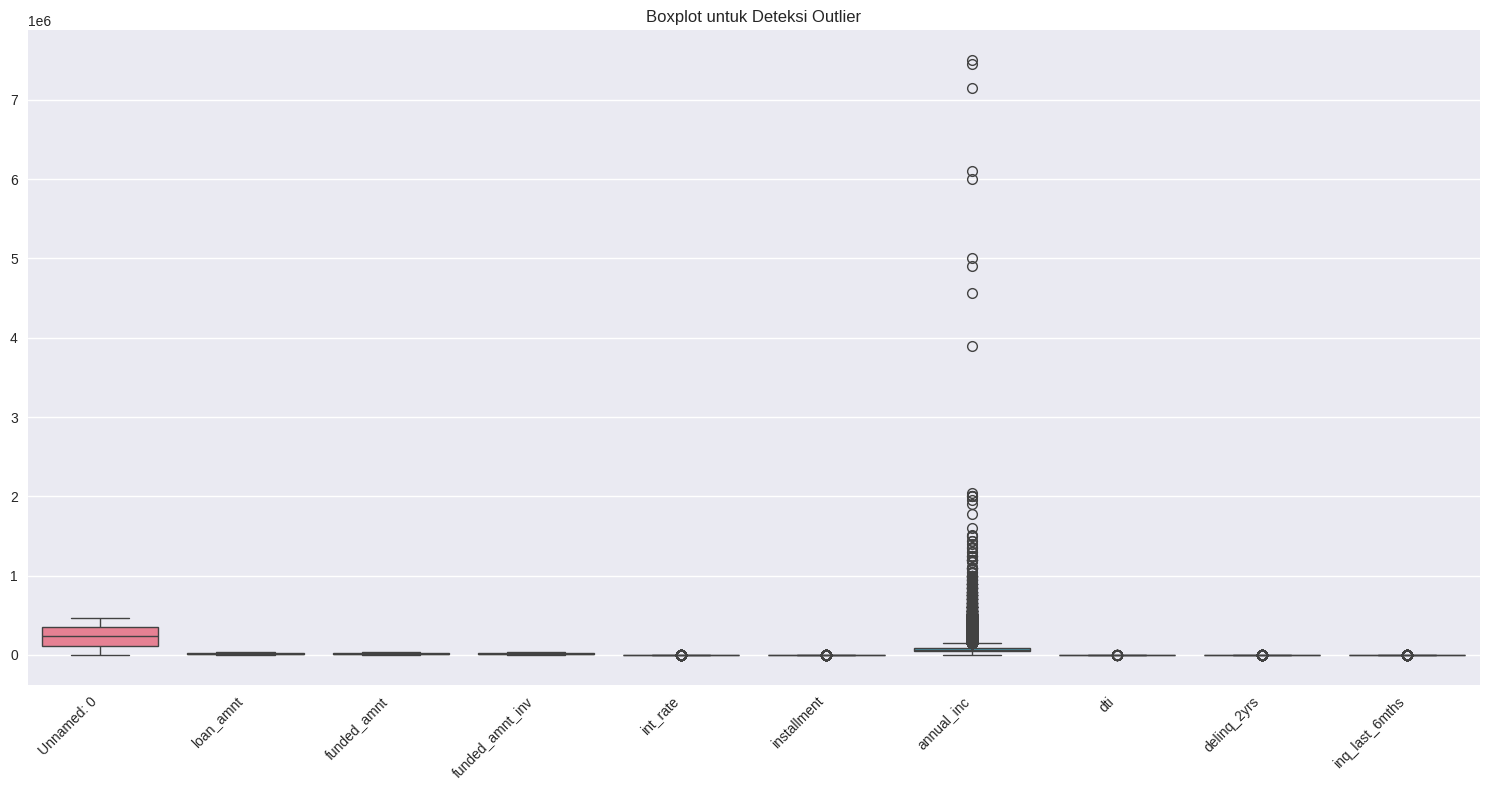


Kolom dengan outlier signifikan (>5%):
  - delinq_2yrs: 83302 outliers (17.87%)
    Batas: 0.00 - 0.00
    Range aktual: 0.00 - 29.00
  - inq_last_6mths: 36785 outliers (7.89%)
    Batas: -1.50 - 2.50
    Range aktual: 0.00 - 33.00
  - pub_rec: 61363 outliers (13.16%)
    Batas: 0.00 - 0.00
    Range aktual: 0.00 - 63.00
  - out_prncp: 23331 outliers (5.00%)
    Batas: -11012.47 - 18354.12
    Range aktual: 0.00 - 32160.38
  - out_prncp_inv: 23381 outliers (5.01%)
    Batas: -11007.59 - 18345.98
    Range aktual: 0.00 - 32160.38
  - total_rec_int: 31138 outliers (6.68%)
    Batas: -2563.60 - 6825.41
    Range aktual: 0.00 - 24205.62
  - recoveries: 24371 outliers (5.23%)
    Batas: 0.00 - 0.00
    Range aktual: 0.00 - 33520.27
  - last_pymnt_amnt: 70346 outliers (15.09%)
    Batas: -3999.72 - 7499.85
    Range aktual: 0.00 - 36234.44
  - tot_coll_amt: 49750 outliers (10.67%)
    Batas: 0.00 - 0.00
    Range aktual: 0.00 - 9152545.00
  - total_rev_hi_lim: 32950 outliers (7.07%)
    Bat

In [75]:
# Identifikasi dan tangani outlier
print("ANALISIS DAN PENANGANAN OUTLIER:")

# Hanya fokus pada kolom numerik penting (hindari kolom ID, flag, dll)
important_numeric_cols = [col for col in numeric_cols
                         if not (col.endswith('_flag') or col.startswith(('id', 'member_id')))
                         and 'amount' not in col.lower()  # Hindari kolom jumlah, karena outlier mungkin valid
                         and df[col].nunique() > 5]  # Hindari binary/few-valued columns

# Visualisasi outlier dengan boxplot (sampel 10 kolom penting saja untuk kejelasan)
sample_cols = important_numeric_cols[:min(10, len(important_numeric_cols))]
if sample_cols:
    plt.figure(figsize=(15, 8))
    sns.boxplot(data=df[sample_cols])
    plt.title('Boxplot untuk Deteksi Outlier')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

# Fungsi untuk mendeteksi outlier dengan metode IQR
def detect_outliers_iqr(df, col, lower_factor=1.5, upper_factor=1.5):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - lower_factor * IQR
    upper_bound = Q3 + upper_factor * IQR

    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)][col]
    return {
        'lower_bound': lower_bound,
        'upper_bound': upper_bound,
        'outlier_count': len(outliers),
        'outlier_percent': len(outliers) / len(df[col].dropna()) * 100
    }

# Analisis outlier untuk fitur numerik penting
outlier_analysis = {}
for col in important_numeric_cols:
    outlier_analysis[col] = detect_outliers_iqr(df, col)

# Tampilkan hasil analisis outlier (hanya yang memiliki >5% outlier)
significant_outliers = {col: info for col, info in outlier_analysis.items()
                       if info['outlier_percent'] > 5}

if significant_outliers:
    print("\nKolom dengan outlier signifikan (>5%):")
    for col, info in significant_outliers.items():
        print(f"  - {col}: {info['outlier_count']} outliers ({info['outlier_percent']:.2f}%)")
        print(f"    Batas: {info['lower_bound']:.2f} - {info['upper_bound']:.2f}")
        print(f"    Range aktual: {df[col].min():.2f} - {df[col].max():.2f}")

# Strategi penanganan outlier
print("\nSTRATEGI PENANGANAN OUTLIER:")
# 1. Winsorizing (capping) untuk outlier moderat (5-20%)
winsorize_cols = {col: info for col, info in significant_outliers.items()
                 if 5 < info['outlier_percent'] <= 20}

if winsorize_cols:
    print("Kolom untuk winsorizing (capping pada 5% dan 95%):")
    for col, info in winsorize_cols.items():
        lower_bound = df[col].quantile(0.05)
        upper_bound = df[col].quantile(0.95)

        # Simpan data asli untuk verifikasi
        original_mean = df[col].mean()
        original_std = df[col].std()

        # Apply winsorizing
        df[col] = df[col].clip(lower=lower_bound, upper=upper_bound)

        # Verifikasi hasil
        new_mean = df[col].mean()
        new_std = df[col].std()

        print(f"  - {col}: Capped at {lower_bound:.2f} - {upper_bound:.2f}")
        print(f"    Efek: Mean {original_mean:.2f} → {new_mean:.2f}, Std {original_std:.2f} → {new_std:.2f}")

# 2. Log transformation untuk kolom dengan distribusi sangat miring dan outlier ekstrem (>20%)
transform_cols = {col: info for col, info in significant_outliers.items()
                 if info['outlier_percent'] > 20 and df[col].min() > 0}

if transform_cols:
    print("\nKolom untuk transformasi logaritmik:")
    for col, info in transform_cols.items():
        # Simpan data asli untuk verifikasi
        original_skew = df[col].skew()

        # Apply log transformation (log1p untuk menangani nilai 0)
        df[f"{col}_log"] = np.log1p(df[col])

        # Verifikasi hasil
        new_skew = df[f"{col}_log"].skew()

        print(f"  - {col}: Log-transformed → {col}_log")
        print(f"    Efek: Skewness {original_skew:.2f} → {new_skew:.2f}")

        # Tetap pertahankan kolom asli untuk interpretabilitas, tetapi flag untuk modeling
        # Kita akan memilih mana yang akan digunakan dalam tahap seleksi fitur

# 3. Untuk outlier ekstrem pada kolom kritis (misalnya target-related), evaluasi apakah perlu dihapus
# Ini harus dilakukan dengan hati-hati untuk menghindari bias
extreme_outlier_cols = {col: info for col, info in significant_outliers.items()
                       if info['outlier_percent'] > 30 and col not in transform_cols}

if extreme_outlier_cols:
    print("\nKolom dengan outlier ekstrem (>30%):")
    for col, info in extreme_outlier_cols.items():
        print(f"  - {col}: {info['outlier_count']} outliers ({info['outlier_percent']:.2f}%)")
        print("    Rekomendasi: Evaluasi apakah outlier ini valid atau error")
        # Untuk kasus ini, kita tidak langsung menghapus, tetapi memberikan rekomendasi untuk evaluasi manual

# 4. Visualisasi efek transformasi untuk beberapa kolom contoh (jika ada)
if transform_cols:
    sample_transform = list(transform_cols.keys())[:min(3, len(transform_cols))]

    for col in sample_transform:
        plt.figure(figsize=(14, 5))

        # Histogram original
        plt.subplot(1, 2, 1)
        sns.histplot(df[col], kde=True)
        plt.title(f'Original: {col}')

        # Histogram transformed
        plt.subplot(1, 2, 2)
        sns.histplot(df[f"{col}_log"], kde=True)
        plt.title(f'Log-transformed: {col}_log')

        plt.tight_layout()
        plt.show()

1. Identifikasi Outlier dengan Metode IQR - Menggunakan range antar kuartil untuk mendeteksi nilai yang berada di luar 1.5*IQR dari Q1 dan Q3.
2. Strategi Berbasis Tingkat Keparahan:
- Outlier Moderat (5-20%): Ditangani dengan winsorizing (capping) pada persentil 5 dan 95.
- Outlier Signifikan (>20%): Ditangani dengan transformasi logaritmik untuk mengurangi skewness.
- Outlier Ekstrem (>30%): Diberi flag untuk evaluasi manual, karena penghapusan data dalam jumlah besar bisa menyebabkan bias.
3. Evaluasi Dampak Transformasi - Setiap perubahan diverifikasi dengan membandingkan statistik sebelum dan sesudah (mean, std, skewness).

Alasan :
- Diferensiasi Strategi - Tidak semua outlier sama: beberapa mungkin kesalahan data, sementara yang lain mungkin nilai valid tetapi ekstrem.
- Winsorizing vs Transformasi - Winsorizing mempertahankan interpretabilitas tetapi menghilangkan nilai ekstrem, sementara transformasi mempertahankan urutan data tetapi mengubah skalanya.
- Mempertahankan Kolom Asli dan Transformed - Memberikan fleksibilitas untuk pemilihan fitur di tahap selanjutnya.
- Fokus Selektif - Hanya menangani kolom numerik penting untuk efisiensi dan menghindari modifikasi data yang tidak perlu.

Melakukan encoding pada variabel kategorikal jika diperlukan.


In [76]:
# Encoding variabel kategorikal
print("ENCODING VARIABEL KATEGORIKAL:")

# Dapatkan daftar kolom kategorikal (setelah handling missing values)
categorical_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()

# Hapus kolom yang tidak perlu diencoding (ID, URL, deskripsi panjang)
exclude_cols = ['id', 'member_id', 'url', 'desc', 'title']
categorical_cols = [col for col in categorical_cols if col not in exclude_cols]

# Identifikasi kolom kategorikal berdasarkan kardinalitas (jumlah kategori unik)
if categorical_cols:
    print(f"Total kolom kategorikal untuk encoding: {len(categorical_cols)}")

    # Kelompokkan berdasarkan kardinalitas
    high_cardinality = []  # >10 kategori
    medium_cardinality = [] # 3-10 kategori
    binary_cols = []  # 2 kategori

    for col in categorical_cols:
        n_unique = df[col].nunique()
        if n_unique > 10:
            high_cardinality.append((col, n_unique))
        elif n_unique > 2:
            medium_cardinality.append((col, n_unique))
        else:
            binary_cols.append((col, n_unique))

    # 1. Binary encoding dengan Label Encoder
    print("\n1. LABEL ENCODING UNTUK KOLOM BINER:")
    if binary_cols:
        for col, n_unique in binary_cols:
            # Buat label encoder
            le = LabelEncoder()

            # Apply encoding
            df[col] = le.fit_transform(df[col])

            # Tampilkan mapping
            mapping = dict(zip(le.classes_, le.transform(le.classes_)))
            print(f"  - {col}: {mapping}")
    else:
        print("  Tidak ada kolom biner untuk label encoding.")

    # 2. One-Hot Encoding untuk medium cardinality
    print("\n2. ONE-HOT ENCODING UNTUK KOLOM KATEGORIKAL SEDANG (3-10 kategori):")
    if medium_cardinality:
        for col, n_unique in medium_cardinality:
            # Buat dummy variables (drop_first=True untuk menghindari multikolinearitas)
            dummies = pd.get_dummies(df[col], prefix=col, drop_first=True)

            # Drop kolom asli dan gabungkan dummies
            df = df.drop(columns=[col])
            df = pd.concat([df, dummies], axis=1)

            print(f"  - {col}: {n_unique} kategori → {dummies.shape[1]} dummy variables")
    else:
        print("  Tidak ada kolom dengan kardinalitas sedang untuk one-hot encoding.")

    # 3. Target Encoding atau Frequency Encoding untuk high cardinality
    print("\n3. FREQUENCY ENCODING UNTUK KOLOM KARDINALITAS TINGGI (>10 kategori):")
    if high_cardinality:
        for col, n_unique in high_cardinality:
            # Cek apakah kolom ini penting untuk model
            if col in ['emp_title', 'zip_code']:  # Kolom dengan nilai unik sangat tinggi dan mungkin kurang prediktif
                print(f"  - {col}: Kolom dihapus (terlalu banyak kategori: {n_unique})")
                df = df.drop(columns=[col])
            else:
                # Frequency encoding - mengganti kategori dengan frekuensinya
                freq_encode = df[col].value_counts(normalize=True).to_dict()
                df[f"{col}_freq"] = df[col].map(freq_encode)

                # Drop kolom asli
                df = df.drop(columns=[col])

                print(f"  - {col}: {n_unique} kategori → frequency encoded as {col}_freq")
    else:
        print("  Tidak ada kolom kardinalitas tinggi untuk frequency encoding.")

    # 4. Special encoding for ordinal columns
    # Jika ada kolom ordinal seperti 'grade' atau 'emp_length', tangani secara khusus
    if 'grade' in categorical_cols:
        # Ordinal encoding sesuai urutan grade A-G
        grade_order = {'A': 7, 'B': 6, 'C': 5, 'D': 4, 'E': 3, 'F': 2, 'G': 1}

        if 'grade' in df.columns:  # Pastikan kolom grade belum dihapus
            df['grade_ordinal'] = df['grade'].map(grade_order)
            print(f"\n4. ORDINAL ENCODING UNTUK GRADE: {grade_order}")
            df = df.drop(columns=['grade'])

    if 'emp_length' in categorical_cols:
        # Ekstrak angka dari string, misalnya "10+ years" → 10
        if 'emp_length' in df.columns:  # Pastikan kolom belum dihapus
            df['emp_length_years'] = df['emp_length'].str.extract('(\d+)').astype(float)
            df['emp_length_years'] = df['emp_length_years'].fillna(0)  # "< 1 year" = 0
            df = df.drop(columns=['emp_length'])
            print(f"5. SPECIAL ENCODING UNTUK EMP_LENGTH → EMP_LENGTH_YEARS")

# Verifikasi hasil encoding
print("\nVERIFIKASI HASIL ENCODING:")
categorical_after = df.select_dtypes(include=['object', 'category']).columns.tolist()
categorical_after = [col for col in categorical_after if col not in exclude_cols]

print(f"Kolom kategorikal sebelum encoding: {len(categorical_cols)}")
print(f"Kolom kategorikal setelah encoding: {len(categorical_after)}")

if categorical_after:
    print("Kolom kategorikal yang masih perlu diencoding:")
    for col in categorical_after:
        print(f"  - {col}: {df[col].nunique()} kategori unik")
else:
    print("Semua kolom kategorikal telah berhasil diencoding.")

ENCODING VARIABEL KATEGORIKAL:
Total kolom kategorikal untuk encoding: 20

1. LABEL ENCODING UNTUK KOLOM BINER:
  - term: {' 36 months': np.int64(0), ' 60 months': np.int64(1)}
  - pymnt_plan: {'n': np.int64(0), 'y': np.int64(1)}
  - initial_list_status: {'f': np.int64(0), 'w': np.int64(1)}
  - application_type: {'INDIVIDUAL': np.int64(0)}
  - loan_status_simple: {'Bad': np.int64(0), 'Good': np.int64(1)}

2. ONE-HOT ENCODING UNTUK KOLOM KATEGORIKAL SEDANG (3-10 kategori):
  - grade: 7 kategori → 6 dummy variables
  - home_ownership: 6 kategori → 5 dummy variables
  - verification_status: 3 kategori → 2 dummy variables
  - loan_status: 9 kategori → 8 dummy variables

3. FREQUENCY ENCODING UNTUK KOLOM KARDINALITAS TINGGI (>10 kategori):
  - sub_grade: 35 kategori → frequency encoded as sub_grade_freq
  - emp_title: Kolom dihapus (terlalu banyak kategori: 205475)
  - emp_length: 11 kategori → frequency encoded as emp_length_freq
  - issue_d: 91 kategori → frequency encoded as issue_d_freq

Encoding variabel kategorikal adalah proses mengubah data kategorikal menjadi format numerik yang dapat dipahami oleh algoritma machine learning. Pendekatan yang digunakan:

1. Strategi Berbasis Kardinalitas:
- Binary (2 kategori): Label Encoding - mengubah kategori menjadi 0 dan 1.
- Medium (3-10 kategori): One-Hot Encoding - membuat kolom dummy untuk setiap kategori.
- High (>10 kategori): Frequency Encoding - mengganti kategori dengan frekuensinya dalam dataset.
2. Special Treatment:
- Kolom Ordinal seperti 'grade' diencoding sesuai urutannya (A=7, B=6, dst).
- String dengan Informasi Numerik seperti 'emp_length' diekstrak menjadi nilai numerik ('10+ years' → 10).
- Kolom dengan Kardinalitas Sangat Tinggi seperti 'emp_title' atau 'zip_code' dihapus jika dianggap kurang prediktif.
3. Pengurangan Dimensi - Untuk one-hot encoding, menggunakan drop_first=True untuk menghindari multikolinearitas.

Alasan :
- Label Encoding untuk Binary - Simpel dan efisien untuk kolom dengan 2 kategori.
- One-Hot untuk Medium - Menghindari asumsi ordinal, memberi bobot yang sama untuk setiap kategori.
- Frequency Encoding untuk High - Menangani kardinalitas tinggi tanpa meningkatkan dimensi secara drastis, sekaligus mempertahankan informasi populasi.
- Perlakuan Khusus - Mempertahankan informasi ordinal/skala untuk kolom yang memang memiliki urutan intrinsik.

Melakukan scaling atau normalisasi pada fitur-fitur numerik jika diperlukan.

SCALING DAN NORMALISASI FITUR NUMERIK:
Jumlah kolom untuk scaling: 45

ANALISIS DISTRIBUSI SEBELUM SCALING:
Statistik sebelum scaling:


,mean,std,min,25%,50%,75%,max
loan_amnt,14317.277577,8286.509164,500.00,8000.00,12000.00,20000.00,35000.00
int_rate,13.829236,4.357587,5.42,10.99,13.66,16.49,26.06
installment,432.061201,243.485550,15.67,256.69,379.89,566.58,1409.99
annual_inc,73277.293307,54963.341145,1896.00,45000.00,63000.00,88953.00,7500000.00
dti,17.218758,7.851121,0.00,11.36,16.87,22.78,39.99


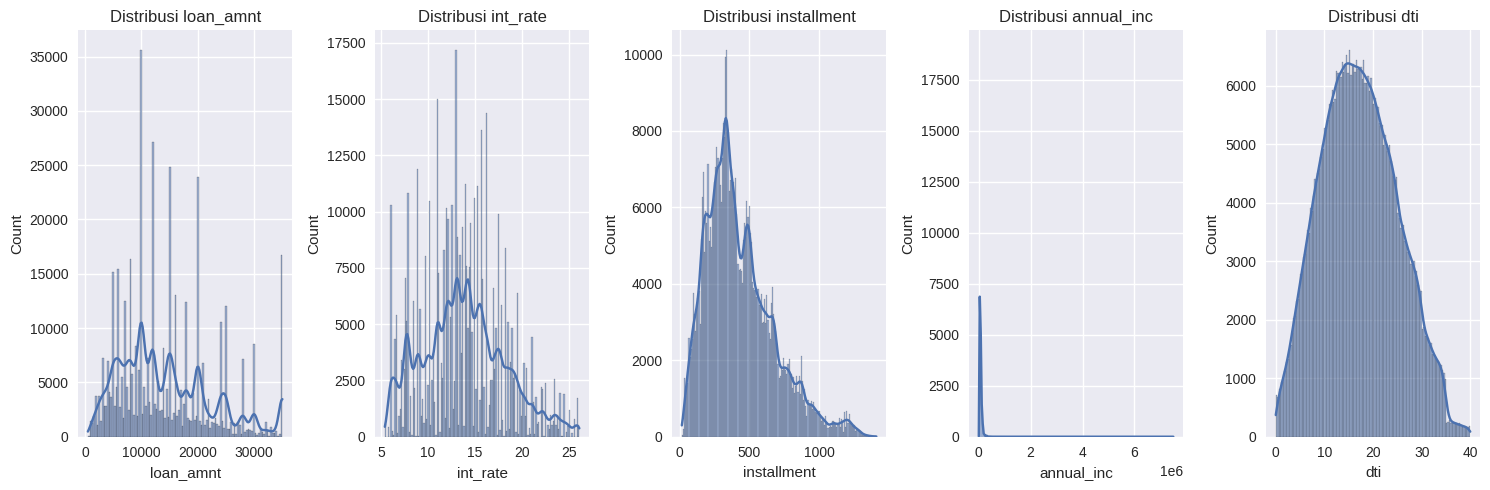


METODE SCALING BERDASARKAN DISTRIBUSI:
Kolom dengan distribusi mendekati normal: 20
Kolom dengan skewness tinggi: 25

Top 5 kolom dengan skewness tertinggi:
  - pymnt_plan: skewness = 227.61
  - collections_12_mths_ex_med: skewness = 31.23
  - annual_inc: skewness = 29.57
  - collection_recovery_fee: skewness = 22.24
  - acc_now_delinq: skewness = 20.80

Standardization (Z-score) diterapkan pada 20 kolom
Contoh: Unnamed: 0, loan_amnt, funded_amnt → Unnamed: 0_scaled, loan_amnt_scaled, funded_amnt_scaled

Min-Max scaling diterapkan pada 25 kolom
Contoh: pymnt_plan, collections_12_mths_ex_med, annual_inc → pymnt_plan_scaled, collections_12_mths_ex_med_scaled, annual_inc_scaled

ANALISIS DISTRIBUSI SETELAH SCALING:
Statistik setelah scaling:


,mean,std,min,25%,50%,75%,max
loan_amnt_scaled,1.170307e-17,1.000001,-1.667444,-0.762358,-0.279645,0.685781,2.495954
int_rate_scaled,-1.142756e-15,1.000001,-1.929794,-0.651562,-0.038837,0.610606,2.806778
installment_scaled,-2.984284e-16,1.000001,-1.710129,-0.720254,-0.214268,0.552472,4.016377
annual_inc_scaled,9.519912e-03,0.007330,0.000000,0.005749,0.008149,0.011611,1.000000
dti_scaled,-1.848111e-16,1.000001,-2.193161,-0.746233,-0.044421,0.708338,2.900384


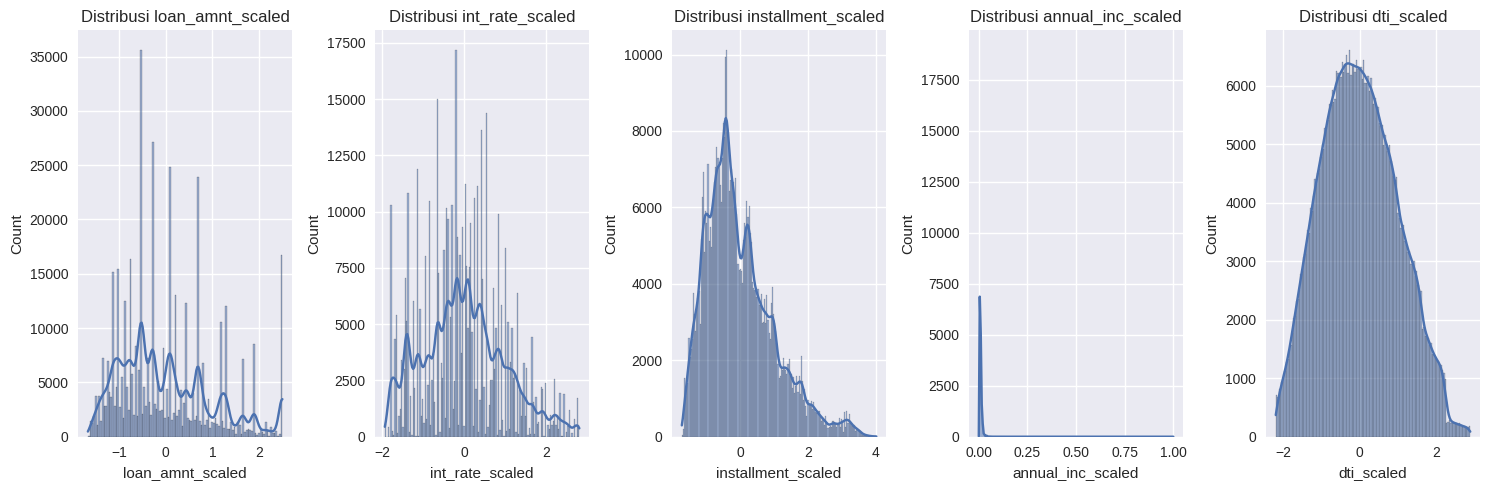


SIMPAN KOLOM ASLI:
Kolom asli tetap dipertahankan untuk interpretabilitas.
Kolom yang telah discaling dapat dipilih pada tahap feature selection.


In [77]:
# Scaling dan normalisasi fitur numerik
print("SCALING DAN NORMALISASI FITUR NUMERIK:")

# Identifikasi semua kolom numerik setelah encoding
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

# Exclude kolom ID dan target
exclude_from_scaling = ['id', 'member_id']
if 'target_numeric' in numeric_cols:
    exclude_from_scaling.append('target_numeric')
if 'loan_status_simple' in df.columns:
    exclude_from_scaling.append('loan_status_simple')

# Exclude flag columns
flag_cols = [col for col in numeric_cols if col.endswith('_flag')]
exclude_from_scaling.extend(flag_cols)

# Kolom untuk scaling
scale_cols = [col for col in numeric_cols if col not in exclude_from_scaling]
print(f"Jumlah kolom untuk scaling: {len(scale_cols)}")

# Analisis distribusi fitur-fitur penting sebelum scaling
print("\nANALISIS DISTRIBUSI SEBELUM SCALING:")
# Pilih beberapa kolom penting sebagai contoh
important_cols = ['loan_amnt', 'int_rate', 'installment', 'annual_inc', 'dti']
important_cols = [col for col in important_cols if col in scale_cols][:5]  # Ambil max 5

if important_cols:
    # Tunjukkan statistik sebelum scaling
    print("Statistik sebelum scaling:")
    display(df[important_cols].describe().T[['mean', 'std', 'min', '25%', '50%', '75%', 'max']])

    # Visualisasi distribusi sebelum scaling
    plt.figure(figsize=(15, 5))
    for i, col in enumerate(important_cols, 1):
        plt.subplot(1, len(important_cols), i)
        sns.histplot(df[col], kde=True)
        plt.title(f'Distribusi {col}')
    plt.tight_layout()
    plt.show()

# Identifikasi metode scaling yang tepat
# 1. Standardization (Z-score) untuk fitur dengan distribusi mendekati normal
# 2. Min-Max scaling untuk fitur dengan distribusi tidak normal atau outlier

# Cek skewness untuk menentukan metode scaling
print("\nMETODE SCALING BERDASARKAN DISTRIBUSI:")
skewed_cols = []
normal_cols = []

for col in scale_cols:
    skewness = df[col].skew()
    if abs(skewness) > 1:  # Threshold untuk skewness tinggi
        skewed_cols.append((col, skewness))
    else:
        normal_cols.append((col, skewness))

print(f"Kolom dengan distribusi mendekati normal: {len(normal_cols)}")
print(f"Kolom dengan skewness tinggi: {len(skewed_cols)}")

# Tampilkan beberapa contoh kolom dengan skewness tinggi
if skewed_cols:
    skewed_cols.sort(key=lambda x: abs(x[1]), reverse=True)
    print("\nTop 5 kolom dengan skewness tertinggi:")
    for col, skew in skewed_cols[:5]:
        print(f"  - {col}: skewness = {skew:.2f}")

# Apply StandardScaler untuk kolom dengan distribusi mendekati normal
if normal_cols:
    # Buat scaler
    std_scaler = StandardScaler()

    # Ambil nama kolom
    normal_col_names = [col for col, _ in normal_cols]

    # Apply scaling
    df_scaled = pd.DataFrame(
        std_scaler.fit_transform(df[normal_col_names]),
        columns=[f"{col}_scaled" for col in normal_col_names],
        index=df.index
    )

    # Gabungkan hasil scaling ke dataframe asli
    df = pd.concat([df, df_scaled], axis=1)

    print(f"\nStandardization (Z-score) diterapkan pada {len(normal_cols)} kolom")
    print(f"Contoh: {', '.join([col for col, _ in normal_cols[:3]])} → "
          f"{', '.join([f'{col}_scaled' for col, _ in normal_cols[:3]])}")

# Apply MinMaxScaler untuk kolom dengan distribusi tidak normal
if skewed_cols:
    # Buat scaler
    minmax_scaler = MinMaxScaler()

    # Ambil nama kolom
    skewed_col_names = [col for col, _ in skewed_cols]

    # Apply scaling
    df_minmax = pd.DataFrame(
        minmax_scaler.fit_transform(df[skewed_col_names]),
        columns=[f"{col}_scaled" for col in skewed_col_names],
        index=df.index
    )

    # Gabungkan hasil scaling ke dataframe asli
    df = pd.concat([df, df_minmax], axis=1)

    print(f"\nMin-Max scaling diterapkan pada {len(skewed_cols)} kolom")
    print(f"Contoh: {', '.join([col for col, _ in skewed_cols[:3]])} → "
          f"{', '.join([f'{col}_scaled' for col, _ in skewed_cols[:3]])}")

# Analisis distribusi fitur-fitur penting setelah scaling
print("\nANALISIS DISTRIBUSI SETELAH SCALING:")
# Tunjukkan statistik setelah scaling
scaled_important_cols = [f"{col}_scaled" for col in important_cols]
if scaled_important_cols:
    print("Statistik setelah scaling:")
    display(df[scaled_important_cols].describe().T[['mean', 'std', 'min', '25%', '50%', '75%', 'max']])

    # Visualisasi distribusi setelah scaling
    plt.figure(figsize=(15, 5))
    for i, col in enumerate(scaled_important_cols, 1):
        plt.subplot(1, len(scaled_important_cols), i)
        sns.histplot(df[col], kde=True)
        plt.title(f'Distribusi {col}')
    plt.tight_layout()
    plt.show()

# Keep original columns for interpretability
print("\nSIMPAN KOLOM ASLI:")
print("Kolom asli tetap dipertahankan untuk interpretabilitas.")
print("Kolom yang telah discaling dapat dipilih pada tahap feature selection.")

Scaling dan normalisasi fitur numerik adalah langkah penting untuk memastikan fitur dengan skala berbeda diperlakukan secara adil oleh algoritma machine learning. Pendekatan yang digunakan:

1. Analisis Distribusi - Memeriksa skewness setiap kolom untuk menentukan metode scaling yang tepat.
2. Metode Scaling yang Diferensial:
- StandardScaler (Z-score) untuk fitur dengan distribusi mendekati normal (skewness < 1).
- MinMaxScaler untuk fitur dengan skewness tinggi.
3. Pemeliharaan Informasi - Kolom asli dipertahankan bersama dengan versi yang discaling untuk menjaga interpretabilitas.
4. Selective Scaling - Hanya kolom yang relevan yang discaling, menghindari kolom ID, kolom target, dan flag columns.

Alasan:
- StandardScaler bekerja baik untuk data dengan distribusi normal, menghasilkan mean=0 dan std=1.
- MinMaxScaler lebih cocok untuk data dengan distribusi tidak normal, punya range terbatas [0,1].
- Dual Storage (kolom asli + scaled) memberikan fleksibilitas untuk pemilihan fitur dan interpretasi model.
- Pemilihan Selektif memastikan hanya kolom yang perlu yang ditransformasi, menghindari distorsi data yang tidak perlu.

Membagi data menjadi train set dan test set

In [78]:
# Membagi data menjadi train set dan test set
print("MEMBAGI DATA MENJADI TRAIN SET DAN TEST SET:")

# Siapkan dataframe untuk modeling
# 1. Definisikan kolom target
if 'loan_status_simple' in df.columns and 'target_numeric' not in df.columns:
    df['target_numeric'] = df['loan_status_simple'].map({'Good': 0, 'Bad': 1})
    print(f"Target variable: 'target_numeric' (0=Good, 1=Bad)")
elif 'target_numeric' in df.columns:
    print(f"Target variable: 'target_numeric' sudah ada")
else:
    raise ValueError("Target variable tidak ditemukan!")

# 2. Pemilihan fitur untuk model final
# Ini adalah langkah awal, feature selection lebih lanjut dapat dilakukan di tahap modeling
# Pilih kolom scaled untuk numerik
numeric_features = [col for col in df.columns if col.endswith('_scaled')]

# Tambahkan kolom flag
flag_features = [col for col in df.columns if col.endswith('_flag')]

# Tambahkan kolom kategorikal yang telah diencoding
encoded_categorical = [col for col in df.columns if any(s in col for s in ['_freq', '_ordinal', '_years'])]

# Tambahkan kolom hasil transformasi
transformed_features = [col for col in df.columns if col.endswith('_log')]

# Gabungkan semua fitur terpilih
selected_features = numeric_features + flag_features + encoded_categorical + transformed_features

print(f"\nJumlah fitur yang dipilih: {len(selected_features)}")
print(f"  - Fitur numerik yang discaling: {len(numeric_features)}")
print(f"  - Fitur flag: {len(flag_features)}")
print(f"  - Fitur kategorikal yang diencoding: {len(encoded_categorical)}")
print(f"  - Fitur hasil transformasi: {len(transformed_features)}")

# 3. Pemeriksaan ketidakseimbangan kelas (class imbalance)
print("\nANALISIS KETIDAKSEIMBANGAN KELAS:")
class_counts = df['target_numeric'].value_counts()
class_percentages = class_counts / len(df) * 100

print("Distribusi kelas:")
for kelas, count in class_counts.items():
    print(f"  - Kelas {int(kelas)} ({'Bad' if kelas==1 else 'Good'}): {count} sampel ({class_percentages[kelas]:.2f}%)")

# Evaluasi ketidakseimbangan
imbalance_ratio = class_counts.max() / class_counts.min()
print(f"Rasio ketidakseimbangan: {imbalance_ratio:.2f}")

# 4. Strategi splitting berdasarkan tingkat ketidakseimbangan
stratify_option = None
if imbalance_ratio > 3:
    print("\nPerhatian: Dataset menunjukkan ketidakseimbangan kelas yang signifikan.")
    print("Menggunakan stratified sampling untuk menjaga distribusi kelas.")
    stratify_option = df['target_numeric']
else:
    print("\nDistribusi kelas relatif seimbang. Stratified sampling tidak diperlukan.")

# 5. Train-test split
X = df[selected_features]
y = df['target_numeric']

# Implementasi split
test_size = 0.2  # 20% untuk testing
random_state = 42  # untuk reproducibility

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=test_size, random_state=random_state,
    stratify=stratify_option
)

print(f"\nSplit data (test_size={test_size}, random_state={random_state}):")
print(f"  - Training set: {X_train.shape[0]} sampel ({X_train.shape[0]/len(df)*100:.1f}%)")
print(f"  - Testing set: {X_test.shape[0]} sampel ({X_test.shape[0]/len(df)*100:.1f}%)")

# 6. Verifikasi distribusi pada train dan test set
print("\nVerifikasi distribusi kelas:")
print(f"  - Training set: {y_train.value_counts()[1]/len(y_train)*100:.2f}% kelas Bad")
print(f"  - Testing set: {y_test.value_counts()[1]/len(y_test)*100:.2f}% kelas Bad")

# 7. Simpan hasil split untuk modeling
# Buat dictionary data untuk modeling
modeling_data = {
    'X_train': X_train,
    'X_test': X_test,
    'y_train': y_train,
    'y_test': y_test,
    'feature_names': selected_features
}

print("\nData siap untuk tahap modeling.")
print(f"  - Jumlah fitur: {len(selected_features)}")
print(f"  - Jumlah sampel training: {len(X_train)}")
print(f"  - Jumlah sampel testing: {len(X_test)}")

# 8. Simpan informasi pre-processing untuk deployment
preprocessing_info = {
    'numeric_cols': numeric_cols,
    'categorical_cols': categorical_cols,
    'high_cardinality': [col for col, _ in high_cardinality] if 'high_cardinality' in locals() else [],
    'medium_cardinality': [col for col, _ in medium_cardinality] if 'medium_cardinality' in locals() else [],
    'binary_cols': [col for col, _ in binary_cols] if 'binary_cols' in locals() else [],
    'skewed_cols': [col for col, _ in skewed_cols] if 'skewed_cols' in locals() else [],
    'normal_cols': [col for col, _ in normal_cols] if 'normal_cols' in locals() else [],
    'transform_cols': list(transform_cols.keys()) if 'transform_cols' in locals() else [],
    'winsorize_cols': list(winsorize_cols.keys()) if 'winsorize_cols' in locals() else []
}

print("\nInformasi pre-processing disimpan untuk deployment.")

MEMBAGI DATA MENJADI TRAIN SET DAN TEST SET:
Target variable: 'target_numeric' sudah ada

Jumlah fitur yang dipilih: 64
  - Fitur numerik yang discaling: 45
  - Fitur flag: 1
  - Fitur kategorikal yang diencoding: 18
  - Fitur hasil transformasi: 0

ANALISIS KETIDAKSEIMBANGAN KELAS:
Distribusi kelas:
  - Kelas 0 (Good): 410953 sampel (88.13%)
  - Kelas 1 (Bad): 55332 sampel (11.87%)
Rasio ketidakseimbangan: 7.43

Perhatian: Dataset menunjukkan ketidakseimbangan kelas yang signifikan.
Menggunakan stratified sampling untuk menjaga distribusi kelas.

Split data (test_size=0.2, random_state=42):
  - Training set: 373028 sampel (80.0%)
  - Testing set: 93257 sampel (20.0%)

Verifikasi distribusi kelas:
  - Training set: 11.87% kelas Bad
  - Testing set: 11.87% kelas Bad

Data siap untuk tahap modeling.
  - Jumlah fitur: 64
  - Jumlah sampel training: 373028
  - Jumlah sampel testing: 93257

Informasi pre-processing disimpan untuk deployment.


Membagi data menjadi training set dan testing set adalah langkah penting untuk evaluasi yang tidak bias. Pendekatan yang digunakan:

1. Pemilihan Fitur untuk Modeling:
- Fitur numerik yang telah discaling
- Flag columns dari penanganan missing values
- Fitur kategorikal yang telah diencoding
- Fitur hasil transformasi (misalnya log-transformed)
2. Analisis Ketidakseimbangan Kelas:
- Menghitung rasio ketidakseimbangan untuk menentukan strategi yang tepat
- Menggunakan stratified sampling untuk kasus imbalanced (>3:1)
3. Split Data:
- 80% training, 20% testing (standar industri)
- Penggunaan random_state untuk reproducibility
- Stratify option untuk mempertahankan distribusi kelas
4. Verifikasi Distribusi:
- Memastikan distribusi kelas konsisten antara training dan testing
- Pengecekan jumlah sampel per set
5. Penyimpanan Informasi Preprocessing:
- Menyimpan metadata tentang transformasi yang dilakukan
- Penting untuk konsistensi saat deployment

Alasan:
- Stratified Sampling menjaga distribusi kelas tetap sama di training dan testing, krusial untuk data imbalanced.
- 80/20 Split memberikan keseimbangan antara ukuran training data dan validitas testing.
- Random State memastikan reproducibility, penting untuk debugging dan perbandingan model.
- Metadata Preprocessing memastikan transformasi yang sama dapat diterapkan pada data baru saat deployment.

# Data Modelling


Import library

In [106]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from time import time
from sklearn.model_selection import train_test_split, cross_val_score, learning_curve
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report, roc_curve
import warnings
warnings.filterwarnings('ignore')

# Untuk mempercepat komputasi
from joblib import parallel_backend
import os
os.environ['OMP_NUM_THREADS'] = '4'  # Kontrol thread untuk operasi NumPy

# Set seed untuk reproduktifitas
np.random.seed(42)

In [111]:
def pilih_model():
    # Inisialisasi model dasar
    lr = LogisticRegression(
        random_state=42,
        max_iter=1000,    # Menghindari warning konvergensi
        n_jobs=-1         # Paralelisasi
    )

    rf = RandomForestClassifier(
        random_state=42,
        n_estimators=100, # Nilai standar yang baik
        n_jobs=-1,        # Paralelisasi
        verbose=0         # Mengurangi output
    )

    return lr, rf

# Panggil fungsi untuk memilih model
lr_model, rf_model = pilih_model()

**Pemilihan Model Machine Learning**
1. Logistic Regression (Model Wajib)

Alasan Pemilihan:

Interpretabilitas: Menghasilkan koefisien yang mudah ditafsirkan, penting untuk industri keuangan yang diatur ketat

Output Probabilistik: Menghasilkan probabilitas yang dapat digunakan untuk penilaian risiko dan penentuan harga

Efisiensi Komputasi: Lebih cepat dilatih dibandingkan model kompleks, cocok untuk dataset besar

Baseline yang Baik: Memberikan perbandingan kinerja dasar yang solid sebelum mencoba model yang lebih kompleks

Standar Industri: Digunakan secara luas dalam industri keuangan untuk model risiko kredit

2. Random Forest

Alasan Pemilihan:

Kemampuan Non-linear: Dapat menangkap hubungan kompleks yang tidak linear antara fitur

Ketahanan terhadap Overfitting: Mampu menangani dataset besar dengan dimensi tinggi tanpa overfitting berlebihan

Penanganan Missing Values: Dapat menangani nilai yang hilang dengan baik

Kepentingan Fitur: Menyediakan ukuran kepentingan fitur yang intuitif

Ketahanan terhadap Outlier: Tahan terhadap outlier yang umum dalam data keuangan

Performa pada Data Tidak Seimbang: Bekerja dengan baik pada kelas tidak seimbang dengan penyesuaian parameter yang tepat

**Melakukan pelatihan model pada set pelatihan**


In [112]:
def persiapan_dan_pelatihan_data(X, y):
    print("\nLANGKAH 2: Persiapan dan pelatihan model pada set pelatihan")
    print("="*70)
    start_time = time()

    # Split data - stratify=y memastikan distribusi target sama di train dan test
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )

    print(f"Data dibagi: {X_train.shape[0]} sampel pelatihan, {X_test.shape[0]} sampel pengujian")

    # Standardisasi fitur - hanya untuk kolom numerik
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # Pelatihan Logistic Regression
    lr_start = time()
    with parallel_backend('threading', n_jobs=-1):
        lr_model.fit(X_train_scaled, y_train)
    lr_time = time() - lr_start

    # Pelatihan Random Forest
    rf_start = time()
    with parallel_backend('threading', n_jobs=-1):
        rf_model.fit(X_train_scaled, y_train)
    rf_time = time() - rf_start

    print(f"Waktu pelatihan Logistic Regression: {lr_time:.2f} detik")
    print(f"Waktu pelatihan Random Forest: {rf_time:.2f} detik")
    print(f"Total waktu persiapan dan pelatihan: {time() - start_time:.2f} detik")

    return X_train_scaled, X_test_scaled, y_train, y_test, scaler

# Lakukan persiapan dan pelatihan data
X_train_scaled, X_test_scaled, y_train, y_test, scaler = persiapan_dan_pelatihan_data(X, y)


LANGKAH 2: Persiapan dan pelatihan model pada set pelatihan
Data dibagi: 373028 sampel pelatihan, 93257 sampel pengujian
Waktu pelatihan Logistic Regression: 9.11 detik
Waktu pelatihan Random Forest: 292.08 detik
Total waktu persiapan dan pelatihan: 302.87 detik


**Menyesuaikan parameter model menggunakan teknik seperti cross-validation atau grid search.**

In [113]:
def tuning_parameter_efisien(lr_model, rf_model, X_train, y_train):
    print("\nLANGKAH 3: Menyesuaikan parameter model")
    print("="*70)
    start_time = time()

    # ===== Logistic Regression Tuning =====
    print("\nTuning Logistic Regression...")
    lr_start = time()

    # Mencoba beberapa nilai C dengan cross-validation
    C_values = [0.1, 1, 10]
    best_lr_score = 0
    best_C = 1.0

    for C in C_values:
        with parallel_backend('threading', n_jobs=-1):
            lr = LogisticRegression(C=C, penalty='l2', random_state=42, max_iter=1000, solver='liblinear')
            scores = cross_val_score(lr, X_train, y_train, cv=3, scoring='f1')
            mean_score = np.mean(scores)

        print(f"  C={C}: F1={mean_score:.4f}")

        if mean_score > best_lr_score:
            best_lr_score = mean_score
            best_C = C

    # Mencoba dengan/tanpa class balancing
    lr_balanced = LogisticRegression(C=best_C, random_state=42, class_weight='balanced', max_iter=1000, solver='liblinear')

    with parallel_backend('threading', n_jobs=-1):
        balanced_scores = cross_val_score(lr_balanced, X_train, y_train, cv=3, scoring='f1')
        balanced_mean = np.mean(balanced_scores)

    print(f"  C={best_C} dengan class_weight='balanced': F1={balanced_mean:.4f}")

    use_balanced = balanced_mean > best_lr_score

    # Final Logistic Regression dengan parameter terbaik
    best_lr = LogisticRegression(
        C=best_C,
        penalty='l2',
        solver='liblinear',  # Solver tercepat untuk dataset medium
        class_weight='balanced' if use_balanced else None,
        random_state=42,
        max_iter=1000,
        n_jobs=-1
    )

    with parallel_backend('threading', n_jobs=-1):
        best_lr.fit(X_train, y_train)

    lr_tuning_time = time() - lr_start
    print(f"Parameter terbaik Logistic Regression:")
    print(f"  C={best_C}, class_weight={'balanced' if use_balanced else 'None'}")
    print(f"Waktu tuning: {lr_tuning_time:.2f} detik")

    # ===== Random Forest Tuning =====
    print("\nTuning Random Forest...")
    rf_start = time()

    # Mencoba beberapa kombinasi parameter penting
    param_combinations = [
        {'n_estimators': 50, 'max_depth': 10},
        {'n_estimators': 50, 'max_depth': None},
        {'n_estimators': 100, 'max_depth': 10},
        {'n_estimators': 100, 'max_depth': None}
    ]

    best_rf_score = 0
    best_rf_params = {}

    for params in param_combinations:
        with parallel_backend('threading', n_jobs=-1):
            rf = RandomForestClassifier(random_state=42, n_jobs=-1, **params)
            scores = cross_val_score(rf, X_train, y_train, cv=3, scoring='f1')
            mean_score = np.mean(scores)

        print(f"  n_estimators={params['n_estimators']}, max_depth={params['max_depth']}: F1={mean_score:.4f}")

        if mean_score > best_rf_score:
            best_rf_score = mean_score
            best_rf_params = params

    # Final Random Forest dengan parameter terbaik
    best_rf = RandomForestClassifier(
        random_state=42,
        n_jobs=-1,
        **best_rf_params
    )

    with parallel_backend('threading', n_jobs=-1):
        best_rf.fit(X_train, y_train)

    rf_tuning_time = time() - rf_start
    print(f"Parameter terbaik Random Forest:")
    print(f"  n_estimators={best_rf_params['n_estimators']}, max_depth={best_rf_params['max_depth']}")
    print(f"Waktu tuning: {rf_tuning_time:.2f} detik")

    print(f"\nTotal waktu tuning parameter: {time() - start_time:.2f} detik")

    return best_lr, best_rf

# Lakukan tuning parameter efisien
best_lr, best_rf = tuning_parameter_efisien(lr_model, rf_model, X_train_scaled, y_train)


LANGKAH 3: Menyesuaikan parameter model

Tuning Logistic Regression...
  C=0.1: F1=0.8851
  C=1: F1=0.8884
  C=10: F1=0.8890
  C=10 dengan class_weight='balanced': F1=0.7814
Parameter terbaik Logistic Regression:
  C=10, class_weight=None
Waktu tuning: 473.00 detik

Tuning Random Forest...
  n_estimators=50, max_depth=10: F1=0.9272
  n_estimators=50, max_depth=None: F1=0.9391
  n_estimators=100, max_depth=10: F1=0.9264
  n_estimators=100, max_depth=None: F1=0.9389
Parameter terbaik Random Forest:
  n_estimators=50, max_depth=None
Waktu tuning: 1168.42 detik

Total waktu tuning parameter: 1641.42 detik


**Mengevaluasi kinerja model menggunakan metrik yang relevan seperti akurasi presisi recall atau ROC-AUC.**


LANGKAH 4: Mengevaluasi kinerja model

Evaluasi Logistic Regression:
  Accuracy: 0.9763
  Precision: 0.9704
  Recall: 0.8256
  F1 Score: 0.8921
  ROC AUC: 0.9804
  Waktu evaluasi: 0.22 detik

Evaluasi Random Forest:
  Accuracy: 0.9867
  Precision: 0.9968
  Recall: 0.8908
  F1 Score: 0.9408
  ROC AUC: 0.9865
  Waktu evaluasi: 2.98 detik


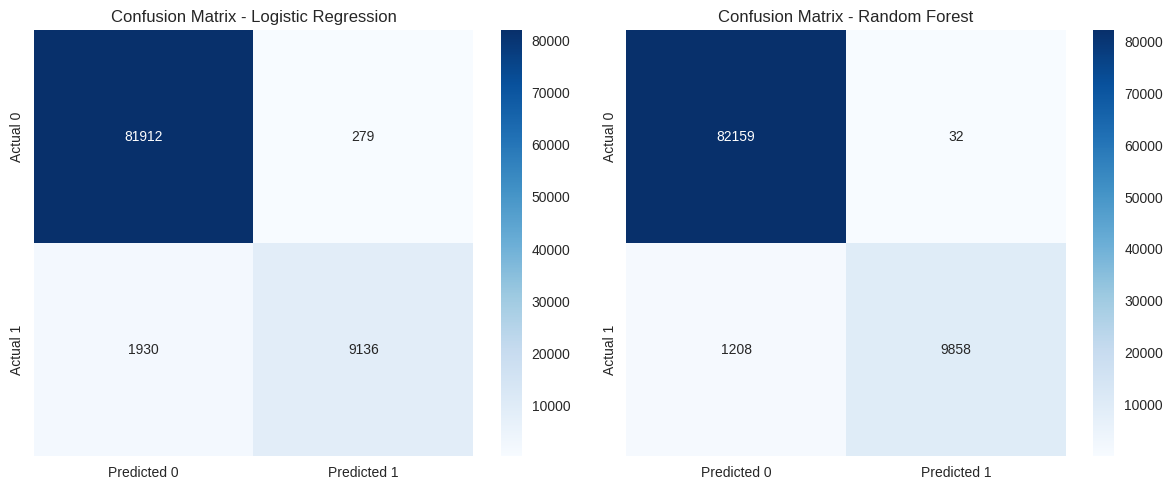

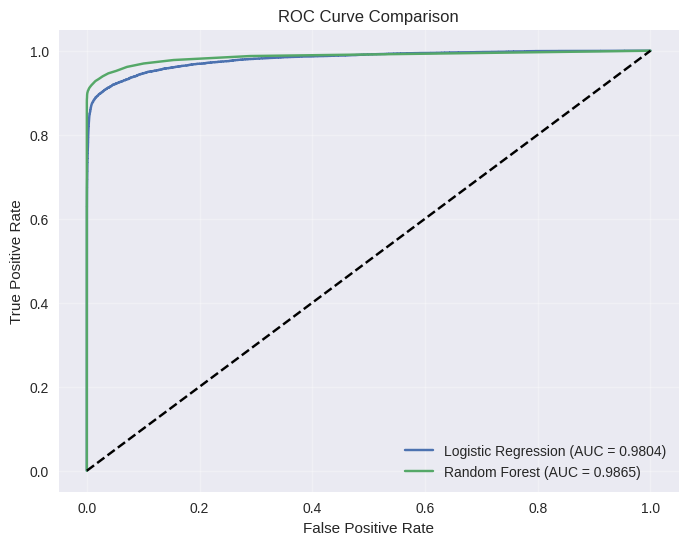


Perbandingan Model:
      Metric  Logistic Regression  Random Forest
0   Accuracy             0.976313       0.986703
1  Precision             0.970366       0.996764
2     Recall             0.825592       0.890837
3   F1 Score             0.892144       0.940828
4    ROC AUC             0.980382       0.986465


<Figure size 1000x600 with 0 Axes>

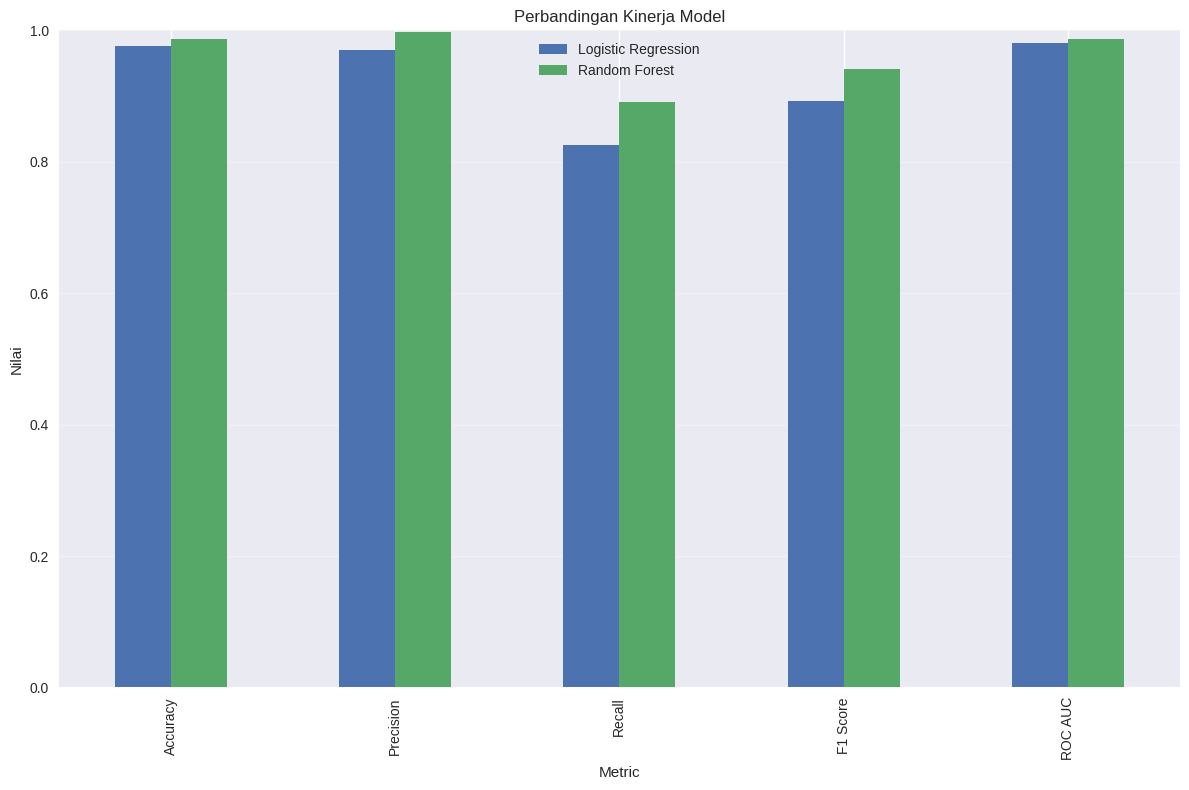


Total waktu evaluasi: 4.10 detik

Model terbaik berdasarkan F1 Score: Random Forest


In [114]:
def evaluasi_kinerja_model(best_lr, best_rf, X_train, X_test, y_train, y_test):
    print("\nLANGKAH 4: Mengevaluasi kinerja model")
    print("="*70)
    start_time = time()

    models = {
        'Logistic Regression': best_lr,
        'Random Forest': best_rf
    }

    results = {}

    for name, model in models.items():
        print(f"\nEvaluasi {name}:")
        model_start = time()

        # Prediksi
        y_pred = model.predict(X_test)
        y_prob = model.predict_proba(X_test)[:, 1]

        # Metrik evaluasi
        accuracy = accuracy_score(y_test, y_pred)
        precision = precision_score(y_test, y_pred)
        recall = recall_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred)
        roc_auc = roc_auc_score(y_test, y_prob)

        print(f"  Accuracy: {accuracy:.4f}")
        print(f"  Precision: {precision:.4f}")
        print(f"  Recall: {recall:.4f}")
        print(f"  F1 Score: {f1:.4f}")
        print(f"  ROC AUC: {roc_auc:.4f}")

        # Confusion Matrix
        cm = confusion_matrix(y_test, y_pred)

        # Simpan hasil untuk perbandingan
        results[name] = {
            'accuracy': accuracy,
            'precision': precision,
            'recall': recall,
            'f1': f1,
            'roc_auc': roc_auc,
            'confusion_matrix': cm,
            'y_prob': y_prob
        }

        print(f"  Waktu evaluasi: {time() - model_start:.2f} detik")

    # Plot Confusion Matrix untuk kedua model
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    for i, (name, result) in enumerate(results.items()):
        sns.heatmap(
            result['confusion_matrix'],
            annot=True,
            fmt='d',
            cmap='Blues',
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'],
            ax=axes[i]
        )
        axes[i].set_title(f'Confusion Matrix - {name}')

    plt.tight_layout()
    plt.show()

    # Plot ROC Curve untuk kedua model
    plt.figure(figsize=(8, 6))

    for name, result in results.items():
        fpr, tpr, _ = roc_curve(y_test, result['y_prob'])
        plt.plot(fpr, tpr, label=f'{name} (AUC = {result["roc_auc"]:.4f})')

    plt.plot([0, 1], [0, 1], 'k--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve Comparison')
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

    # Perbandingan model dalam bentuk tabel
    comparison = pd.DataFrame({
        'Metric': ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'ROC AUC'],
        'Logistic Regression': [
            results['Logistic Regression']['accuracy'],
            results['Logistic Regression']['precision'],
            results['Logistic Regression']['recall'],
            results['Logistic Regression']['f1'],
            results['Logistic Regression']['roc_auc']
        ],
        'Random Forest': [
            results['Random Forest']['accuracy'],
            results['Random Forest']['precision'],
            results['Random Forest']['recall'],
            results['Random Forest']['f1'],
            results['Random Forest']['roc_auc']
        ]
    })

    print("\nPerbandingan Model:")
    print(comparison)

    # Visualisasi perbandingan metrik
    plt.figure(figsize=(10, 6))
    comparison.set_index('Metric').plot(kind='bar')
    plt.title('Perbandingan Kinerja Model')
    plt.ylabel('Nilai')
    plt.ylim(0, 1)
    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()

    print(f"\nTotal waktu evaluasi: {time() - start_time:.2f} detik")

    # Tentukan model terbaik berdasarkan F1 Score
    best_model_name = 'Logistic Regression' if results['Logistic Regression']['f1'] > results['Random Forest']['f1'] else 'Random Forest'
    print(f"\nModel terbaik berdasarkan F1 Score: {best_model_name}")

    return results, comparison, best_model_name

# Evaluasi kinerja model
results, comparison, best_model_name = evaluasi_kinerja_model(best_lr, best_rf, X_train_scaled, X_test_scaled, y_train, y_test)

**Memeriksa overfitting atau underfitting model dan mengambil tindakan yang sesuai**


LANGKAH 5: Memeriksa overfitting atau underfitting model

Memeriksa Logistic Regression:


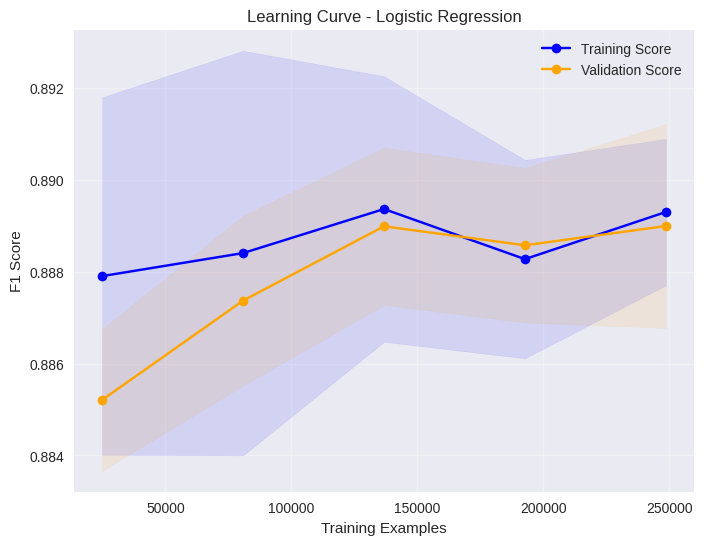

  Model SEIMBANG: Gap antara training dan validation: 0.0003
  Skor validasi terakhir: 0.8890
  Waktu analisis: 287.51 detik

Memeriksa Random Forest:


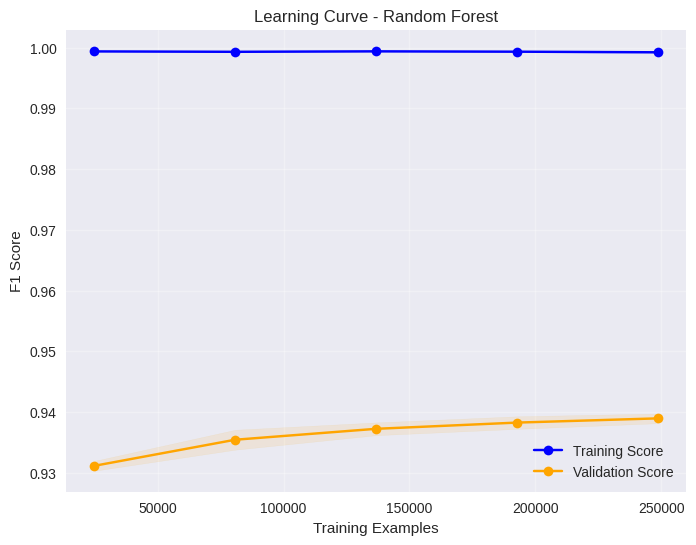

  Model SEIMBANG: Gap antara training dan validation: 0.0602
  Skor validasi terakhir: 0.9390
  Waktu analisis: 697.61 detik

Total waktu pemeriksaan overfitting/underfitting: 985.11 detik


In [115]:
def cek_overfitting_underfitting(best_lr, best_rf, X_train, y_train):
    print("\nLANGKAH 5: Memeriksa overfitting atau underfitting model")
    print("="*70)
    start_time = time()

    models = {
        'Logistic Regression': best_lr,
        'Random Forest': best_rf
    }

    train_sizes = np.linspace(0.1, 1.0, 5)  # 5 titik saja untuk kecepatan

    for name, model in models.items():
        print(f"\nMemeriksa {name}:")
        model_start = time()

        # Penggunaan learning curve untuk mendeteksi overfitting/underfitting
        with parallel_backend('threading', n_jobs=-1):
            train_sizes_abs, train_scores, test_scores = learning_curve(
                model, X_train, y_train,
                train_sizes=train_sizes,
                cv=3,  # 3-fold CV untuk kecepatan
                scoring='f1',
                n_jobs=-1,
                random_state=42
            )

        # Menghitung mean dan std untuk score
        train_mean = np.mean(train_scores, axis=1)
        train_std = np.std(train_scores, axis=1)
        val_mean = np.mean(test_scores, axis=1)
        val_std = np.std(test_scores, axis=1)

        # Visualisasi learning curve
        plt.figure(figsize=(8, 6))
        plt.title(f'Learning Curve - {name}')
        plt.xlabel('Training Examples')
        plt.ylabel('F1 Score')
        plt.grid(alpha=0.3)

        plt.fill_between(
            train_sizes_abs, train_mean - train_std, train_mean + train_std,
            alpha=0.1, color='blue'
        )
        plt.fill_between(
            train_sizes_abs, val_mean - val_std, val_mean + val_std,
            alpha=0.1, color='orange'
        )

        plt.plot(train_sizes_abs, train_mean, 'o-', color='blue', label='Training Score')
        plt.plot(train_sizes_abs, val_mean, 'o-', color='orange', label='Validation Score')
        plt.legend(loc='best')
        plt.show()

        # Analisis overfitting/underfitting
        gap = train_mean[-1] - val_mean[-1]

        if gap > 0.1:
            print(f"  OVERFITTING terdeteksi: Gap antara training dan validation: {gap:.4f}")
            if name == 'Logistic Regression':
                print("  Solusi: Tingkatkan regularisasi (kurangi C) atau kurangi fitur")
            else:  # Random Forest
                print("  Solusi: Kurangi max_depth, tingkatkan min_samples_leaf, atau kurangi n_estimators")
        elif val_mean[-1] < 0.6:  # Threshold dapat disesuaikan
            print(f"  UNDERFITTING terdeteksi: Skor validasi rendah: {val_mean[-1]:.4f}")
            if name == 'Logistic Regression':
                print("  Solusi: Kurangi regularisasi (tingkatkan C) atau tambahkan fitur/interaksi")
            else:  # Random Forest
                print("  Solusi: Tingkatkan max_depth, tambah n_estimators, atau kurangi min_samples_leaf")
        else:
            print(f"  Model SEIMBANG: Gap antara training dan validation: {gap:.4f}")
            print(f"  Skor validasi terakhir: {val_mean[-1]:.4f}")

        print(f"  Waktu analisis: {time() - model_start:.2f} detik")

    print(f"\nTotal waktu pemeriksaan overfitting/underfitting: {time() - start_time:.2f} detik")

# Pemeriksaan overfitting/underfitting
cek_overfitting_underfitting(best_lr, best_rf, X_train_scaled, y_train)

Kesimpulan dan Visualisasi


Visualisasi Feature Importance


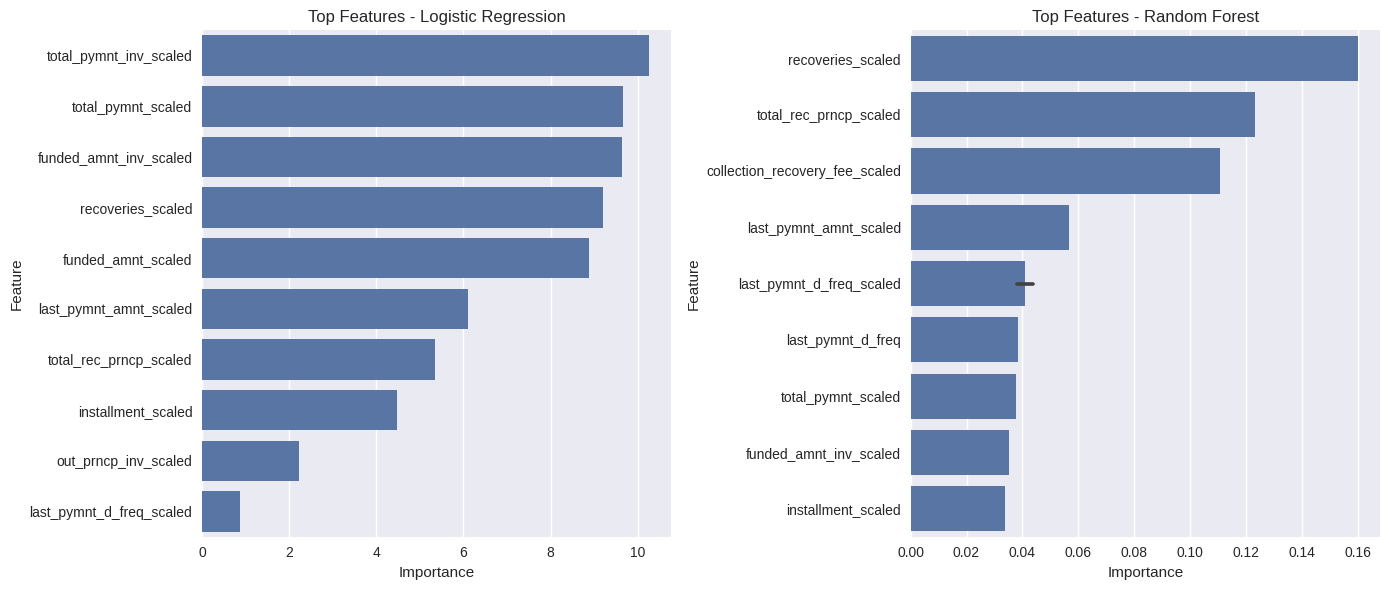

Feature penting untuk Logistic Regression:
                     Feature  Importance
36    total_pymnt_inv_scaled   10.260232
35        total_pymnt_scaled    9.666175
3     funded_amnt_inv_scaled    9.628917
27         recoveries_scaled    9.200173
2         funded_amnt_scaled    8.890067
33    last_pymnt_amnt_scaled    6.093983
34    total_rec_prncp_scaled    5.337414
5         installment_scaled    4.463851
38      out_prncp_inv_scaled    2.216685
18  last_pymnt_d_freq_scaled    0.872952

Feature penting untuk Random Forest:
                           Feature  Importance
27               recoveries_scaled    0.159854
34          total_rec_prncp_scaled    0.123317
23  collection_recovery_fee_scaled    0.110696
33          last_pymnt_amnt_scaled    0.056666
60        last_pymnt_d_freq_scaled    0.043747
52               last_pymnt_d_freq    0.038381
18        last_pymnt_d_freq_scaled    0.037949
35              total_pymnt_scaled    0.037755
3           funded_amnt_inv_scaled    0.03502

In [116]:
def visualisasi_feature_importance(best_lr, best_rf, X):
    print("\nVisualisasi Feature Importance")
    print("="*70)

    # Dapatkan nama fitur
    feature_names = X.columns if hasattr(X, 'columns') else [f'Feature {i}' for i in range(X.shape[1])]

    # Logistic Regression coefficients
    coef = best_lr.coef_[0]
    lr_importance = pd.DataFrame({
        'Feature': feature_names,
        'Importance': np.abs(coef)
    }).sort_values('Importance', ascending=False).head(10)

    # Random Forest feature importance
    rf_importance = pd.DataFrame({
        'Feature': feature_names,
        'Importance': best_rf.feature_importances_
    }).sort_values('Importance', ascending=False).head(10)

    # Plot feature importance
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    sns.barplot(x='Importance', y='Feature', data=lr_importance, ax=axes[0])
    axes[0].set_title('Top Features - Logistic Regression')

    sns.barplot(x='Importance', y='Feature', data=rf_importance, ax=axes[1])
    axes[1].set_title('Top Features - Random Forest')

    plt.tight_layout()
    plt.show()

    print(f"Feature penting untuk Logistic Regression:")
    print(lr_importance)

    print(f"\nFeature penting untuk Random Forest:")
    print(rf_importance)

# Visualisasi Feature Importance
visualisasi_feature_importance(best_lr, best_rf, X)

# Simpan model terbaik
from joblib import dump

if best_model_name == 'Logistic Regression':
    model_final = best_lr
else:
    model_final = best_rf

dump(model_final, 'best_loan_model.joblib')
print(f"\n{best_model_name} telah disimpan sebagai 'best_loan_model.joblib'")

# Evaluation

**Evaluasi Kinerja Model dengan Data Pengujian dan Metrik Evaluasi**

melakukan evaluasi menggunakan data pengujian yang terpisah. Anda akan memprediksi kelas menggunakan Logistic Regression dan Random Forest, lalu menghitung metrik evaluasi.

Evaluasi Logistic Regression:
Akurasi: 0.9214965096453885
Precision: 0.7645147619720299
Recall: 0.48906560636182905
F1-Score: 0.5965279691375035


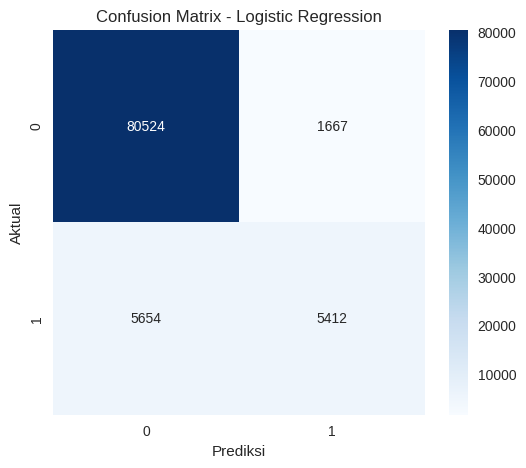


Evaluasi Random Forest:
Akurasi: 0.5660593842821451
Precision: 0.20523719773830051
Recall: 0.9249954816555214
F1-Score: 0.3359369872005251


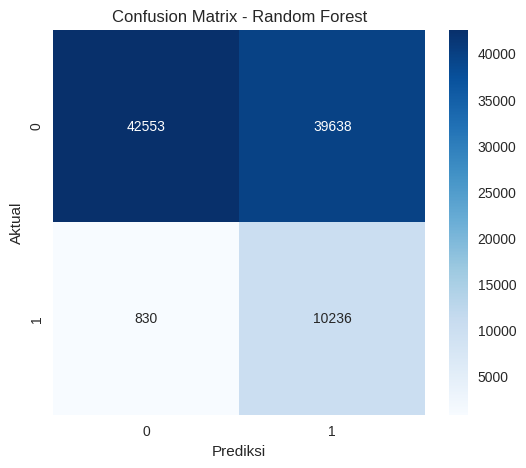

In [120]:
y_pred_logreg = best_lr.predict(X_test)
y_pred_rf = best_rf.predict(X_test)

# Evaluasi Logistic Regression
print("Evaluasi Logistic Regression:")
print(f"Akurasi: {accuracy_score(y_test, y_pred_logreg)}")
print(f"Precision: {precision_score(y_test, y_pred_logreg)}")
print(f"Recall: {recall_score(y_test, y_pred_logreg)}")
print(f"F1-Score: {f1_score(y_test, y_pred_logreg)}")

cm_logreg = confusion_matrix(y_test, y_pred_logreg)
plt.figure(figsize=(6, 5)) # Add figure size for clarity
sns.heatmap(cm_logreg, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Prediksi")
plt.ylabel("Aktual")
plt.show()

# Evaluasi Random Forest
print("\nEvaluasi Random Forest:")
print(f"Akurasi: {accuracy_score(y_test, y_pred_rf)}")
print(f"Precision: {precision_score(y_test, y_pred_rf)}")
print(f"Recall: {recall_score(y_test, y_pred_rf)}")
print(f"F1-Score: {f1_score(y_test, y_pred_rf)}")

cm_rf = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(6, 5)) # Add figure size for clarity
sns.heatmap(cm_rf, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Prediksi")
plt.ylabel("Aktual")
plt.show()

Penyusunan Hasil Evaluasi

Evaluasi Logistic Regression:
Akurasi: 0.9759589092507801
Precision: 0.9737972508591065
Recall: 0.8194469546358214
F1-Score: 0.8899793895377368


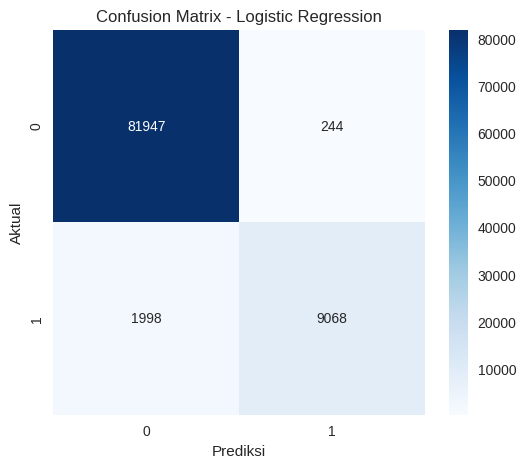


Evaluasi Random Forest:
Akurasi: 0.9867677493378513
Precision: 0.9969672462596038
Recall: 0.8911982649557202
F1-Score: 0.9411203359099151


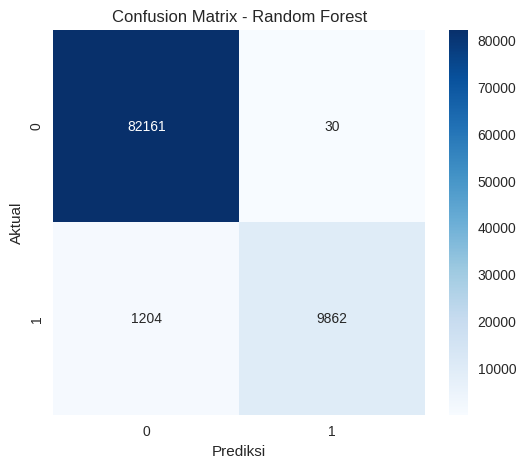

In [122]:
# Import library yang dibutuhkan
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Misalkan 'X_train', 'X_test', 'y_train', 'y_test' adalah data Anda
# Logistic Regression
logreg = LogisticRegression(max_iter=1000)
logreg.fit(X_train, y_train)
y_pred_logreg = logreg.predict(X_test)

# Random Forest
rf = RandomForestClassifier(n_estimators=100)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

# Evaluasi Logistic Regression
print("Evaluasi Logistic Regression:")
accuracy_logreg = accuracy_score(y_test, y_pred_logreg)
precision_logreg = precision_score(y_test, y_pred_logreg)
recall_logreg = recall_score(y_test, y_pred_logreg)
f1_logreg = f1_score(y_test, y_pred_logreg)

print(f"Akurasi: {accuracy_logreg}")
print(f"Precision: {precision_logreg}")
print(f"Recall: {recall_logreg}")
print(f"F1-Score: {f1_logreg}")

cm_logreg = confusion_matrix(y_test, y_pred_logreg)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_logreg, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Prediksi")
plt.ylabel("Aktual")
plt.show()

# Evaluasi Random Forest
print("\nEvaluasi Random Forest:")
accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)

print(f"Akurasi: {accuracy_rf}")
print(f"Precision: {precision_rf}")
print(f"Recall: {recall_rf}")
print(f"F1-Score: {f1_rf}")

cm_rf = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_rf, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Prediksi")
plt.ylabel("Aktual")
plt.show()